In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
import shutil
import re
import seaborn as sns
from itertools import combinations
import numpy as np
import xgboost
import lightgbm
#import tensorflow as tf
from pymatgen.core.structure import Structure
import ast
import time
import pickle

/home/parastoo/anaconda3/lib/python3.9/site-packages/dask/dataframe/__init__.py:42: FutureWarning: 
Dask dataframe query planning is disabled because dask-expr is not installed.

You can install it with `pip install dask[dataframe]` or `conda install dask`.
This will raise in a future version.

  warnings.warn(msg, FutureWarning)


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, HuberRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor, HistGradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.kernel_ridge import KernelRidge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error


In [3]:
%matplotlib inline

In [4]:
pd.set_option('display.max_rows', 2000)
pd.set_option('display.max_columns', 2000)
pd.set_option('display.width', 2000)
pd.set_option('display.max_colwidth', 2000)

In [5]:
save_path = '/home/parastoo/Desktop/ML_project/analysis/ML_project/paper_files/new_ML_5CV/'

In [6]:
df_raw_N2 = pd.read_csv(f'./dataframes/input_df_N2_bandcenter_v1.csv')
df_raw_H2 = pd.read_csv(f'./dataframes/input_df_H2_bandcenter_v1.csv')
df_raw_N2H = pd.read_csv(f'./dataframes/input_df_N2H_bandcenter_v1.csv')
df_raw_NH3 = pd.read_csv(f'./dataframes/input_df_NH3_bandcenter_v1.csv')

In [7]:
N2_score_df = pd.read_csv(f'./dataframes/results_score_N2_v1_diss0_outliersincl.csv')
N2H_score_df = pd.read_csv(f'./dataframes/results_score_N2H_v1_diss0_outliersincl.csv')
NH3_score_df = pd.read_csv(f'./dataframes/results_score_NH3_v1_diss0_outliersincl.csv')

In [8]:
"""
ML Pipeline: N₂ Adsorption Energy Prediction — Modular Function Version
========================================================================
USAGE:
    # Run the pipeline
    results = run_pipeline(
        df_raw            = df_raw_N2,
        outlier_method    = 'z3',
        n_select_features = 20,
    )

    # Plot figures separately with your own naming
    plot_cv_sweep(results,   filename='fig1_N2_cv_sweep.png')
    plot_train_vs_cv(results, filename='fig2_N2_train_cv.png')
    plot_heatmap(results,    filename='fig3_N2_heatmap.png')
    plot_parity(results,     filename='fig4_N2_parity.png')
    plot_shap(results,       filename_bar='fig5a_N2_shap_bar.png',
                             filename_beeswarm='fig5b_N2_beeswarm.png',
                             filename_dependence='fig5c_N2_dependence.png')

RETURNS from run_pipeline():
    dict with keys:
        ── Model selection ──────────────────────────────────────────
        best_model_nm      : name of best model, e.g. 'XGBRegressor' (str)
        best_k             : best neighbor level, e.g. 11 (int)
        best_cv_r2         : CV R² of best model at best_k (float)
        best_cv_mae        : CV MAE in eV of best model at best_k (float)
        ── Test set results ─────────────────────────────────────────
        test_r2            : test R² (float)
        test_mae           : test MAE in eV (float)
        test_rmse          : test RMSE in eV (float)
        ── Full sweep table ─────────────────────────────────────────
        sweep_results      : sweep_results[model][k] → metrics dict
        ── Feature tracking ─────────────────────────────────────────
        survived_feat_cols : feature names after VT+DHC+SKB (what model trained on)
        best_feat_cols     : feature names before pipeline (input to prepare_X)
        ── SHAP outputs ─────────────────────────────────────────────
        shap_vals          : raw SHAP matrix (n_test, n_survived_features)
        mean_shap          : pd.Series of mean |SHAP| per feature, sorted
        ── Test data arrays ─────────────────────────────────────────
        y_te               : true test labels (np.ndarray)
        y_te_pred          : predicted test labels (np.ndarray)
        X_te_proc          : transformed test matrix (n_test, n_survived_features)
        X_best_tr          : transformed train matrix at best_k
        X_best_te          : raw test matrix at best_k (pre-pipeline)
        ── Fitted model ─────────────────────────────────────────────
        best_model_fit     : full fitted Pipeline — call .predict(X_new) on new data
        ── Configuration metadata ───────────────────────────────────
        model_names        : ordered list of all model names
        n_neighbors        : number of neighbor levels swept (21)
        n_select_features  : SelectKBest k used (or None)
        outlier_method     : outlier filter used, e.g. 'z3'
        random_state       : random seed used

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
PIPELINE INTERNALS (unchanged from notebook version)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Round 1  : Data quality fixes (ion_e, VT, DropHighCorr, RepeatedKFold)
Round 2  : Final DOS only (n0_nk)
Round 3A : Shell statistics — constant 72 features regardless of k
Exp 1    : z3 outlier filter (best result)
Round 3B : Pairwise contrast features — DROPPED (redundant, hurt CV R²)
Option B : SelectKBest(f_regression, k=n_select_features) as step 3
SHAP fix : Feature names tracked through VT + DropHighCorr + SelectKBest
           KernelExplainer uses best_estimator.predict (not full pipeline)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
"""

import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

try:
    get_ipython().run_line_magic('matplotlib', 'inline')
except NameError:
    pass

plt.rcParams.update({
    'figure.dpi'      : 120,
    'savefig.dpi'     : 150,
    'figure.facecolor': 'white',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
})

from sklearn.preprocessing import LabelEncoder, StandardScaler, FunctionTransformer
from sklearn.linear_model import Ridge, Lasso, ElasticNet, HuberRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (RandomForestRegressor, GradientBoostingRegressor,
                              ExtraTreesRegressor)
from sklearn.svm import SVR
from sklearn.kernel_ridge import KernelRidge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import RepeatedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_regression

warnings.filterwarnings('ignore')

# ── optional models ────────────────────────────────────────────────────────────
OPTIONAL_MODELS = {}
try:
    from xgboost import XGBRegressor
    OPTIONAL_MODELS['XGBRegressor'] = XGBRegressor(
        n_estimators=200, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        random_state=42, verbosity=0, n_jobs=1)
    print("✓ XGBRegressor available")
except ImportError:
    print("✗ XGBRegressor not installed — skipping (pip install xgboost)")

# =============================================================================
# TOP-LEVEL CLASS — defined here (not inside a function) so the fitted object
# can be pickled with pickle.dump() / joblib.dump() after run_pipeline().
# =============================================================================
class DropHighCorr:
    """Drops one column from each pair with Pearson |r| > threshold.
    Must be defined at module level to be picklable."""
    def __init__(self, threshold=0.95):
        self.threshold = threshold
        self.drop_idx_ = None
    def fit(self, X, y=None):
        corr = np.corrcoef(X, rowvar=False)
        n = corr.shape[0]; drop = set()
        for i in range(n):
            if i in drop: continue
            for j in range(i+1, n):
                if j not in drop and abs(corr[i, j]) > self.threshold:
                    drop.add(j)
        self.drop_idx_ = sorted(drop)
        return self
    def transform(self, X, y=None):
        keep = [i for i in range(X.shape[1]) if i not in self.drop_idx_]
        return X[:, keep]
    def fit_transform(self, X, y=None):
        return self.fit(X, y).transform(X)
    def get_params(self, deep=True):
        return {'threshold': self.threshold}
    def set_params(self, **p):
        self.threshold = p.get('threshold', self.threshold)
        return self


# =============================================================================
# MAIN PIPELINE FUNCTION
# =============================================================================
def run_pipeline(df_raw,
                 outlier_method    = 'z3',
                 n_select_features = 20,
                 random_state      = 42,
                 tested_n_neighbors = 21):
    """
    Run the full ML pipeline on a raw dataframe.

    Parameters
    ----------
    df_raw            : pd.DataFrame — raw input dataframe (before any filtering)
    outlier_method    : str or None  — 'z3' / 'z2' / 'iqr' / 'physical' / None
    n_select_features : int or None  — number of features for SelectKBest, or None
    random_state      : int          — random seed for reproducibility

    Returns
    -------
    dict — all results needed for printing and plotting (see module docstring)
    """

    # ── 1. FILTER ─────────────────────────────────────────────────────────────
    df_f = df_raw[(df_raw['Mol_is_adsorbed'] == 1) &
                  (df_raw['is_dissociated']  == 0)].copy()

    if outlier_method is not None:
        y_tmp = df_f['ads_e'].values
        if outlier_method == 'iqr':
            Q1, Q3 = np.percentile(y_tmp, 25), np.percentile(y_tmp, 75)
            lo, hi = Q1 - 1.5*(Q3-Q1), Q3 + 1.5*(Q3-Q1)
        elif outlier_method == 'z2':
            lo, hi = y_tmp.mean() - 2*y_tmp.std(), y_tmp.mean() + 2*y_tmp.std()
        elif outlier_method == 'z3':
            lo, hi = y_tmp.mean() - 3*y_tmp.std(), y_tmp.mean() + 3*y_tmp.std()
        elif outlier_method == 'physical':
            lo, hi = -3.0, 2.0
        before = len(df_f)
        df_f = df_f[(df_f['ads_e'] >= lo) & (df_f['ads_e'] <= hi)].copy()
        print(f"\nOutlier filter '{outlier_method}' [{lo:.2f}, {hi:.2f}] eV: "
              f"{before - len(df_f)} removed → {len(df_f)} samples remain")
    else:
        print(f"\nNo outlier filtering (outlier_method = None)")

    print(f"Filtered dataset : {df_f.shape[0]} samples")
    print(f"SelectKBest k    : {n_select_features}")

    ALL_COLS       = df_f.columns.tolist()
    SKIP_PATTERNS  = ['coordinates', 'distance_vector', 'dos_selected_indices', 'atom_type']
    ALWAYS_EXCLUDE = ['mol_output_all_coords', 'is_dissociated', 'Mol_is_adsorbed',
                      'atomic_is_adsorbed', 'angle', 'orientation', 'ads_e',
                      'material', 'ad_site_number', 'mol', 'mol_elecneg',
                      'mol_cent_coord', 'mol_input_all_coords',
                      'pre_N-N', 'pre_H-H', 'pre_N-H1', 'pre_N-H2', 'pre_N-H3']
    GLOBAL_FEATS      = [c for c in ['crystal_struct', 'sym_group'] if c in ALL_COLS]
    DOS_ORBITALS_KEEP = ('sband', 'pband', 'dband')
    SHELL_PROPS       = ['electroneg', 'atomic_number', 'cov_rad', 'elect_affinity',
                         'charge', 'atom_density', 'atomic_mass', 'ion_e']

    y_all = df_f['ads_e'].values

    # ── 2. FEATURE COLS ───────────────────────────────────────────────────────
    def get_feature_cols(max_neighbor):
        feats = list(GLOBAL_FEATS)
        feats += [c for c in ALL_COLS
                  if re.match(r'^n0_(?!n\d)', c)
                  and not any(p in c for p in SKIP_PATTERNS)
                  and c not in ALWAYS_EXCLUDE]
        if max_neighbor >= 1:
            for prop in SHELL_PROPS:
                for stat in ['mean', 'std', 'min', 'max', 'range', 'wt_mean']:
                    feats.append(f'shell_{prop}_{stat}')
        feats += [c for c in ALL_COLS
                  if c.startswith(f'n0_n{max_neighbor}_dos_')
                  and 'indices' not in c
                  and any(orb in c for orb in DOS_ORBITALS_KEEP)]
        seen = set(); out = []
        for c in feats:
            if c not in seen:
                seen.add(c); out.append(c)
        return out

    def _fix_ion_e(series):
        return series.apply(
            lambda x: float(str(x).strip('[]').split(',')[0]) if pd.notna(x) else np.nan
        )

    # ── 3. PREPARE X ─────────────────────────────────────────────────────────
    def prepare_X(feature_cols, max_neighbor=0):
        n0_cols = [c for c in feature_cols
                   if not c.startswith('shell_') and 'dos' not in c and c in df_f.columns]
        X_base = df_f[n0_cols].copy()
        for c in [c for c in n0_cols if 'ion_e' in c]:
            X_base[c] = _fix_ion_e(X_base[c])
        for c in X_base.select_dtypes(include=['object']).columns:
            X_base[c] = LabelEncoder().fit_transform(X_base[c].astype(str))
        parts = [X_base.values.astype(float)]
        if max_neighbor >= 1:
            shell_rows = []
            for _, row in df_f.iterrows():
                row_stats = []
                for prop in SHELL_PROPS:
                    vals, dists = [], []
                    for i in range(1, max_neighbor + 1):
                        col = f'n{i}_{prop}'
                        if col not in df_f.columns: continue
                        v = row[col]
                        if prop == 'ion_e':
                            try: v = float(str(v).strip('[]').split(',')[0])
                            except: v = np.nan
                        else:
                            try: v = float(v)
                            except: v = np.nan
                        d = float(row.get(f'n{i}_distance', 1.0))
                        vals.append(v); dists.append(d)
                    vals  = np.array(vals,  dtype=float)
                    dists = np.array(dists, dtype=float)
                    valid = ~np.isnan(vals)
                    v_vals = vals[valid]; v_dists = dists[valid]
                    if len(v_vals) == 0:
                        row_stats.extend([np.nan]*6); continue
                    w = 1.0 / np.maximum(v_dists, 1e-6)
                    row_stats.extend([np.mean(v_vals),
                                      np.std(v_vals) if len(v_vals) > 1 else 0.0,
                                      np.min(v_vals), np.max(v_vals),
                                      np.max(v_vals) - np.min(v_vals),
                                      np.dot(w, v_vals) / w.sum()])
                shell_rows.append(row_stats)
            parts.append(np.array(shell_rows, dtype=float))
        dos_cols = [c for c in feature_cols if 'dos' in c and c in df_f.columns]
        if dos_cols:
            parts.append(df_f[dos_cols].values.astype(float))
        return np.hstack(parts)

    # ── 4. TRAIN / TEST SPLIT ─────────────────────────────────────────────────
    idx = np.arange(len(df_f))
    idx_tr, idx_te = train_test_split(idx, test_size=0.20, random_state=random_state)
    y_tr = y_all[idx_tr]
    y_te = y_all[idx_te]
    print(f"Train: {len(idx_tr)} samples | Test: {len(idx_te)} samples\n")

    # ── 5. MODEL FACTORY ─────────────────────────────────────────────────────
    def make_models():
        vt = lambda: VarianceThreshold(threshold=0.01)

        def dhc(): return DropHighCorr(threshold=0.95)

        def skb():
            if n_select_features is None:
                return FunctionTransformer(lambda X: X, validate=False)
            return SelectKBest(f_regression, k=n_select_features)

        base = {
            'Ridge':            Pipeline([('vt', vt()), ('dhc', dhc()), ('skb', skb()), ('sc', StandardScaler()), ('m', Ridge(alpha=100))]),
            'Lasso':            Pipeline([('vt', vt()), ('dhc', dhc()), ('skb', skb()), ('sc', StandardScaler()), ('m', Lasso(alpha=0.1, max_iter=5000))]),
            'ElasticNet':       Pipeline([('vt', vt()), ('dhc', dhc()), ('skb', skb()), ('sc', StandardScaler()), ('m', ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=5000))]),
            'HuberRegressor':   Pipeline([('vt', vt()), ('dhc', dhc()), ('skb', skb()), ('sc', StandardScaler()), ('m', HuberRegressor(max_iter=300))]),
            'DecisionTree':     Pipeline([('vt', vt()), ('dhc', dhc()), ('skb', skb()), ('m', DecisionTreeRegressor(max_depth=5, min_samples_leaf=4, random_state=random_state))]),
            'RandomForest':     Pipeline([('vt', vt()), ('dhc', dhc()), ('skb', skb()), ('m', RandomForestRegressor(n_estimators=100, max_depth=8, max_features=0.3, min_samples_leaf=4, random_state=random_state, n_jobs=1))]),
            'GradientBoosting': Pipeline([('vt', vt()), ('dhc', dhc()), ('skb', skb()), ('m', GradientBoostingRegressor(n_estimators=100, max_depth=2, learning_rate=0.05, min_samples_leaf=5, subsample=0.6, random_state=random_state))]),
            'ExtraTrees':       Pipeline([('vt', vt()), ('dhc', dhc()), ('skb', skb()), ('m', ExtraTreesRegressor(n_estimators=100, max_depth=8, max_features=0.3, min_samples_leaf=4, random_state=random_state, n_jobs=1))]),
            'SVR':              Pipeline([('vt', vt()), ('dhc', dhc()), ('skb', skb()), ('sc', StandardScaler()), ('m', SVR(C=10, epsilon=0.1, kernel='rbf'))]),
            'KernelRidge':      Pipeline([('vt', vt()), ('dhc', dhc()), ('skb', skb()), ('sc', StandardScaler()), ('m', KernelRidge(alpha=1.0, kernel='rbf'))]),
            'KNeighbors':       Pipeline([('vt', vt()), ('dhc', dhc()), ('skb', skb()), ('sc', StandardScaler()), ('m', KNeighborsRegressor(n_neighbors=5))]),
            'MLPRegressor':     Pipeline([('vt', vt()), ('dhc', dhc()), ('skb', skb()), ('sc', StandardScaler()), ('m', MLPRegressor(hidden_layer_sizes=(128, 64), max_iter=500, random_state=random_state))]),
        }
        # Wrap optional models (e.g. XGBRegressor) in the same pipeline structure
        # so they pass through VT → DropHighCorr → SelectKBest like all other models
        import copy
        for name, estimator in OPTIONAL_MODELS.items():
            base[name] = Pipeline([('vt', vt()), ('dhc', dhc()), ('skb', skb()),
                                    ('sc', StandardScaler()), ('m', copy.deepcopy(estimator))])
        return base

    # ── 6. NEIGHBOR SWEEP ────────────────────────────────────────────────────
    N_NEIGHBORS   = tested_n_neighbors
    cv_splitter   = RepeatedKFold(n_splits=5, n_repeats=10, random_state=random_state)
    MODEL_NAMES   = list(make_models().keys())
    sweep_results = {m: {} for m in MODEL_NAMES}

    print("=" * 70)
    print("NEIGHBOR SWEEP  (Train & 5-Fold CV on training set only)")
    print("=" * 70)

    for k in range(N_NEIGHBORS):
        feat_cols = get_feature_cols(k)
        X_full    = prepare_X(feat_cols, max_neighbor=k)
        X_tr_k    = X_full[idx_tr]
        n_feat    = len(feat_cols)
        models_k  = make_models()

        print(f"\n{'='*70}")
        print(f"  Neighbors 0..{k}  |  {n_feat} features total  |  SelectKBest k={n_select_features}")
        print(f"{'='*70}")

        global_listed = [f for f in feat_cols if f in GLOBAL_FEATS]
        n0_feats      = [f for f in feat_cols if re.match(r'^n0_(?!n)', f)]
        shell_feats   = [f for f in feat_cols if f.startswith('shell_')]
        dos_listed    = [f for f in feat_cols if 'dos' in f and f in ALL_COLS]

        if global_listed: print(f"  [Global features]    {global_listed}")
        if n0_feats:      print(f"  [n0 individual]      {n0_feats}")
        if shell_feats:   print(f"  [Shell stats n1..{k}]  mean/std/min/max/range/wt_mean of: {SHELL_PROPS}")
        if dos_listed:    print(f"  [Final DOS n0_n{k}]   {dos_listed}")
        print()

        print(f"  {'Model':<18}  {'TrainR²':>8}  {'TrainMAE':>9}  {'TrainRMSE':>10}"
              f"  {'CV_R²':>7}  {'CV_MAE':>8}  {'CV_RMSE':>9}")
        print(f"  {'-'*18}  {'-'*8}  {'-'*9}  {'-'*10}  {'-'*7}  {'-'*8}  {'-'*9}")

        for name, model in models_k.items():
            model.fit(X_tr_k, y_tr)
            y_tr_pred  = model.predict(X_tr_k)
            train_r2   = r2_score(y_tr, y_tr_pred)
            train_mae  = mean_absolute_error(y_tr, y_tr_pred)
            train_rmse = np.sqrt(mean_squared_error(y_tr, y_tr_pred))

            cv_res = cross_validate(
                model, X_tr_k, y_tr, cv=cv_splitter,
                scoring={'r2': 'r2',
                         'mae': 'neg_mean_absolute_error',
                         'rmse': 'neg_root_mean_squared_error'},
                return_train_score=False, n_jobs=1)

            cv_r2   =  cv_res['test_r2'].mean()
            cv_mae  = -cv_res['test_mae'].mean()
            cv_rmse = -cv_res['test_rmse'].mean()

            sweep_results[name][k] = {
                'train_r2': train_r2, 'train_mae': train_mae, 'train_rmse': train_rmse,
                'cv_r2':    cv_r2,    'cv_mae':    cv_mae,    'cv_rmse':    cv_rmse,
                'n_feat':   n_feat,
            }
            print(f"  {name:<18}  {train_r2:>8.3f}  {train_mae:>9.3f}  {train_rmse:>10.3f}"
                  f"  {cv_r2:>7.3f}  {cv_mae:>8.3f}  {cv_rmse:>9.3f}")

    print("\n" + "=" * 70)

    # ── 7. FIND BEST ─────────────────────────────────────────────────────────
    best_cv_r2 = -np.inf; best_model_nm = None; best_k = None
    for name in MODEL_NAMES:
        for k, metrics in sweep_results[name].items():
            if metrics['cv_r2'] > best_cv_r2:
                best_cv_r2 = metrics['cv_r2']; best_model_nm = name; best_k = k

    print(f"\n★  Best configuration by CV R²:")
    print(f"   Model          : {best_model_nm}")
    print(f"   Neighbors      : 0 .. {best_k}")
    print(f"   N_SELECT_FEATS : {n_select_features}")
    print(f"   CV  R²         : {sweep_results[best_model_nm][best_k]['cv_r2']:.4f}")
    print(f"   CV  MAE        : {sweep_results[best_model_nm][best_k]['cv_mae']:.4f} eV")

    # ── 8. FINAL TEST EVALUATION ──────────────────────────────────────────────
    best_feat_cols = get_feature_cols(best_k)
    X_best_full    = prepare_X(best_feat_cols, max_neighbor=best_k)
    X_best_tr      = X_best_full[idx_tr]
    X_best_te      = X_best_full[idx_te]

    final_models   = make_models()
    best_model_fit = final_models[best_model_nm]
    best_model_fit.fit(X_best_tr, y_tr)
    y_te_pred = best_model_fit.predict(X_best_te)

    test_r2   = r2_score(y_te, y_te_pred)
    test_mae  = mean_absolute_error(y_te, y_te_pred)
    test_rmse = np.sqrt(mean_squared_error(y_te, y_te_pred))

    print(f"\n{'─'*50}")
    print(f"  FINAL TEST RESULTS  ({best_model_nm}, neighbors 0..{best_k})")
    print(f"  R²   : {test_r2:.4f}")
    print(f"  MAE  : {test_mae:.4f} eV")
    print(f"  RMSE : {test_rmse:.4f} eV")
    print(f"{'─'*50}\n")

    # ── 9. SHAP ──────────────────────────────────────────────────────────────
    print(f"Running SHAP for: {best_model_nm} (neighbors 0..{best_k}) ...")

    best_estimator = best_model_fit.named_steps['m']

    # Track feature names through each pipeline step
    vt_mask       = best_model_fit.named_steps['vt'].get_support()
    feat_after_vt = [f for f, keep in zip(best_feat_cols, vt_mask) if keep]

    dhc_step      = best_model_fit.named_steps['dhc']
    feat_after_dhc = [feat_after_vt[i]
                      for i in range(len(feat_after_vt))
                      if i not in dhc_step.drop_idx_]

    if n_select_features is not None:
        skb_mask       = best_model_fit.named_steps['skb'].get_support()
        survived_feat_cols = [f for f, keep in zip(feat_after_dhc, skb_mask) if keep]
    else:
        survived_feat_cols = feat_after_dhc

    X_tr_proc = best_model_fit[:-1].transform(X_best_tr)
    X_te_proc = best_model_fit[:-1].transform(X_best_te)

    print(f"  Features after pipeline preprocessing: {len(survived_feat_cols)}")
    print(f"  X_te_proc shape: {X_te_proc.shape}")
    assert X_te_proc.shape[1] == len(survived_feat_cols), (
        f"Mismatch: X has {X_te_proc.shape[1]} cols but survived_feat_cols has "
        f"{len(survived_feat_cols)} names.")

    if isinstance(best_estimator, (RandomForestRegressor, GradientBoostingRegressor,
                                   DecisionTreeRegressor, ExtraTreesRegressor)):
        explainer = shap.TreeExplainer(best_estimator)
    elif isinstance(best_estimator, (Ridge, Lasso, ElasticNet, HuberRegressor)):
        explainer = shap.LinearExplainer(best_estimator, X_tr_proc)
    else:
        explainer = shap.KernelExplainer(
            best_estimator.predict,          # estimator only — X_tr_proc already transformed
            shap.sample(X_tr_proc, 50))

    shap_vals = explainer.shap_values(X_te_proc)

    mean_shap = pd.Series(np.abs(shap_vals).mean(axis=0),
                          index=survived_feat_cols).sort_values(ascending=False)
    print("✅  Pipeline complete.\n")

    return {
        # ── Model selection ───────────────────────────────────────────────────
        'best_model_nm'     : best_model_nm,        # name of winning model, e.g. 'XGBRegressor'
        'best_k'            : best_k,               # best neighbor level, e.g. 11
        'best_cv_r2'        : best_cv_r2,           # CV R² of best model at best_k
        'best_cv_mae'       : sweep_results[best_model_nm][best_k]['cv_mae'],  # CV MAE (eV)

        # ── Test set results (sealed, evaluated once) ─────────────────────────
        'test_r2'           : test_r2,              # test R²
        'test_mae'          : test_mae,             # test MAE (eV)
        'test_rmse'         : test_rmse,            # test RMSE (eV)

        # ── Full sweep table ──────────────────────────────────────────────────
        'sweep_results'     : sweep_results,        # sweep_results[model][k] → metrics dict

        # ── Feature tracking ──────────────────────────────────────────────────
        'survived_feat_cols': survived_feat_cols,   # feature names after VT+DHC+SKB (used by model)
        'best_feat_cols'    : best_feat_cols,       # feature names before pipeline (input to prepare_X)

        # ── SHAP outputs ──────────────────────────────────────────────────────
        'shap_vals'         : shap_vals,            # raw SHAP matrix (n_test, n_survived_features)
        'mean_shap'         : mean_shap,            # pd.Series: mean |SHAP| per feature, sorted

        # ── Test data arrays (needed by plot functions) ───────────────────────
        'y_te'              : y_te,                 # true test labels (n_test,)
        'y_tr'              : y_tr,
        'y_te_pred'         : y_te_pred,            # predicted test labels (n_test,)
        'X_te_proc'         : X_te_proc,            # transformed test matrix (n_test, n_survived_features)
        'X_best_tr'         : X_best_tr,            # transformed train matrix at best_k
        'X_best_te'         : X_best_te,            # raw (pre-pipeline) test matrix at best_k

        # ── Fitted model (for new predictions) ───────────────────────────────
        'best_model_fit'    : best_model_fit,       # full fitted Pipeline — use .predict(X) on new data

        # ── Configuration metadata ────────────────────────────────────────────
        'model_names'       : MODEL_NAMES,          # ordered list of all model names
        'n_neighbors'       : N_NEIGHBORS,          # number of neighbor levels swept (21)
        'n_select_features' : n_select_features,   # SelectKBest k used (or None)
        'outlier_method'    : outlier_method,       # outlier filter used, e.g. 'z3'
        'random_state'      : random_state,         # random seed used
    }


#
# =============================================================================
# PLOTTING FUNCTIONS  
# =============================================================================
def apply_full_frame(ax, lw=1.2):
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(lw)
    ax.tick_params(top=False, right=False)
    
plt.rcParams['mathtext.fontset'] = 'dejavusans'
    
def plot_cv_sweep(results, save_fig = True, filename='fig1_cv_sweep.png'):
    """Figure 1: CV R² and CV MAE sweep across all models and neighbor levels."""
    sweep        = results['sweep_results']
    model_names  = results['model_names']
    n_neighbors  = results['n_neighbors']
    best_k       = results['best_k']
    neighbor_levels = list(range(n_neighbors))
    palette      = plt.cm.tab20(np.linspace(0, 1, len(model_names)))

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle('Neighbor Sweep — 5-Fold CV Performance on Training Set',
                 fontsize=13, fontweight='bold')

    for ax, metric, ylabel in zip(axes, ['cv_r2', 'cv_mae'], ['CV R²', 'CV MAE (eV)']):
        for i, name in enumerate(model_names):
            vals = [sweep[name][k][metric] for k in neighbor_levels]
            ax.plot(neighbor_levels, vals, marker='o', markersize=3,
                    label=name, color=palette[i], linewidth=1.5, alpha=0.85)
        ax.set_xlabel('Max neighbor index (k)', fontsize=15, fontweight = 'bold')
        ax.set_ylabel(ylabel, fontsize=15, fontweight = 'bold')
        ax.set_title(ylabel, fontsize=12)
        ax.set_xticks(neighbor_levels)
        ax.axvline(best_k, color='red', linestyle='--', lw=1.2, label=f'best k={best_k}')
        ax.legend(fontsize=13, ncol=2,
                  loc='lower right' if metric == 'cv_r2' else 'upper right')
        ax.grid(alpha=0.3)
    
    for ax in np.atleast_1d(axes).ravel():
        apply_full_frame(ax)
    fig.tight_layout()
    if save_fig:
        fig.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Saved: {filename}")


def plot_train_vs_cv(results, filename='fig2_train_vs_cv.png'):
    """Figure 2: Train vs CV R² and MAE for the best model across neighbor levels."""
    sweep       = results['sweep_results']
    best_model  = results['best_model_nm']
    best_k      = results['best_k']
    n_neighbors = results['n_neighbors']
    neighbor_levels = list(range(n_neighbors))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Train vs CV — {best_model} (best model)',
                 fontsize=13, fontweight='bold')

    for ax, tr_key, cv_key, ylabel in zip(
            axes,
            ['train_r2', 'train_mae'],
            ['cv_r2',    'cv_mae'],
            ['R²',       'MAE (eV)']):
        tr_vals = [sweep[best_model][k][tr_key] for k in neighbor_levels]
        cv_vals = [sweep[best_model][k][cv_key] for k in neighbor_levels]
        ax.plot(neighbor_levels, tr_vals, 'o-', color='#5b9bd5', lw=2, label='Train')
        ax.plot(neighbor_levels, cv_vals, 's-', color='#ffc000', lw=2, label='CV (5-fold)')
        ax.axvline(best_k, color='red', linestyle='--', lw=1.2, label=f'best k={best_k}')
        ax.set_xlabel('Max neighbor index (k)', fontsize=13, fontweight = 'bold')
        ax.set_ylabel(ylabel, fontsize=13, fontweight = 'bold')
        ax.set_title(ylabel, fontsize=12, pad = 20)
        ax.set_xticks(neighbor_levels)
        ax.legend(fontsize=13); ax.grid(alpha=0.3)
    
    for ax in np.atleast_1d(axes).ravel():
        apply_full_frame(ax)
    fig.tight_layout()
    fig.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Saved: {filename}")


def plot_heatmap(results, filename='fig3_heatmap.png'):
    """Figure 3: CV R² heatmap — all models × all neighbor levels."""
    sweep       = results['sweep_results']
    model_names = results['model_names']
    best_model  = results['best_model_nm']
    best_k      = results['best_k']
    best_cv_r2  = results['best_cv_r2']
    n_neighbors = results['n_neighbors']
    neighbor_levels = list(range(n_neighbors))

    cv_r2_matrix = np.array([[sweep[nm][k]['cv_r2'] for k in neighbor_levels]
                              for nm in model_names])

    fig, ax = plt.subplots(figsize=(18, 6))
    im = ax.imshow(cv_r2_matrix, aspect='auto', cmap='RdYlGn',
                   vmin=max(-1, cv_r2_matrix.min()), vmax=cv_r2_matrix.max())
    plt.colorbar(im, ax=ax, label='CV R²', pad=0.01)
    ax.set_xticks(neighbor_levels)
    ax.set_xticklabels([str(k) for k in neighbor_levels], fontsize=8)
    ax.set_yticks(range(len(model_names)))
    ax.set_yticklabels(model_names, fontsize=9)
    ax.set_xlabel('Max neighbor index (k)', fontsize=11)
    ax.set_title('CV R² Heatmap — all models × all neighbor levels\n(red = poor, green = good)',
                 fontsize=12, fontweight='bold')
    best_row = model_names.index(best_model)
    ax.add_patch(plt.Rectangle((best_k - 0.5, best_row - 0.5), 1, 1,
                                fill=False, edgecolor='blue', lw=2.5))
    ax.text(best_k, best_row, f'{best_cv_r2:.2f}', ha='center', va='center',
            fontsize=8, fontweight='bold', color='blue')
    
    apply_full_frame(ax)
    fig.tight_layout()
    fig.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Saved: {filename}")


def plot_parity(results, filename='fig4_parity.png'):
    """Figure 4: Parity plot — predicted vs true on the sealed test set."""
    y_te        = results['y_te']
    y_te_pred   = results['y_te_pred']
    best_model  = results['best_model_nm']
    best_k      = results['best_k']
    test_r2     = results['test_r2']
    test_mae    = results['test_mae']
    test_rmse   = results['test_rmse']

    fig, ax = plt.subplots(figsize=(6, 6))
    lim = (min(y_te.min(), y_te_pred.min()) - 0.3,
           max(y_te.max(), y_te_pred.max()) + 0.3)
    ax.scatter(y_te, y_te_pred, alpha=0.7, color='#5b9bd5',
               edgecolors='black', s=80, linewidths=0.4, label = 'Test')
    ax.plot(
    lim, lim, 'r--', lw=1.5,
    label=(
        f'{best_model} ({best_k} neighbors)\n'
        f'R² = {test_r2:.3f}\n'
        f'MAE = {test_mae:.3f} eV'))
    
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_xlabel(r'DFT $\mathbf{E}_{\mathbf{ads}}$ (eV)', fontsize=15, fontweight = 'bold')
    ax.set_ylabel(r'Predicted $\mathbf{E}_{\mathbf{ads}}$ (eV)', fontsize=15, fontweight = 'bold')
    ax.set_title(f'Parity Plot — {best_model} (neighbors 0..{best_k})\n'
                 f'R²={test_r2:.3f}  MAE={test_mae:.3f}  RMSE={test_rmse:.3f} eV',
                 fontsize=11, fontweight='bold')
    ax.legend(fontsize=10); ax.grid(alpha=0.3)

    
    apply_full_frame(ax)
    fig.tight_layout()
    fig.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Saved: {filename}")

    
def plot_shap(results,
              filename_bar        = 'fig5a_shap_bar.png',
              filename_beeswarm   = 'fig5b_shap_beeswarm.png',
              filename_dependence = 'fig5c_shap_dependence.png',
              n_top               = 20,
              n_top_feat_plot     = 3,
              ):
    """
    Figures 5a/5b/5c: SHAP bar, beeswarm, and dependence plots.
    Parameters
    ----------
    results             : dict returned by run_pipeline()
    filename_bar        : output path for SHAP bar chart
    filename_beeswarm   : output path for SHAP beeswarm
    filename_dependence : output path for SHAP dependence plots (top 3 features)
    n_top               : how many top features to show (default 20)
    """

    # ── Feature name → clean abbreviated label mapping ────────────────────────
    FEAT_LABELS = {
        'crystal_struct': r'$\mathbf{crystal\ type}$',
        'sym_group': r'$\mathbf{space\ group}$',

        'n0_atomic_number': r'$\mathbf{Z}_{\mathbf{0}}$',
        'n0_atomic_mass': r'$\mathbf{M}_{\mathbf{0}}$',
        'n0_elect_affinity': r'$\mathbf{EA}_{\mathbf{0}}$',
        'n0_ion_e': r'$\mathbf{IE}_{\mathbf{0}}$',
        'n0_atomic_radius': r'$\mathbf{r}_{\mathbf{0}}$',
        'n0_cov_rad': r'$\mathbf{r}_{\mathbf{0},\mathbf{cov}}$',
        'n0_atom_density': r'$\boldsymbol{\rho}_{\mathbf{0}}$',
        'n0_distance': r'$\mathbf{d}_{\mathbf{0}}$',
        'n0_charge': r'$\mathbf{q}_{\mathbf{0}}$',
        'n0_electroneg': r'$\boldsymbol{\chi}_{\mathbf{0}}$',

        'shell_electroneg_mean': r'$\boldsymbol{\mu}(\boldsymbol{\chi}_{\mathbf{shell}})$',
        'shell_electroneg_std': r'$\boldsymbol{\sigma}(\boldsymbol{\chi}_{\mathbf{shell}})$',
        'shell_electroneg_min': r'$\mathbf{min}(\boldsymbol{\chi}_{\mathbf{shell}})$',
        'shell_electroneg_max': r'$\mathbf{max}(\boldsymbol{\chi}_{\mathbf{shell}})$',
        'shell_electroneg_range': r'$\boldsymbol{\Delta}(\boldsymbol{\chi}_{\mathbf{shell}})$',
        'shell_electroneg_wt_mean': r'$\boldsymbol{\mu}_{\mathbf{w}}(\boldsymbol{\chi}_{\mathbf{shell}})$',

        'shell_atomic_number_mean': r'$\boldsymbol{\mu}(\mathbf{Z}_{\mathbf{shell}})$',
        'shell_atomic_number_std': r'$\boldsymbol{\sigma}(\mathbf{Z}_{\mathbf{shell}})$',
        'shell_atomic_number_min': r'$\mathbf{min}(\mathbf{Z}_{\mathbf{shell}})$',
        'shell_atomic_number_max': r'$\mathbf{max}(\mathbf{Z}_{\mathbf{shell}})$',
        'shell_atomic_number_range': r'$\boldsymbol{\Delta}(\mathbf{Z}_{\mathbf{shell}})$',
        'shell_atomic_number_wt_mean': r'$\boldsymbol{\mu}_{\mathbf{w}}(\mathbf{Z}_{\mathbf{shell}})$',

        'shell_cov_rad_mean': r'$\boldsymbol{\mu}(\mathbf{r}_{\mathbf{cov,shell}})$',
        'shell_cov_rad_std': r'$\boldsymbol{\sigma}(\mathbf{r}_{\mathbf{cov,shell}})$',
        'shell_cov_rad_min': r'$\mathbf{min}(\mathbf{r}_{\mathbf{cov,shell}})$',
        'shell_cov_rad_max': r'$\mathbf{max}(\mathbf{r}_{\mathbf{cov,shell}})$',
        'shell_cov_rad_range': r'$\boldsymbol{\Delta}(\mathbf{r}_{\mathbf{cov,shell}})$',
        'shell_cov_rad_wt_mean': r'$\boldsymbol{\mu}_{\mathbf{w}}(\mathbf{r}_{\mathbf{cov,shell}})$',

        'shell_elect_affinity_mean': r'$\boldsymbol{\mu}(\mathbf{EA}_{\mathbf{shell}})$',
        'shell_elect_affinity_std': r'$\boldsymbol{\sigma}(\mathbf{EA}_{\mathbf{shell}})$',
        'shell_elect_affinity_min': r'$\mathbf{min}(\mathbf{EA}_{\mathbf{shell}})$',
        'shell_elect_affinity_max': r'$\mathbf{max}(\mathbf{EA}_{\mathbf{shell}})$',
        'shell_elect_affinity_range': r'$\boldsymbol{\Delta}(\mathbf{EA}_{\mathbf{shell}})$',
        'shell_elect_affinity_wt_mean': r'$\boldsymbol{\mu}_{\mathbf{w}}(\mathbf{EA}_{\mathbf{shell}})$',

        'shell_charge_mean': r'$\boldsymbol{\mu}(\mathbf{q}_{\mathbf{shell}})$',
        'shell_charge_std': r'$\boldsymbol{\sigma}(\mathbf{q}_{\mathbf{shell}})$',
        'shell_charge_min': r'$\mathbf{min}(\mathbf{q}_{\mathbf{shell}})$',
        'shell_charge_max': r'$\mathbf{max}(\mathbf{q}_{\mathbf{shell}})$',
        'shell_charge_range': r'$\boldsymbol{\Delta}(\mathbf{q}_{\mathbf{shell}})$',
        'shell_charge_wt_mean': r'$\boldsymbol{\mu}_{\mathbf{w}}(\mathbf{q}_{\mathbf{shell}})$',

        'shell_atom_density_mean': r'$\boldsymbol{\mu}(\boldsymbol{\rho}_{\mathbf{shell}})$',
        'shell_atom_density_std': r'$\boldsymbol{\sigma}(\boldsymbol{\rho}_{\mathbf{shell}})$',
        'shell_atom_density_min': r'$\mathbf{min}(\boldsymbol{\rho}_{\mathbf{shell}})$',
        'shell_atom_density_max': r'$\mathbf{max}(\boldsymbol{\rho}_{\mathbf{shell}})$',
        'shell_atom_density_range': r'$\boldsymbol{\Delta}(\boldsymbol{\rho}_{\mathbf{shell}})$',
        'shell_atom_density_wt_mean': r'$\boldsymbol{\mu}_{\mathbf{w}}(\boldsymbol{\rho}_{\mathbf{shell}})$',

        'shell_atomic_mass_mean': r'$\boldsymbol{\mu}(\mathbf{M}_{\mathbf{shell}})$',
        'shell_atomic_mass_std': r'$\boldsymbol{\sigma}(\mathbf{M}_{\mathbf{shell}})$',
        'shell_atomic_mass_min': r'$\mathbf{min}(\mathbf{M}_{\mathbf{shell}})$',
        'shell_atomic_mass_max': r'$\mathbf{max}(\mathbf{M}_{\mathbf{shell}})$',
        'shell_atomic_mass_range': r'$\boldsymbol{\Delta}(\mathbf{M}_{\mathbf{shell}})$',
        'shell_atomic_mass_wt_mean': r'$\boldsymbol{\mu}_{\mathbf{w}}(\mathbf{M}_{\mathbf{shell}})$',

        'shell_ion_e_mean': r'$\boldsymbol{\mu}(\mathbf{IE}_{\mathbf{shell}})$',
        'shell_ion_e_std': r'$\boldsymbol{\sigma}(\mathbf{IE}_{\mathbf{shell}})$',
        'shell_ion_e_min': r'$\mathbf{min}(\mathbf{IE}_{\mathbf{shell}})$',
        'shell_ion_e_max': r'$\mathbf{max}(\mathbf{IE}_{\mathbf{shell}})$',
        'shell_ion_e_range': r'$\boldsymbol{\Delta}(\mathbf{IE}_{\mathbf{shell}})$',
        'shell_ion_e_wt_mean': r'$\boldsymbol{\mu}_{\mathbf{w}}(\mathbf{IE}_{\mathbf{shell}})$',
    }
    # DOS features use a pattern match because k varies
    import re
    def _label(feat):
        """Return clean label for a feature name."""
        if feat in FEAT_LABELS:
            return FEAT_LABELS[feat]
        # DOS pattern: n0_n{k}_dos_{selected|total}_{s|p|d}band_{center|sum}
        m = re.match(r'n0_n\d+_dos_(selected|total)_(s|p|d)band_(center|sum)', feat)
        if m:
            sel, band, stat = m.group(1), m.group(2), m.group(3)
            loc  = r'\mathrm{loc}' if sel == 'selected' else r'\mathrm{tot}'
            sym  = r'\varepsilon' if stat == 'center' else 'f'
            return f'${sym}_{{{band},{loc}}}$'
        return feat   # fallback: return raw name if no match

    shap_vals          = results['shap_vals']
    survived_feat_cols = results['survived_feat_cols']
    mean_shap          = results['mean_shap']
    X_te_proc          = results['X_te_proc']
    best_model         = results['best_model_nm']
    best_k             = results['best_k']

    n_top      = min(n_top, len(survived_feat_cols))
    top_feat   = mean_shap.head(n_top).index.tolist()
    top_idx    = [survived_feat_cols.index(f) for f in top_feat]
    shap_top   = shap_vals[:, top_idx]
    X_te_top   = X_te_proc[:, top_idx]

    # Apply clean labels
    top_feat_labels = [_label(f) for f in top_feat]

    # ── 5a: Bar ──────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(9, 7))
    bar_colors = plt.cm.RdYlGn(np.linspace(0.15, 0.85, n_top))[::-1]
    ax.barh(top_feat_labels[::-1], mean_shap[top_feat[::-1]],
            color=bar_colors, edgecolor='black', alpha=0.9)
    ax.set_xlabel('Mean |SHAP value|  (average impact on predictions)', fontdict={'fontsize': 13, 'fontweight': 'bold'})
    ax.set_title(f'SHAP Global Feature Importance\n'
                 f'{best_model}  |  neighbors 0..{best_k}  |  top {n_top}',
                 fontsize=13, fontweight='bold')
    ax.tick_params(axis='y', labelsize=12)
    for label in ax.get_yticklabels():
        label.set_fontweight('bold')
        label.set_fontsize(12)
    apply_full_frame(ax)
    fig.tight_layout()
    fig.savefig(filename_bar, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Saved: {filename_bar}")

    # ── 5b: Beeswarm ─────────────────────────────────────────────────────────
    shap.summary_plot(shap_top, X_te_top, feature_names=top_feat_labels,
                      plot_type='dot', show=False, max_display=n_top)
    plt.title(f'SHAP Beeswarm — {best_model}  |  neighbors 0..{best_k}',
              fontsize=12, fontweight='bold')
    apply_full_frame(ax)
    plt.tight_layout()
    plt.savefig(filename_beeswarm, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Saved: {filename_beeswarm}")

    # ── 5c: Dependence — top N features ──────────────────────────────────────
    top_n   = top_feat[:n_top_feat_plot]
    top_n_labels = top_feat_labels[:n_top_feat_plot]
    fig, axes = plt.subplots(1, n_top_feat_plot, figsize=(16, 5))
    fig.suptitle(f'SHAP Dependence Plots — {best_model}  |  top {n_top_feat_plot} features',
                 fontsize=12, fontweight='bold')
    for ax, feat, label in zip(axes, top_n, top_n_labels):
        li = top_feat.index(feat)
        shap.dependence_plot(li, shap_top, X_te_top,
                             feature_names=top_feat_labels, ax=ax, show=False)
        ax.set_title(label, fontsize=9)
        ax.set_xlabel(ax.get_xlabel(), fontsize=13, fontweight='bold')
        ax.set_ylabel(ax.get_ylabel(), fontsize=13, fontweight='bold')
    for ax in np.atleast_1d(axes).ravel():
        apply_full_frame(ax)
    fig.tight_layout()
    fig.savefig(filename_dependence, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Saved: {filename_dependence}")

✓ XGBRegressor available


In [9]:
#More SHAP plots
"""
plot_shap_train.py
==================
SHAP plots computed on the TRAINING set (200 dots) instead of test (51 dots).
Produces denser beeswarm and dependence plots for more reliable visual patterns.

USAGE:
    from plot_shap_train import plot_shap_train

    plot_shap_train(
        results             = results_N2,
        filename_bar        = 'N2_shap_train_bar.png',
        filename_beeswarm   = 'N2_shap_train_beeswarm.png',
        filename_dependence = 'N2_shap_train_dependence.png',
        n_top               = 20,
        n_background        = 50,
    )

HOW IT WORKS:
    - Uses best_model_fit (already fitted) from results
    - Transforms X_best_tr through all pipeline steps (VT→DHC→SKB→Scaler)
    - Recomputes SHAP values on the full training set (200 samples)
    - Feature ranking order is taken from mean_shap (test-based) so bar chart
      is consistent with the test SHAP plots — only the dots change
    - KernelExplainer (for XGB/SVR/KNN) uses n_background samples from train
      as background distribution

REQUIRES: results dict from run_pipeline() with keys:
    best_model_fit, survived_feat_cols, mean_shap, X_best_tr,
    best_model_nm, best_k, n_select_features
"""

import re
import numpy as np
import matplotlib.pyplot as plt
import shap

from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge, Lasso, ElasticNet, HuberRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (RandomForestRegressor, GradientBoostingRegressor,
                               ExtraTreesRegressor)


# ── Feature name → clean LaTeX label mapping ──────────────────────────────────
FEAT_LABELS = {
    'crystal_struct': r'$\mathbf{crystal\ type}$',
    'sym_group': r'$\mathbf{space\ group}$',

    'n0_atomic_number': r'$\mathbf{Z}_{\mathbf{0}}$',
    'n0_atomic_mass': r'$\mathbf{M}_{\mathbf{0}}$',
    'n0_elect_affinity': r'$\mathbf{EA}_{\mathbf{0}}$',
    'n0_ion_e': r'$\mathbf{IE}_{\mathbf{0}}$',
    'n0_atomic_radius': r'$\mathbf{r}_{\mathbf{0}}$',
    'n0_cov_rad': r'$\mathbf{r}_{\mathbf{0},\mathbf{cov}}$',
    'n0_atom_density': r'$\boldsymbol{\rho}_{\mathbf{0}}$',
    'n0_distance': r'$\mathbf{d}_{\mathbf{0}}$',
    'n0_charge': r'$\mathbf{q}_{\mathbf{0}}$',
    'n0_electroneg': r'$\boldsymbol{\chi}_{\mathbf{0}}$',

    'shell_electroneg_mean': r'$\boldsymbol{\mu}(\boldsymbol{\chi}_{\mathbf{shell}})$',
    'shell_electroneg_std': r'$\boldsymbol{\sigma}(\boldsymbol{\chi}_{\mathbf{shell}})$',
    'shell_electroneg_min': r'$\mathbf{min}(\boldsymbol{\chi}_{\mathbf{shell}})$',
    'shell_electroneg_max': r'$\mathbf{max}(\boldsymbol{\chi}_{\mathbf{shell}})$',
    'shell_electroneg_range': r'$\boldsymbol{\Delta}(\boldsymbol{\chi}_{\mathbf{shell}})$',
    'shell_electroneg_wt_mean': r'$\boldsymbol{\mu}_{\mathbf{w}}(\boldsymbol{\chi}_{\mathbf{shell}})$',

    'shell_atomic_number_mean': r'$\boldsymbol{\mu}(\mathbf{Z}_{\mathbf{shell}})$',
    'shell_atomic_number_std': r'$\boldsymbol{\sigma}(\mathbf{Z}_{\mathbf{shell}})$',
    'shell_atomic_number_min': r'$\mathbf{min}(\mathbf{Z}_{\mathbf{shell}})$',
    'shell_atomic_number_max': r'$\mathbf{max}(\mathbf{Z}_{\mathbf{shell}})$',
    'shell_atomic_number_range': r'$\boldsymbol{\Delta}(\mathbf{Z}_{\mathbf{shell}})$',
    'shell_atomic_number_wt_mean': r'$\boldsymbol{\mu}_{\mathbf{w}}(\mathbf{Z}_{\mathbf{shell}})$',

    'shell_cov_rad_mean': r'$\boldsymbol{\mu}(\mathbf{r}_{\mathbf{cov,shell}})$',
    'shell_cov_rad_std': r'$\boldsymbol{\sigma}(\mathbf{r}_{\mathbf{cov,shell}})$',
    'shell_cov_rad_min': r'$\mathbf{min}(\mathbf{r}_{\mathbf{cov,shell}})$',
    'shell_cov_rad_max': r'$\mathbf{max}(\mathbf{r}_{\mathbf{cov,shell}})$',
    'shell_cov_rad_range': r'$\boldsymbol{\Delta}(\mathbf{r}_{\mathbf{cov,shell}})$',
    'shell_cov_rad_wt_mean': r'$\boldsymbol{\mu}_{\mathbf{w}}(\mathbf{r}_{\mathbf{cov,shell}})$',

    'shell_elect_affinity_mean': r'$\boldsymbol{\mu}(\mathbf{EA}_{\mathbf{shell}})$',
    'shell_elect_affinity_std': r'$\boldsymbol{\sigma}(\mathbf{EA}_{\mathbf{shell}})$',
    'shell_elect_affinity_min': r'$\mathbf{min}(\mathbf{EA}_{\mathbf{shell}})$',
    'shell_elect_affinity_max': r'$\mathbf{max}(\mathbf{EA}_{\mathbf{shell}})$',
    'shell_elect_affinity_range': r'$\boldsymbol{\Delta}(\mathbf{EA}_{\mathbf{shell}})$',
    'shell_elect_affinity_wt_mean': r'$\boldsymbol{\mu}_{\mathbf{w}}(\mathbf{EA}_{\mathbf{shell}})$',

    'shell_charge_mean': r'$\boldsymbol{\mu}(\mathbf{q}_{\mathbf{shell}})$',
    'shell_charge_std': r'$\boldsymbol{\sigma}(\mathbf{q}_{\mathbf{shell}})$',
    'shell_charge_min': r'$\mathbf{min}(\mathbf{q}_{\mathbf{shell}})$',
    'shell_charge_max': r'$\mathbf{max}(\mathbf{q}_{\mathbf{shell}})$',
    'shell_charge_range': r'$\boldsymbol{\Delta}(\mathbf{q}_{\mathbf{shell}})$',
    'shell_charge_wt_mean': r'$\boldsymbol{\mu}_{\mathbf{w}}(\mathbf{q}_{\mathbf{shell}})$',

    'shell_atom_density_mean': r'$\boldsymbol{\mu}(\boldsymbol{\rho}_{\mathbf{shell}})$',
    'shell_atom_density_std': r'$\boldsymbol{\sigma}(\boldsymbol{\rho}_{\mathbf{shell}})$',
    'shell_atom_density_min': r'$\mathbf{min}(\boldsymbol{\rho}_{\mathbf{shell}})$',
    'shell_atom_density_max': r'$\mathbf{max}(\boldsymbol{\rho}_{\mathbf{shell}})$',
    'shell_atom_density_range': r'$\boldsymbol{\Delta}(\boldsymbol{\rho}_{\mathbf{shell}})$',
    'shell_atom_density_wt_mean': r'$\boldsymbol{\mu}_{\mathbf{w}}(\boldsymbol{\rho}_{\mathbf{shell}})$',

    'shell_atomic_mass_mean': r'$\boldsymbol{\mu}(\mathbf{M}_{\mathbf{shell}})$',
    'shell_atomic_mass_std': r'$\boldsymbol{\sigma}(\mathbf{M}_{\mathbf{shell}})$',
    'shell_atomic_mass_min': r'$\mathbf{min}(\mathbf{M}_{\mathbf{shell}})$',
    'shell_atomic_mass_max': r'$\mathbf{max}(\mathbf{M}_{\mathbf{shell}})$',
    'shell_atomic_mass_range': r'$\boldsymbol{\Delta}(\mathbf{M}_{\mathbf{shell}})$',
    'shell_atomic_mass_wt_mean': r'$\boldsymbol{\mu}_{\mathbf{w}}(\mathbf{M}_{\mathbf{shell}})$',

    'shell_ion_e_mean': r'$\boldsymbol{\mu}(\mathbf{IE}_{\mathbf{shell}})$',
    'shell_ion_e_std': r'$\boldsymbol{\sigma}(\mathbf{IE}_{\mathbf{shell}})$',
    'shell_ion_e_min': r'$\mathbf{min}(\mathbf{IE}_{\mathbf{shell}})$',
    'shell_ion_e_max': r'$\mathbf{max}(\mathbf{IE}_{\mathbf{shell}})$',
    'shell_ion_e_range': r'$\boldsymbol{\Delta}(\mathbf{IE}_{\mathbf{shell}})$',
    'shell_ion_e_wt_mean': r'$\boldsymbol{\mu}_{\mathbf{w}}(\mathbf{IE}_{\mathbf{shell}})$',
}


def _label(feat):
    """Return clean LaTeX label for a feature name."""
    if feat in FEAT_LABELS:
        return FEAT_LABELS[feat]
    m = re.match(r'n0_n\d+_dos_(selected|total)_(s|p|d)band_(center|sum)', feat)
    if m:
        sel, band, stat = m.group(1), m.group(2), m.group(3)
        loc = r'\mathrm{loc}' if sel == 'selected' else r'\mathrm{tot}'
        sym = r'\varepsilon' if stat == 'center' else 'f'
        return f'${sym}_{{{band},{loc}}}$'
    return feat


def plot_shap_train(results,
                    filename_bar        = 'fig6a_shap_train_bar.png',
                    filename_beeswarm   = 'fig6b_shap_train_beeswarm.png',
                    filename_dependence = 'fig6c_shap_train_dependence.png',
                    n_top               = 20,
                    n_background        = 50,
                    n_top_feat_plot     = 3,  
                   ):
    """
    Recompute and plot SHAP values on the training set for denser visualisations.

    Parameters
    ----------
    results             : dict returned by run_pipeline()
    filename_bar        : output path for SHAP bar chart
    filename_beeswarm   : output path for SHAP beeswarm (200 dots)
    filename_dependence : output path for SHAP dependence plots (top 3 features)
    n_top               : number of top features to show (default 20)
    n_background        : background samples for KernelExplainer (default 50)
    """
    best_model_fit     = results['best_model_fit']
    survived_feat_cols = results['survived_feat_cols']
    mean_shap          = results['mean_shap']   # ranked on test — keeps order consistent
    X_best_tr          = results['X_best_tr']   # raw (pre-pipeline) training matrix
    best_model         = results['best_model_nm']
    best_k             = results['best_k']
    n_select           = results['n_select_features']

    # ── Transform training set through all pipeline steps except the model ────
    # best_model_fit[:-1] = VT → DropHighCorr → SelectKBest → Scaler
    X_tr_proc = best_model_fit[:-1].transform(X_best_tr)
    n_train   = X_tr_proc.shape[0]

    print(f"Computing SHAP on training set: {n_train} samples, "
          f"{X_tr_proc.shape[1]} features ...")

    # ── Get the bare estimator (last step of pipeline) ────────────────────────
    best_estimator = best_model_fit.named_steps['m']

    # ── Choose explainer ──────────────────────────────────────────────────────
    if isinstance(best_estimator, (RandomForestRegressor, GradientBoostingRegressor,
                                   DecisionTreeRegressor, ExtraTreesRegressor)):
        explainer = shap.TreeExplainer(best_estimator)
    elif isinstance(best_estimator, (Ridge, Lasso, ElasticNet, HuberRegressor)):
        explainer = shap.LinearExplainer(best_estimator, X_tr_proc)
    else:
        # KernelExplainer for XGB, SVR, KNN, MLP etc.
        # Uses a subsample of training data as the background distribution
        explainer = shap.KernelExplainer(
            best_estimator.predict,
            shap.sample(X_tr_proc, n_background))

    # ── Compute SHAP values on full training set ──────────────────────────────
    shap_vals_tr = explainer.shap_values(X_tr_proc)
    print(f"SHAP values shape: {shap_vals_tr.shape}")

    # ── Recompute mean |SHAP| on training set for the bar chart ──────────────
    mean_shap_tr = __import__('pandas').Series(
        np.abs(shap_vals_tr).mean(axis=0),
        index=survived_feat_cols
    ).sort_values(ascending=False)

    # ── Select top N features ─────────────────────────────────────────────────
    n_top     = min(n_top, len(survived_feat_cols))
    top_feat  = mean_shap_tr.head(n_top).index.tolist()
    top_idx   = [survived_feat_cols.index(f) for f in top_feat]
    shap_top  = shap_vals_tr[:, top_idx]
    X_tr_top  = X_tr_proc[:, top_idx]

    # Apply clean labels
    top_feat_labels = [_label(f) for f in top_feat]

    # ── Figure 6a: SHAP Bar (train-based importance) ──────────────────────────
    fig, ax = plt.subplots(figsize=(9, 7))
    bar_colors = plt.cm.RdYlGn(np.linspace(0.15, 0.85, n_top))[::-1]
    ax.barh(top_feat_labels[::-1], mean_shap_tr[top_feat[::-1]],
            color=bar_colors, edgecolor='black', alpha=0.9)
    ax.set_xlabel('Mean |SHAP value|  (average impact on ads_e prediction)', fontsize=11)
    ax.set_title(f'SHAP Global Feature Importance  [TRAIN SET — {n_train} samples]\n'
                 f'{best_model}  |  neighbors 0..{best_k}  |  top {n_top}',
                 fontsize=12, fontweight='bold')
    ax.tick_params(axis='y', labelsize=12)
    for label in ax.get_yticklabels():
        label.set_fontweight('bold')
        label.set_fontsize(12)
    
    apply_full_frame(ax)
    fig.tight_layout()
    fig.savefig(filename_bar, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Saved: {filename_bar}")

    # ── Figure 6b: SHAP Beeswarm (200 dots) ──────────────────────────────────
    shap.summary_plot(shap_top, X_tr_top, feature_names=top_feat_labels,
                      plot_type='dot', show=False, max_display=n_top)
    plt.title(f'SHAP Beeswarm  [TRAIN SET — {n_train} samples]\n'
              f'{best_model}  |  neighbors 0..{best_k}',
              fontsize=12, fontweight='bold')
    
    apply_full_frame(ax)    
    plt.tight_layout()
    plt.savefig(filename_beeswarm, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Saved: {filename_beeswarm}")

    # ── Figure 6c: SHAP Dependence — top 3 features (200 dots) ───────────────
    top3 = top_feat[:n_top_feat_plot]
    top3_labels = top_feat_labels[:n_top_feat_plot]
    fig, axes = plt.subplots(1, n_top_feat_plot, figsize=(16, 5))
    fig.suptitle(f'SHAP Dependence Plots  [TRAIN SET — {n_train} samples]\n'
                 f'{best_model}  |  top 3 features',
                 fontsize=12, fontweight='bold')
    for ax, feat, label in zip(axes, top3, top3_labels):
        li = top_feat.index(feat)
        shap.dependence_plot(li, shap_top, X_tr_top,
                             feature_names=top_feat_labels, ax=ax, show=False)
        ax.set_title(label, fontsize=9)
    for ax in np.atleast_1d(axes).ravel():
        apply_full_frame(ax)    
    fig.tight_layout()
    fig.savefig(filename_dependence, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Saved: {filename_dependence}")

    print(f"\n✅  Train-set SHAP plots done  ({n_train} samples used).")
    return mean_shap_tr



Outlier filter 'z3' [-4.10, 3.24] eV: 4 removed → 251 samples remain
Filtered dataset : 251 samples
SelectKBest k    : 20
Train: 200 samples | Test: 51 samples

NEIGHBOR SWEEP  (Train & 5-Fold CV on training set only)

  Neighbors 0..0  |  24 features total  |  SelectKBest k=20
  [Global features]    ['crystal_struct', 'sym_group']
  [n0 individual]      ['n0_atomic_number', 'n0_atomic_mass', 'n0_elect_affinity', 'n0_ion_e', 'n0_atomic_radius', 'n0_cov_rad', 'n0_atom_density', 'n0_distance', 'n0_charge', 'n0_electroneg']
  [Final DOS n0_n0]   ['n0_n0_dos_selected_sband_center', 'n0_n0_dos_selected_sband_sum', 'n0_n0_dos_total_sband_center', 'n0_n0_dos_total_sband_sum', 'n0_n0_dos_selected_pband_center', 'n0_n0_dos_selected_pband_sum', 'n0_n0_dos_total_pband_center', 'n0_n0_dos_total_pband_sum', 'n0_n0_dos_selected_dband_center', 'n0_n0_dos_selected_dband_sum', 'n0_n0_dos_total_dband_center', 'n0_n0_dos_total_dband_sum']

  Model                TrainR²   TrainMAE   TrainRMSE    CV_R²  

  0%|          | 0/51 [00:00<?, ?it/s]

✅  Pipeline complete.



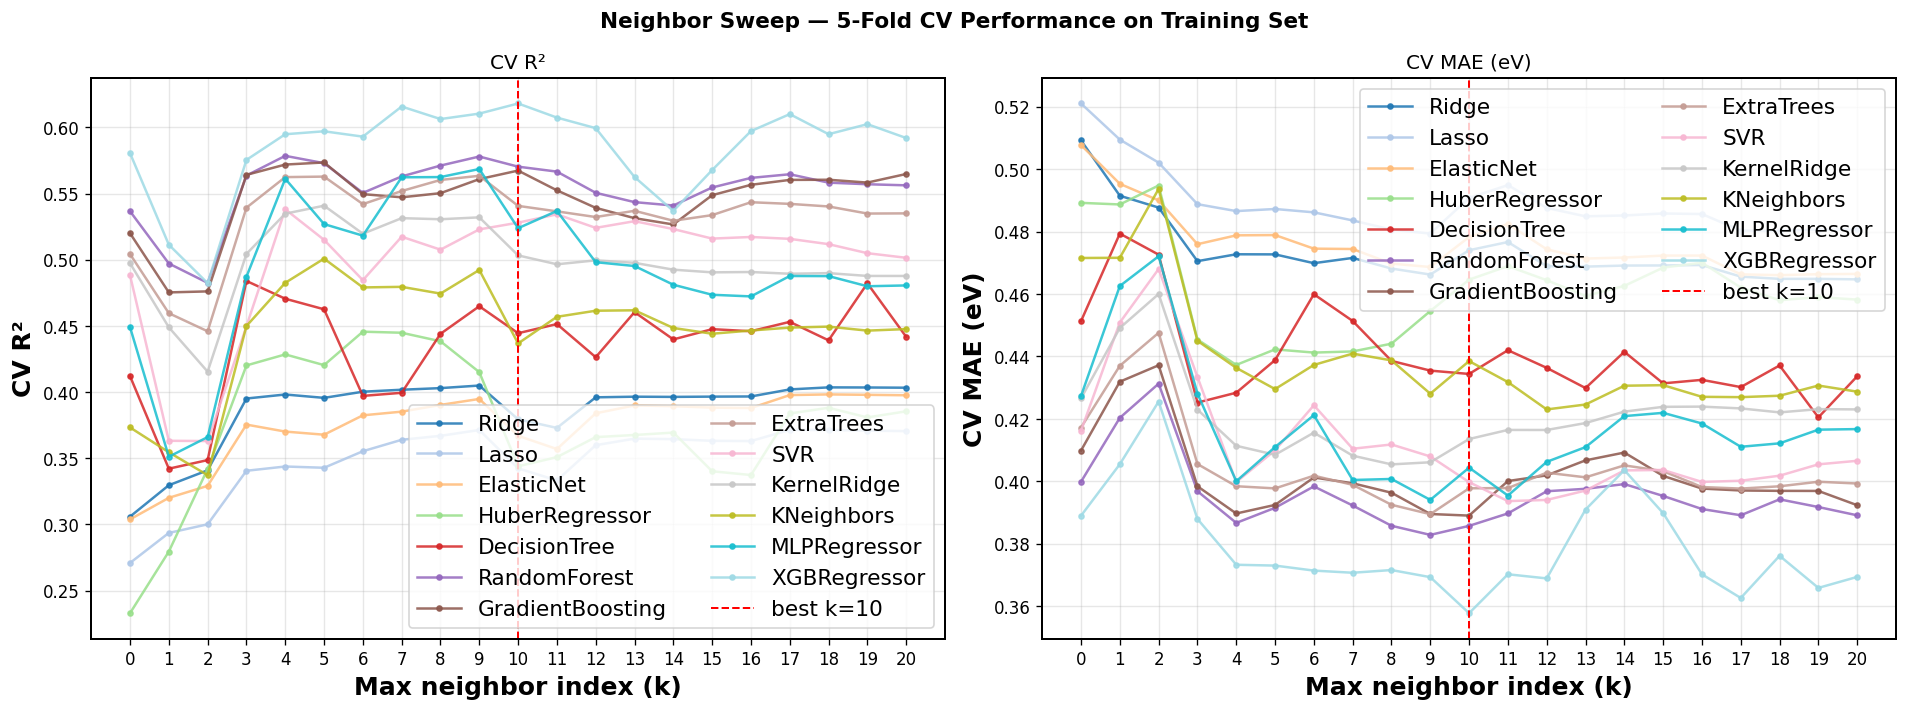

Saved: /home/parastoo/Desktop/ML_project/analysis/ML_project/paper_files/new_ML_5CV/N2_fig1_cv_sweep.png


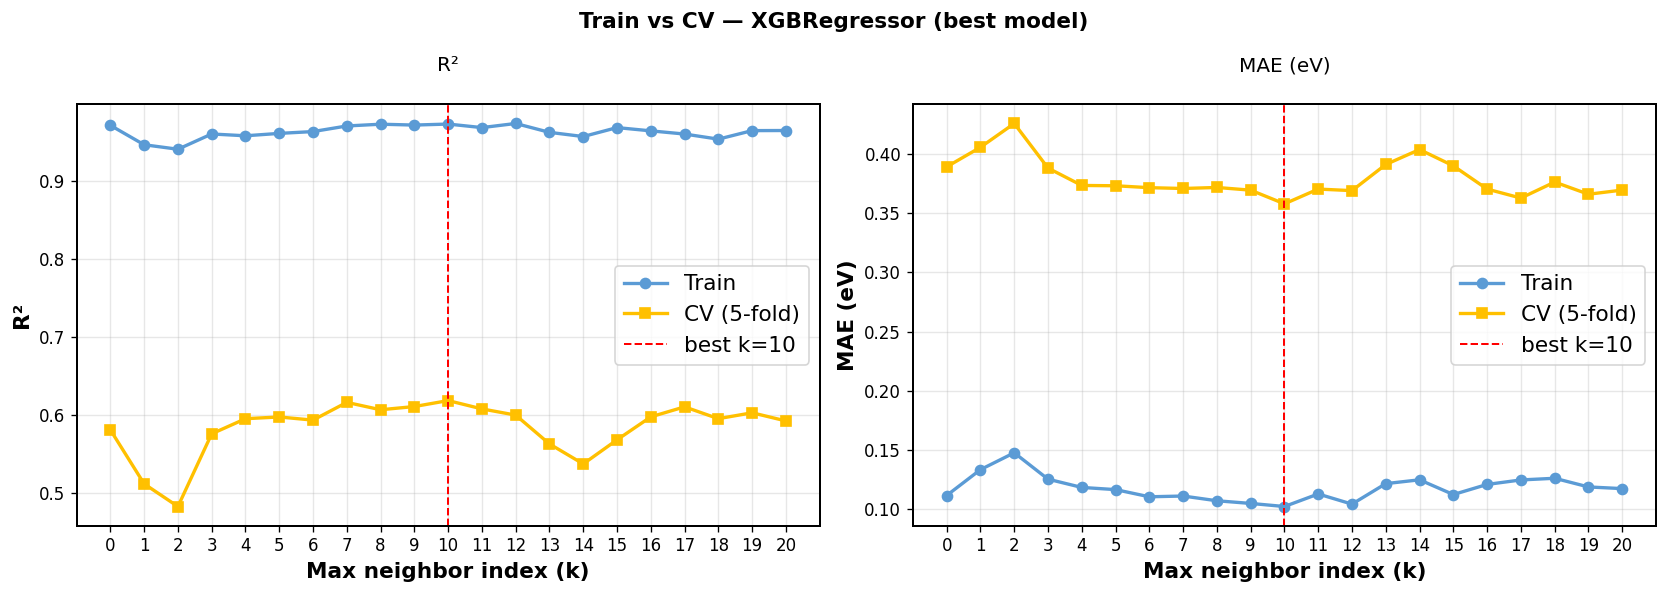

Saved: /home/parastoo/Desktop/ML_project/analysis/ML_project/paper_files/new_ML_5CV/N2_fig2_train_vs_cv.png


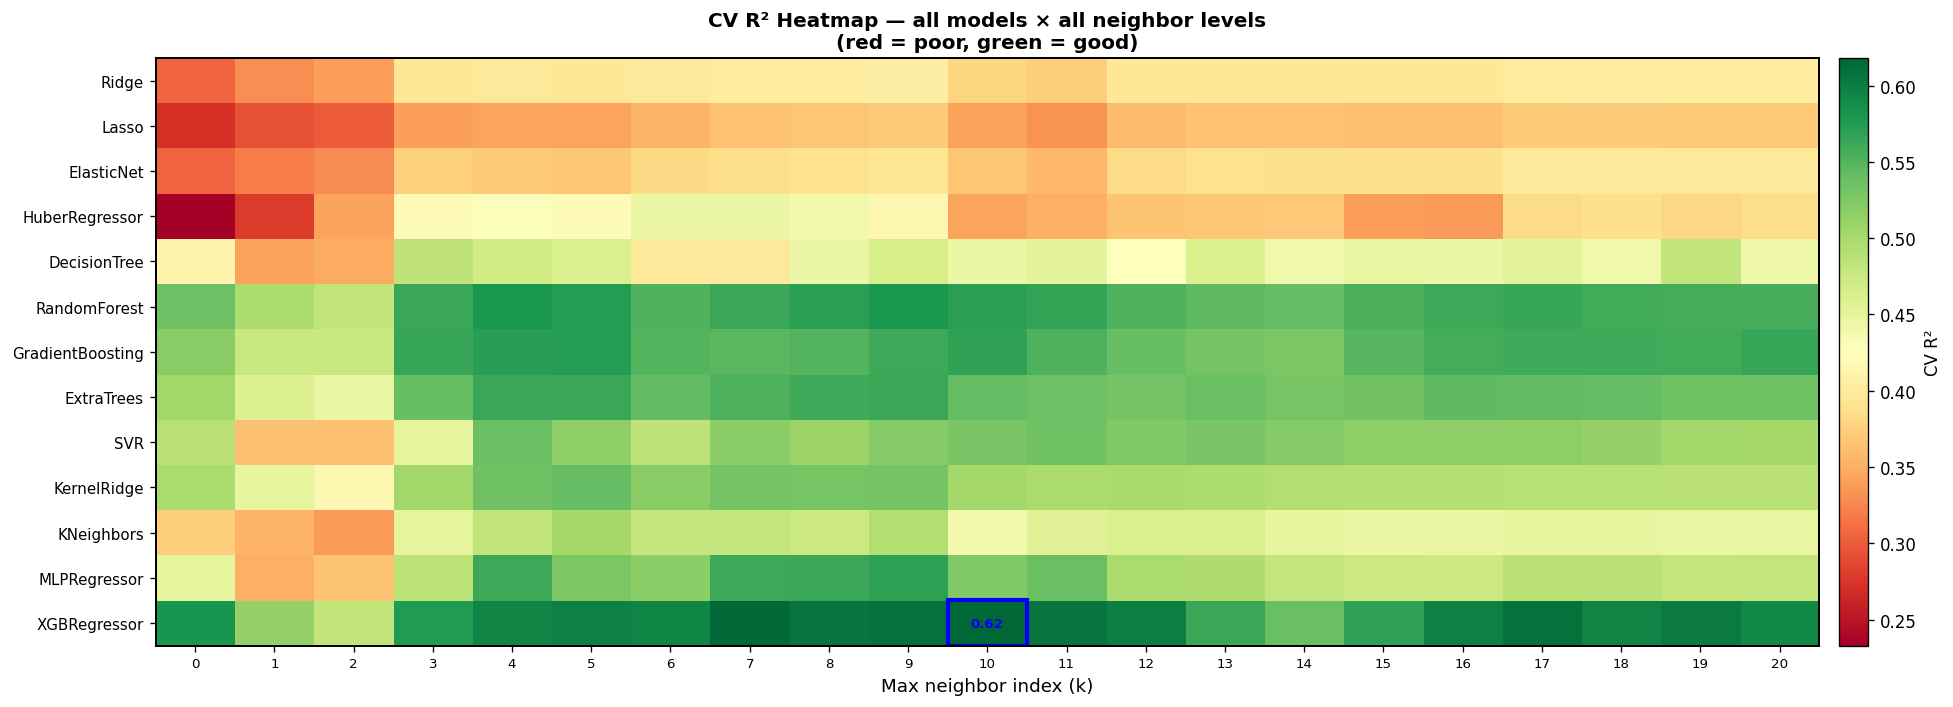

Saved: /home/parastoo/Desktop/ML_project/analysis/ML_project/paper_files/new_ML_5CV/N2_fig3_heatmap.png


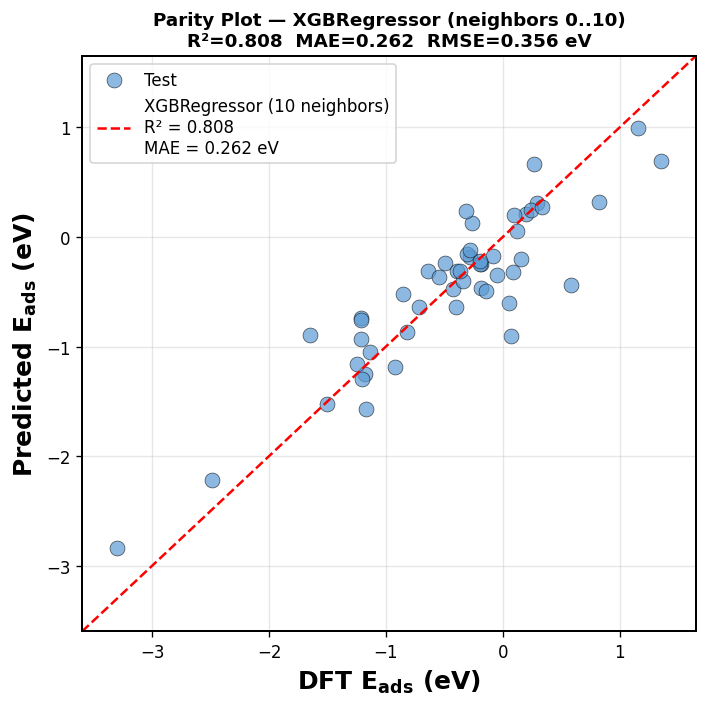

Saved: /home/parastoo/Desktop/ML_project/analysis/ML_project/paper_files/new_ML_5CV/N2_fig4_parity.png


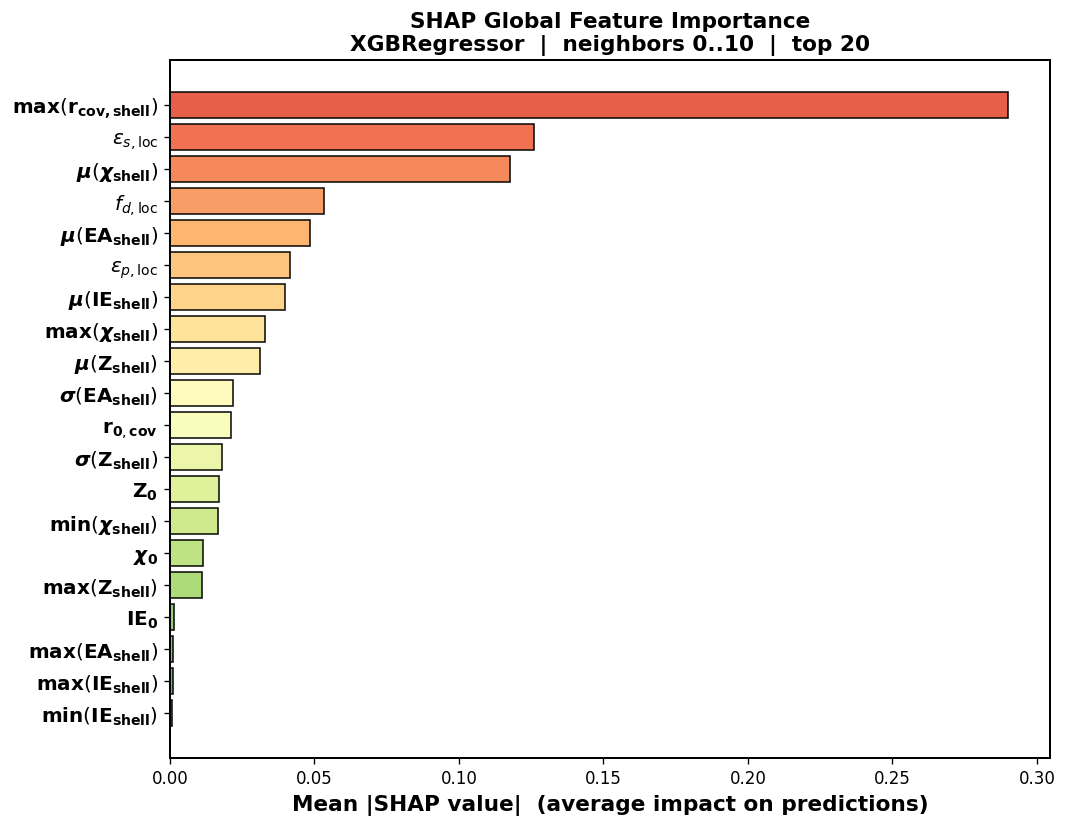

Saved: /home/parastoo/Desktop/ML_project/analysis/ML_project/paper_files/new_ML_5CV/N2_fig5a_shap_bar.png


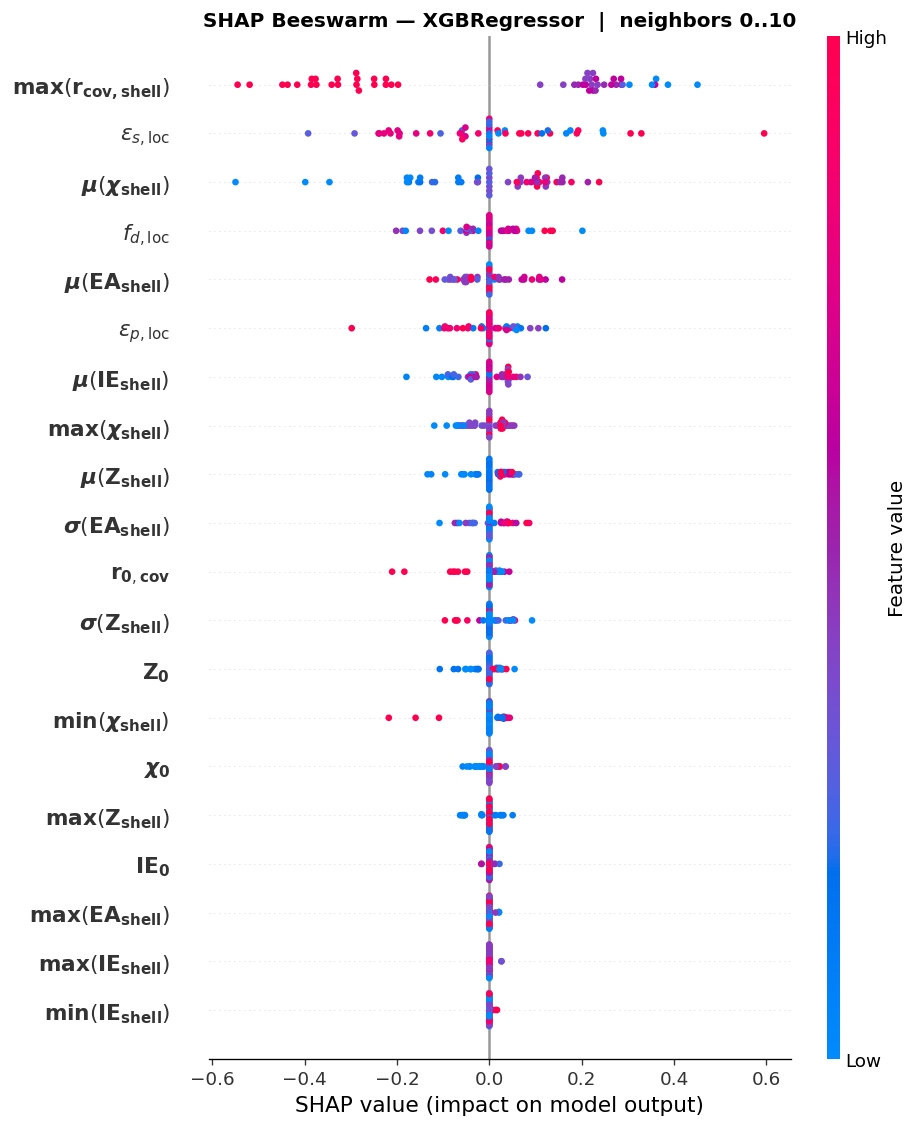

Saved: /home/parastoo/Desktop/ML_project/analysis/ML_project/paper_files/new_ML_5CV/N2_fig5b_beeswarm.png


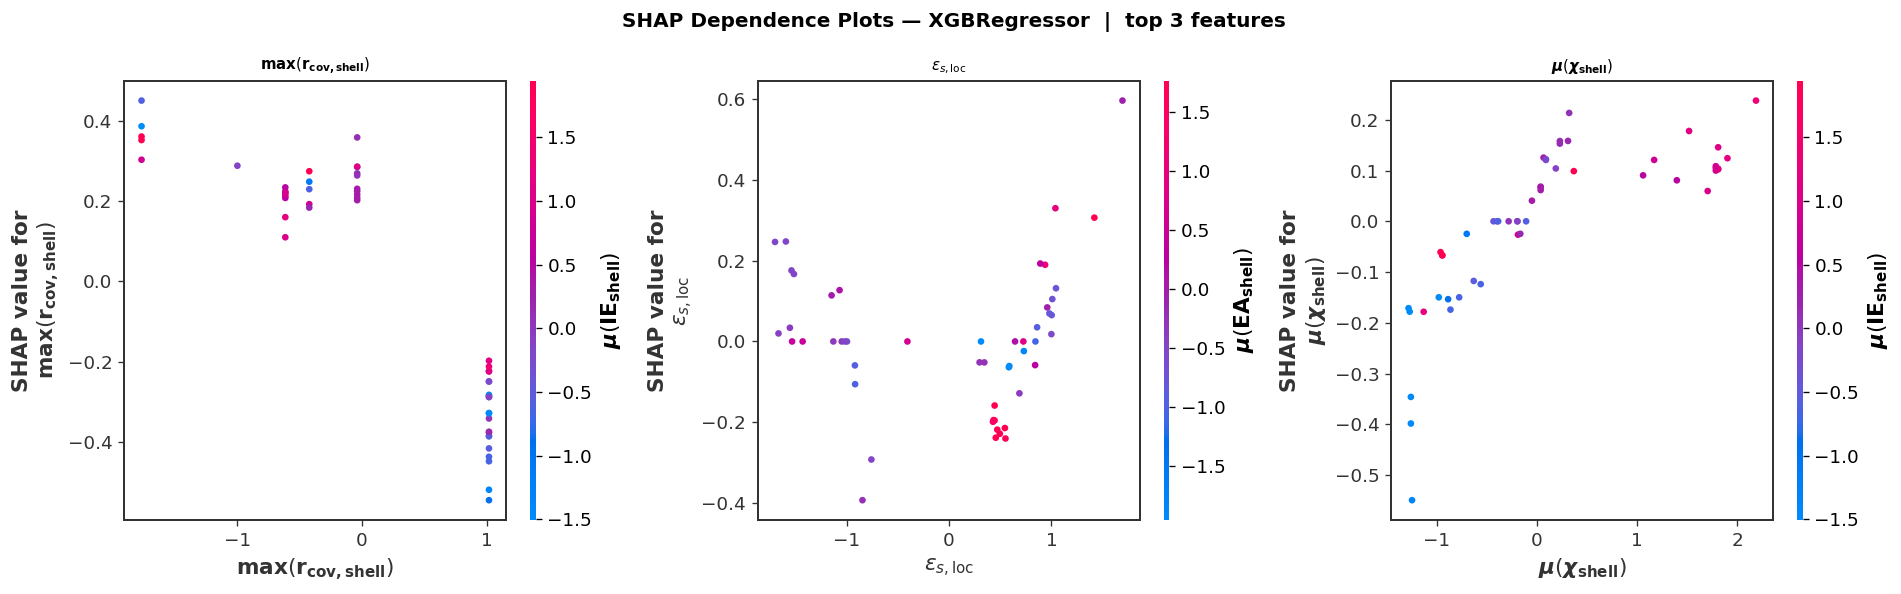

Saved: /home/parastoo/Desktop/ML_project/analysis/ML_project/paper_files/new_ML_5CV/N2_fig5c_dependence.png


In [17]:
# ── Run the pipeline ──────────────────────────────────────────────────────────
results_N2 = run_pipeline(
    df_raw            = df_raw_N2,
    outlier_method    = 'z3',
    n_select_features = 20,
    tested_n_neighbors = 21,
)

# Save after running
with open(save_path + 'results_N2_z3_f20_n21.pkl', 'wb') as f:
    pickle.dump(results_N2, f)

# Reload later — model, SHAP, everything intact 
#with open(save_path + 'results_N2_z3_f20_n21.pkl', 'rb') as f:
#    results = pickle.load(f)

# ── Plot with your own filenames ──────────────────────────────────────────────
plot_cv_sweep(results_N2,    filename= save_path + 'N2_fig1_cv_sweep.png')
plot_train_vs_cv(results_N2, filename= save_path + 'N2_fig2_train_vs_cv.png')
plot_heatmap(results_N2,     filename= save_path + 'N2_fig3_heatmap.png')
plot_parity(results_N2,      filename= save_path + 'N2_fig4_parity.png')
plot_shap(results_N2,
          filename_bar        = save_path + 'N2_fig5a_shap_bar.png',
          filename_beeswarm   = save_path + 'N2_fig5b_beeswarm.png',
          filename_dependence = save_path + 'N2_fig5c_dependence.png')



Outlier filter 'z3' [-7.02, 1.36] eV: 4 removed → 288 samples remain
Filtered dataset : 288 samples
SelectKBest k    : 20
Train: 230 samples | Test: 58 samples

NEIGHBOR SWEEP  (Train & 5-Fold CV on training set only)

  Neighbors 0..0  |  24 features total  |  SelectKBest k=20
  [Global features]    ['crystal_struct', 'sym_group']
  [n0 individual]      ['n0_atomic_number', 'n0_atomic_mass', 'n0_elect_affinity', 'n0_ion_e', 'n0_atomic_radius', 'n0_cov_rad', 'n0_atom_density', 'n0_distance', 'n0_charge', 'n0_electroneg']
  [Final DOS n0_n0]   ['n0_n0_dos_selected_sband_center', 'n0_n0_dos_selected_sband_sum', 'n0_n0_dos_total_sband_center', 'n0_n0_dos_total_sband_sum', 'n0_n0_dos_selected_pband_center', 'n0_n0_dos_selected_pband_sum', 'n0_n0_dos_total_pband_center', 'n0_n0_dos_total_pband_sum', 'n0_n0_dos_selected_dband_center', 'n0_n0_dos_selected_dband_sum', 'n0_n0_dos_total_dband_center', 'n0_n0_dos_total_dband_sum']

  Model                TrainR²   TrainMAE   TrainRMSE    CV_R²  

  0%|          | 0/58 [00:00<?, ?it/s]

✅  Pipeline complete.



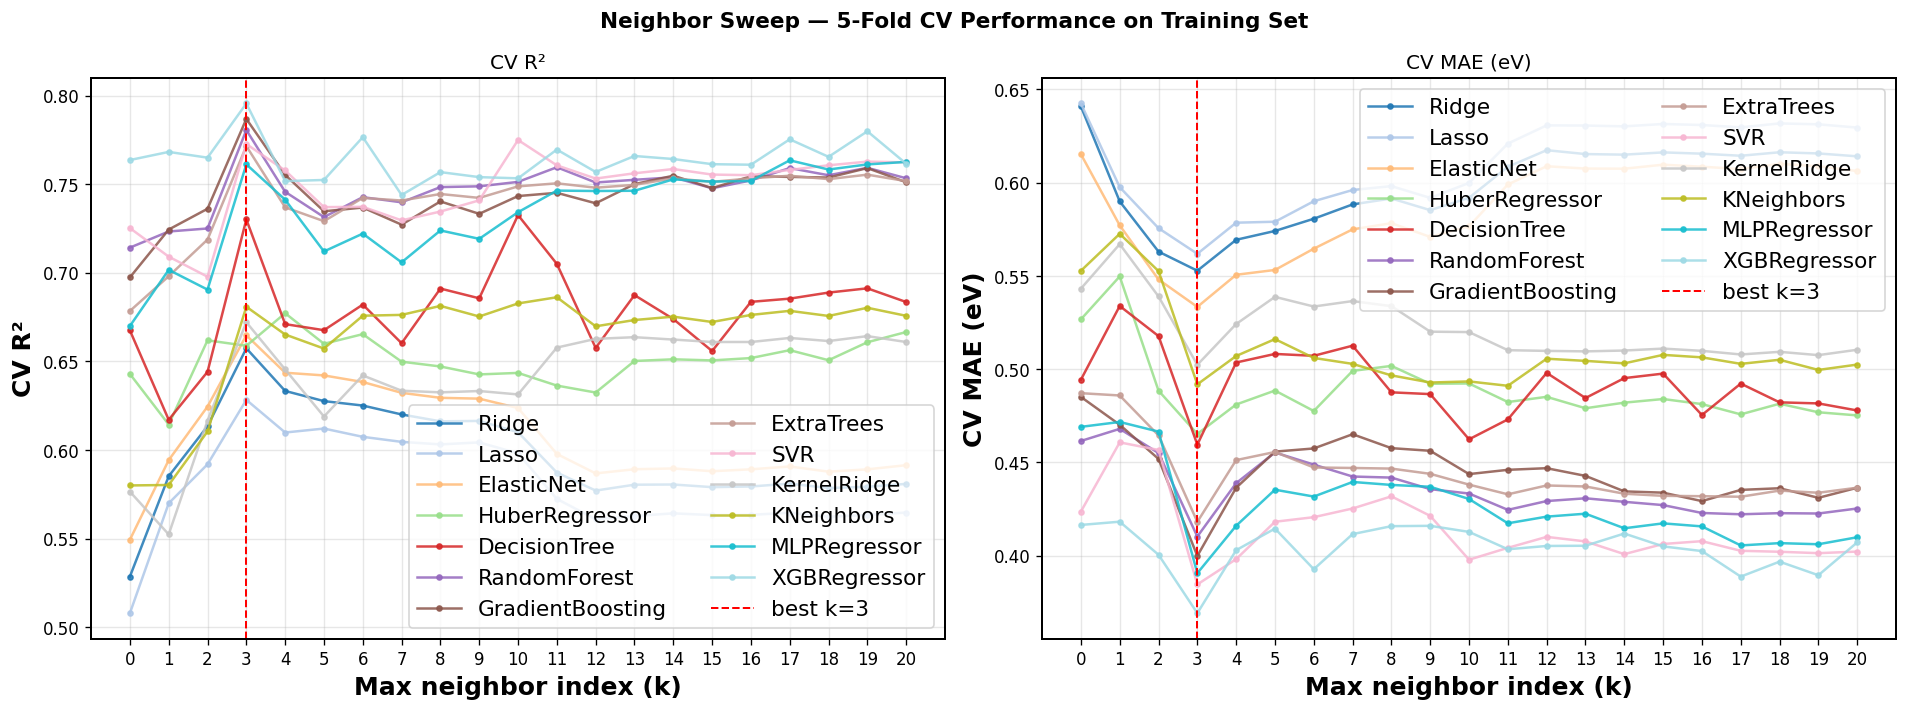

Saved: /home/parastoo/Desktop/ML_project/analysis/ML_project/paper_files/new_ML_5CV/N2H_fig1_cv_sweep.png


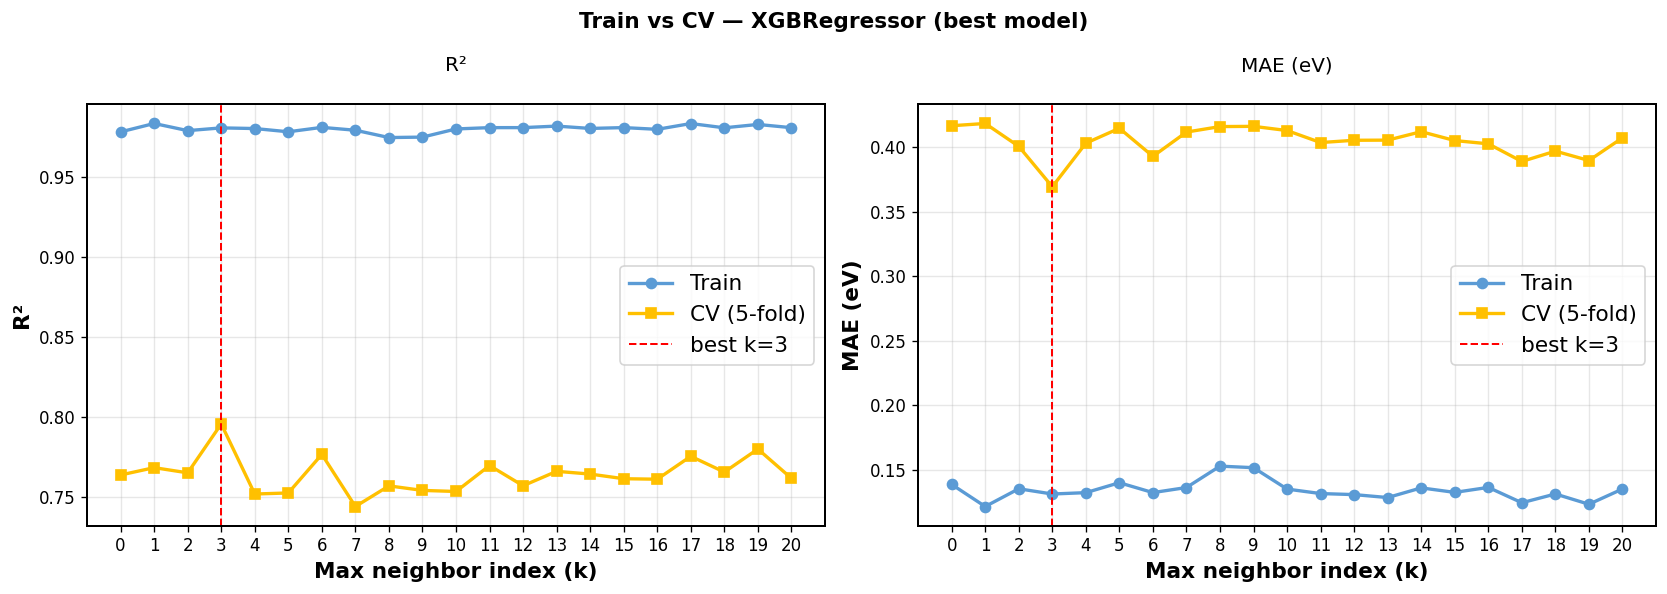

Saved: /home/parastoo/Desktop/ML_project/analysis/ML_project/paper_files/new_ML_5CV/N2H_fig2_train_vs_cv.png


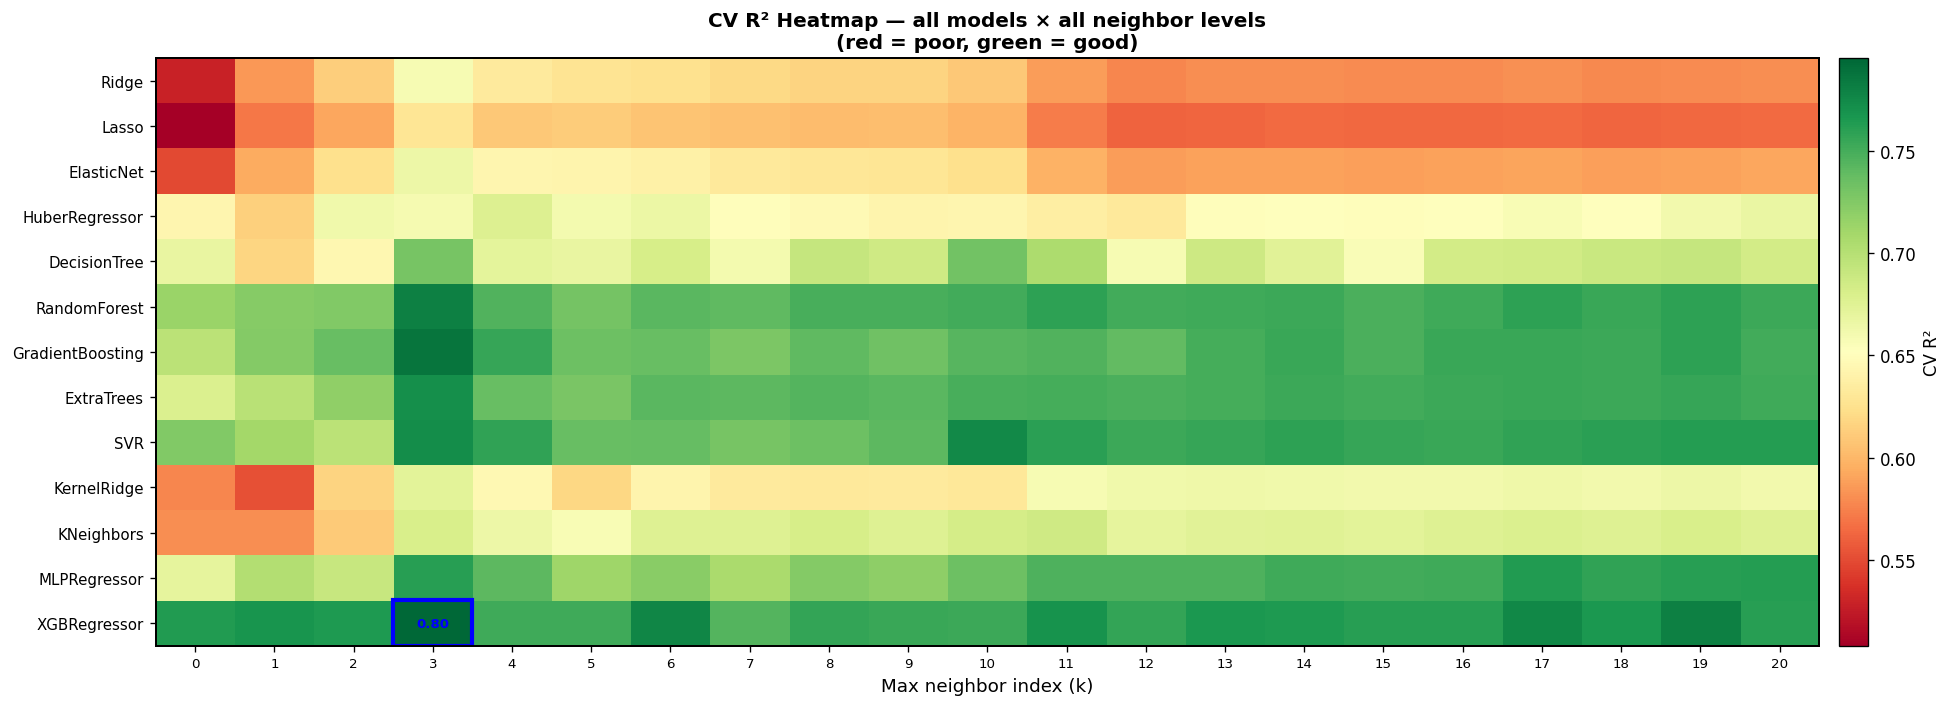

Saved: /home/parastoo/Desktop/ML_project/analysis/ML_project/paper_files/new_ML_5CV/N2H_fig3_heatmap.png


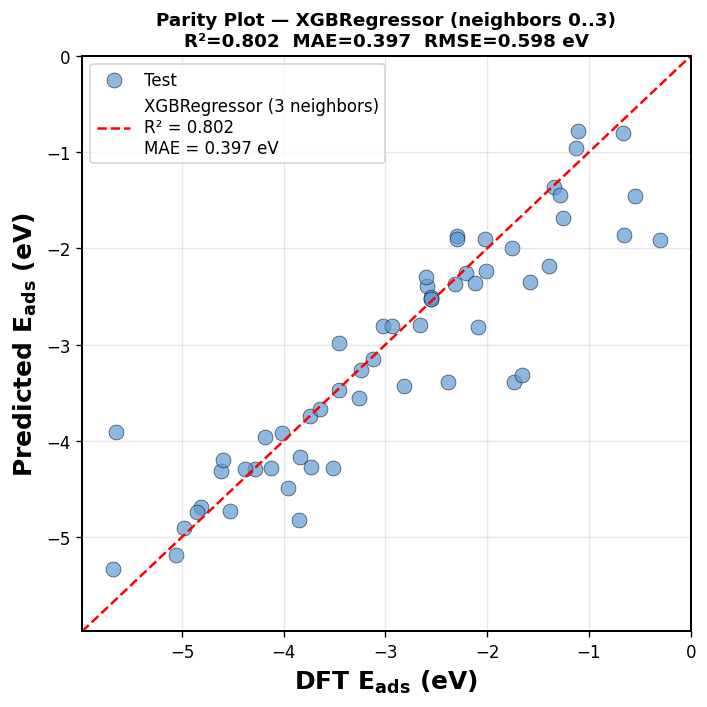

Saved: /home/parastoo/Desktop/ML_project/analysis/ML_project/paper_files/new_ML_5CV/N2H_fig4_parity.png


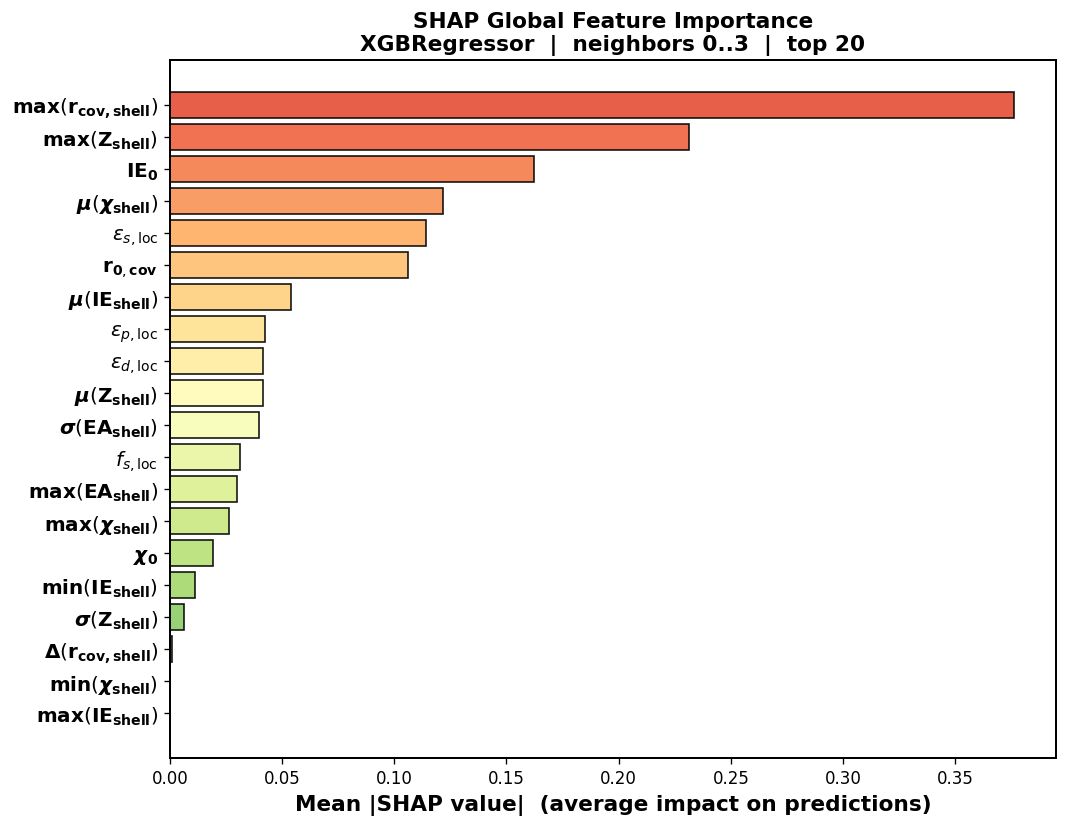

Saved: /home/parastoo/Desktop/ML_project/analysis/ML_project/paper_files/new_ML_5CV/N2H_fig5a_shap_bar.png


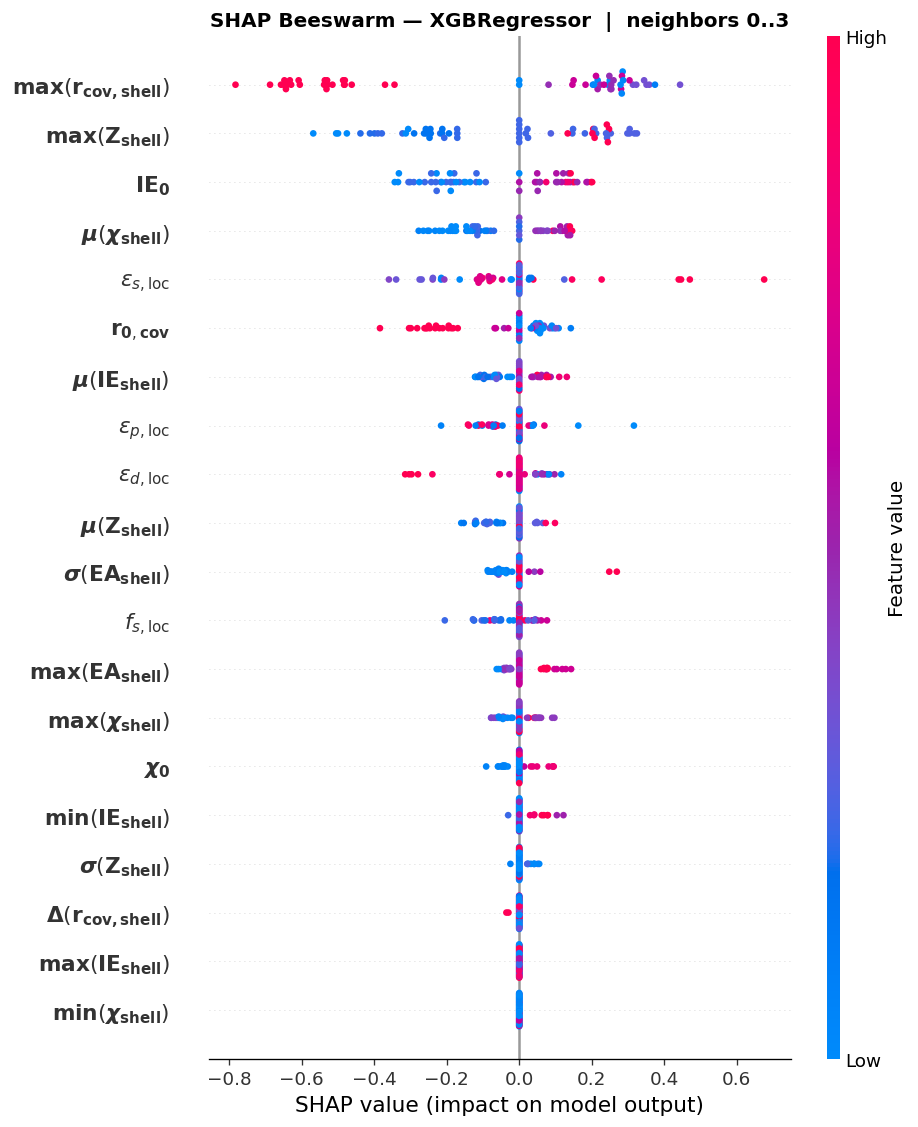

Saved: /home/parastoo/Desktop/ML_project/analysis/ML_project/paper_files/new_ML_5CV/N2H_fig5b_beeswarm.png


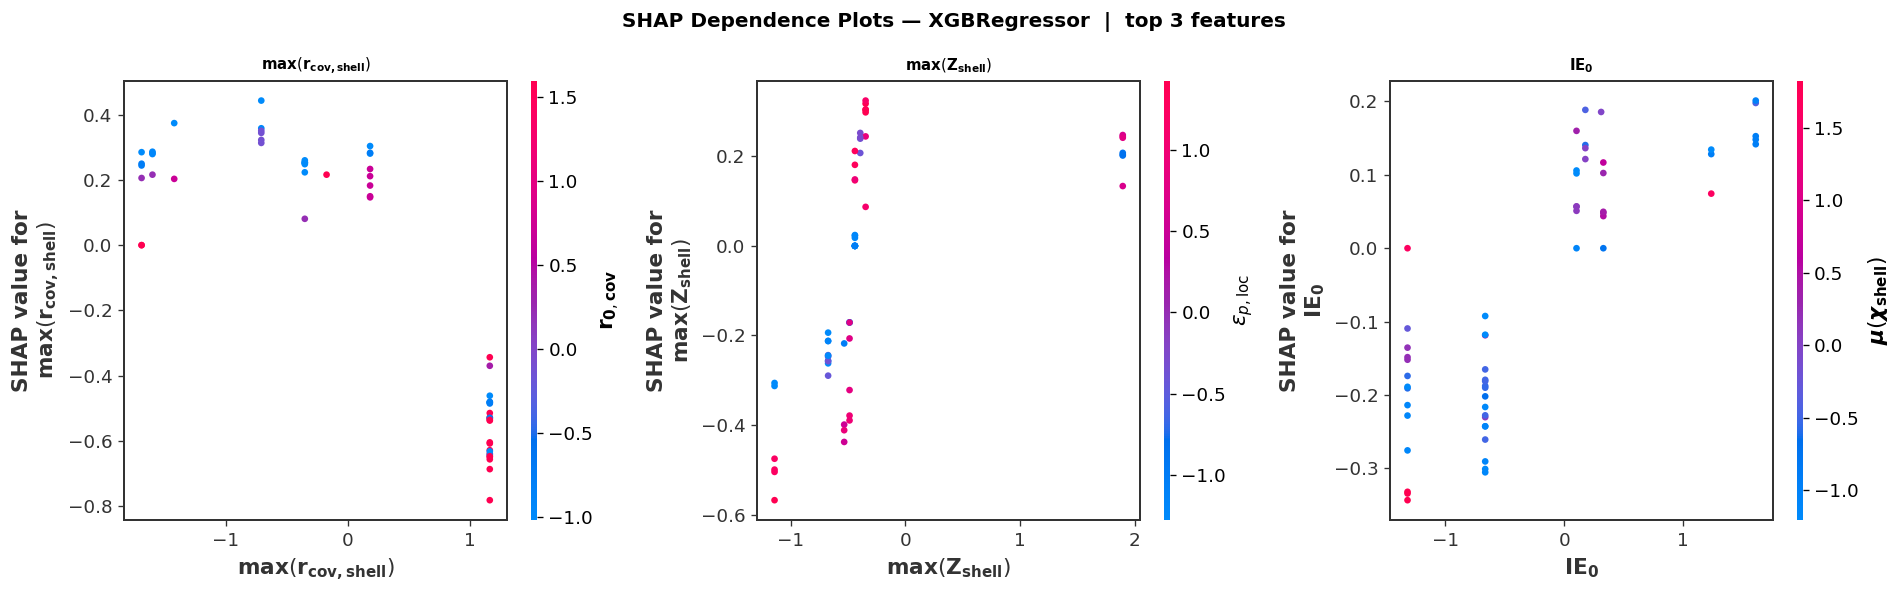

Saved: /home/parastoo/Desktop/ML_project/analysis/ML_project/paper_files/new_ML_5CV/N2H_fig5c_dependence.png


In [11]:
# ── Run the pipeline ──────────────────────────────────────────────────────────
results_N2H = run_pipeline(
    df_raw            = df_raw_N2H,
    outlier_method    = 'z3',
    n_select_features = 20,
    tested_n_neighbors = 21,
)

# Save after running
with open(save_path + 'results_N2H_z3_f20_n21.pkl', 'wb') as f:
    pickle.dump(results_N2H, f)

# Reload later — model, SHAP, everything intact 
#with open(save_path + 'results_N2H_z3_f20_n21.pkl', 'rb') as f:
#    results = pickle.load(f)

# ── Plot with your own filenames ──────────────────────────────────────────────
plot_cv_sweep(results_N2H,    filename= save_path + 'N2H_fig1_cv_sweep.png')
plot_train_vs_cv(results_N2H, filename= save_path + 'N2H_fig2_train_vs_cv.png')
plot_heatmap(results_N2H,     filename= save_path + 'N2H_fig3_heatmap.png')
plot_parity(results_N2H,      filename= save_path + 'N2H_fig4_parity.png')
plot_shap(results_N2H,
          filename_bar        = save_path + 'N2H_fig5a_shap_bar.png',
          filename_beeswarm   = save_path + 'N2H_fig5b_beeswarm.png',
          filename_dependence = save_path + 'N2H_fig5c_dependence.png')


Outlier filter 'z3' [-3.20, 1.19] eV: 10 removed → 365 samples remain
Filtered dataset : 365 samples
SelectKBest k    : 20
Train: 292 samples | Test: 73 samples

NEIGHBOR SWEEP  (Train & 5-Fold CV on training set only)

  Neighbors 0..0  |  24 features total  |  SelectKBest k=20
  [Global features]    ['crystal_struct', 'sym_group']
  [n0 individual]      ['n0_atomic_number', 'n0_atomic_mass', 'n0_elect_affinity', 'n0_ion_e', 'n0_atomic_radius', 'n0_cov_rad', 'n0_atom_density', 'n0_distance', 'n0_charge', 'n0_electroneg']
  [Final DOS n0_n0]   ['n0_n0_dos_selected_sband_center', 'n0_n0_dos_selected_sband_sum', 'n0_n0_dos_total_sband_center', 'n0_n0_dos_total_sband_sum', 'n0_n0_dos_selected_pband_center', 'n0_n0_dos_selected_pband_sum', 'n0_n0_dos_total_pband_center', 'n0_n0_dos_total_pband_sum', 'n0_n0_dos_selected_dband_center', 'n0_n0_dos_selected_dband_sum', 'n0_n0_dos_total_dband_center', 'n0_n0_dos_total_dband_sum']

  Model                TrainR²   TrainMAE   TrainRMSE    CV_R² 

  0%|          | 0/73 [00:00<?, ?it/s]

✅  Pipeline complete.



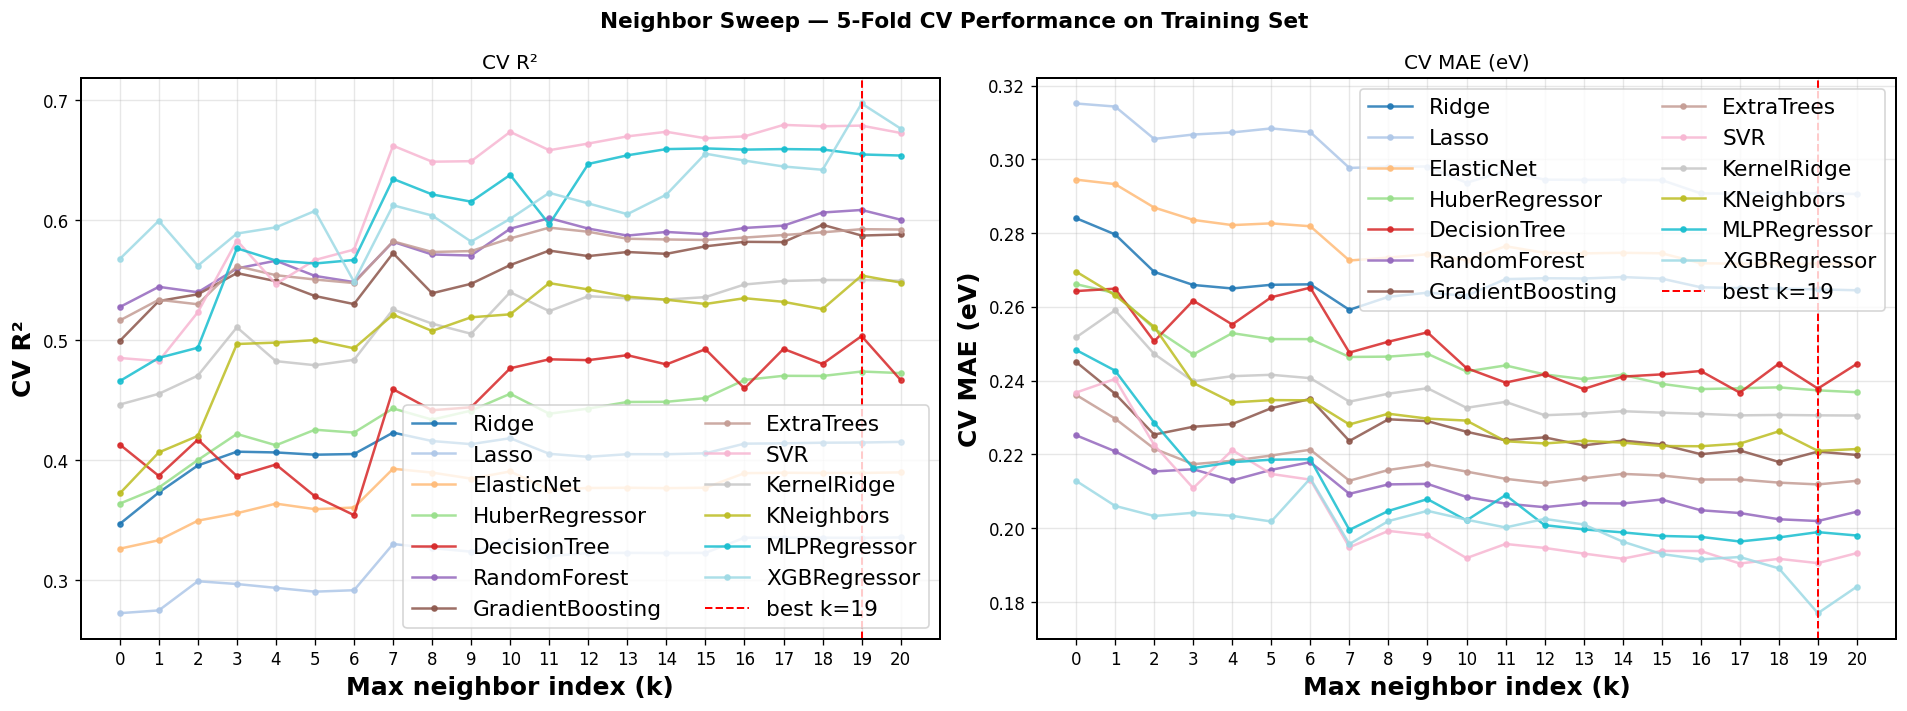

Saved: /home/parastoo/Desktop/ML_project/analysis/ML_project/paper_files/new_ML_5CV/NH3_fig1_cv_sweep.png


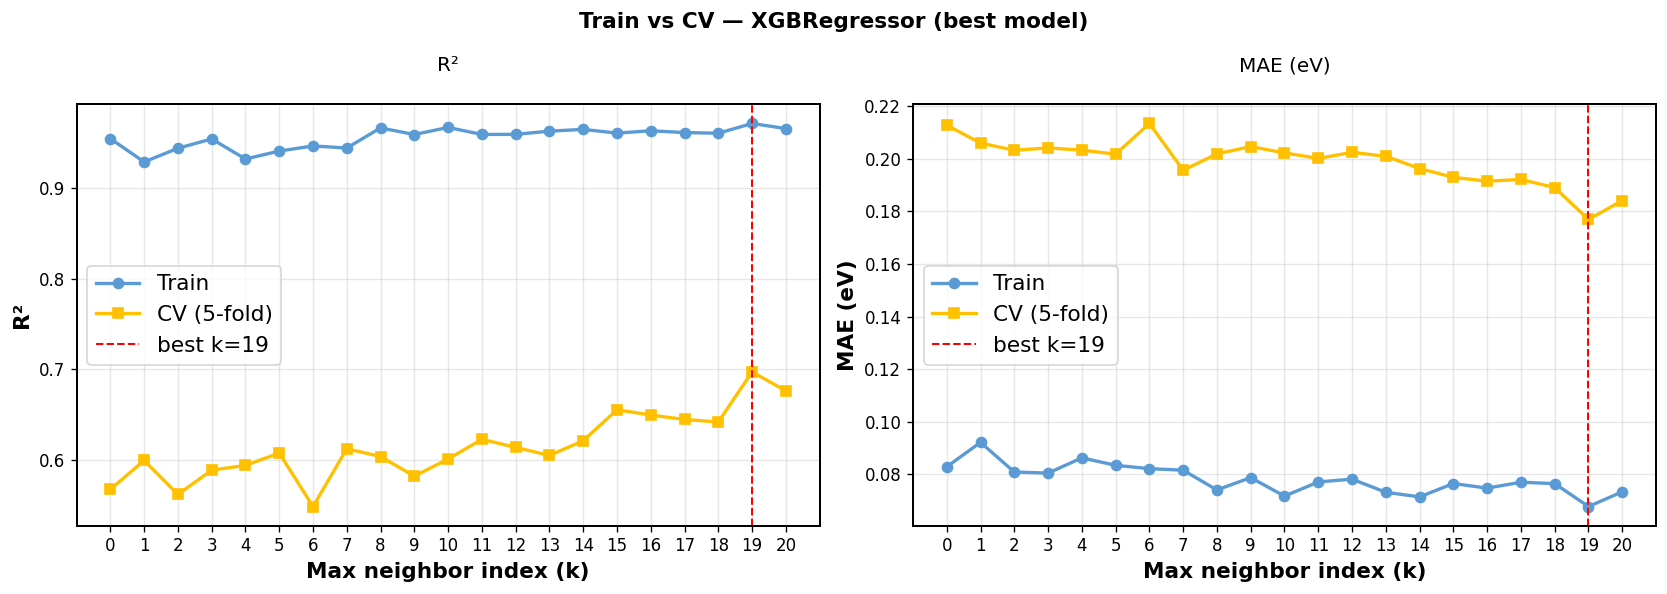

Saved: /home/parastoo/Desktop/ML_project/analysis/ML_project/paper_files/new_ML_5CV/NH3_fig2_train_vs_cv.png


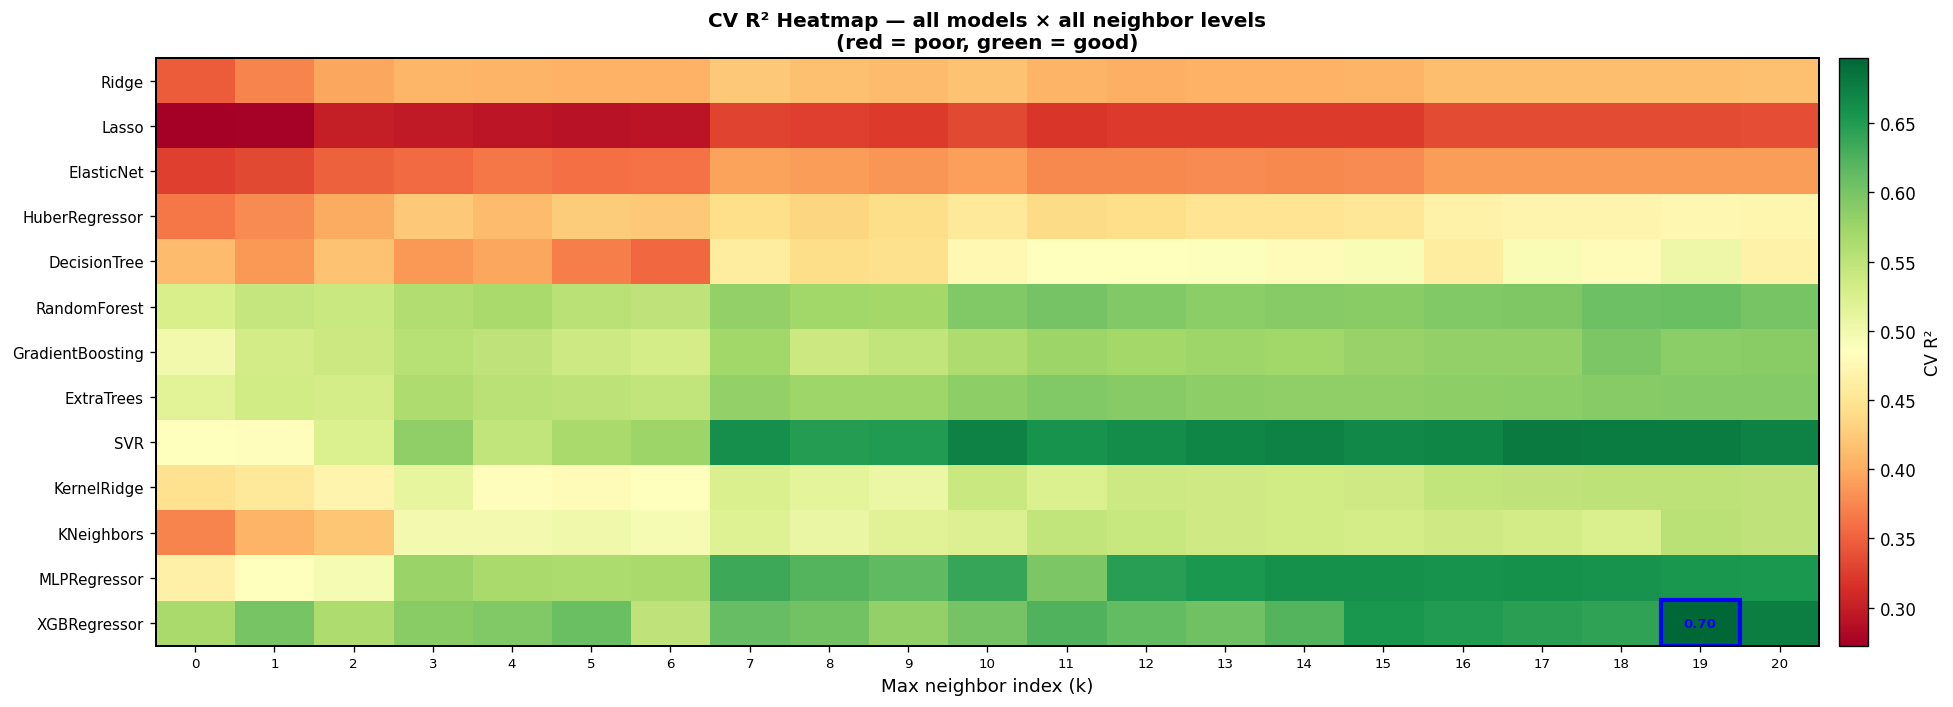

Saved: /home/parastoo/Desktop/ML_project/analysis/ML_project/paper_files/new_ML_5CV/NH3_fig3_heatmap.png


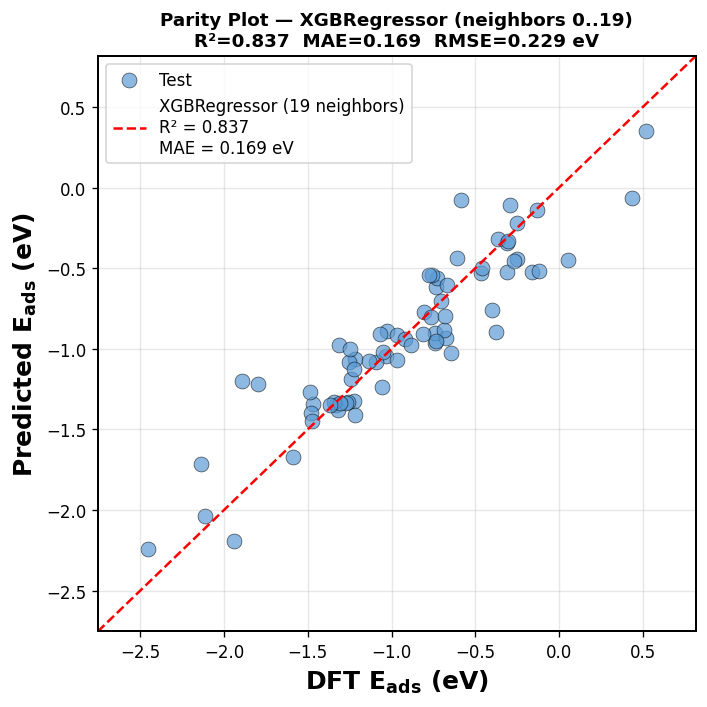

Saved: /home/parastoo/Desktop/ML_project/analysis/ML_project/paper_files/new_ML_5CV/NH3_fig4_parity.png


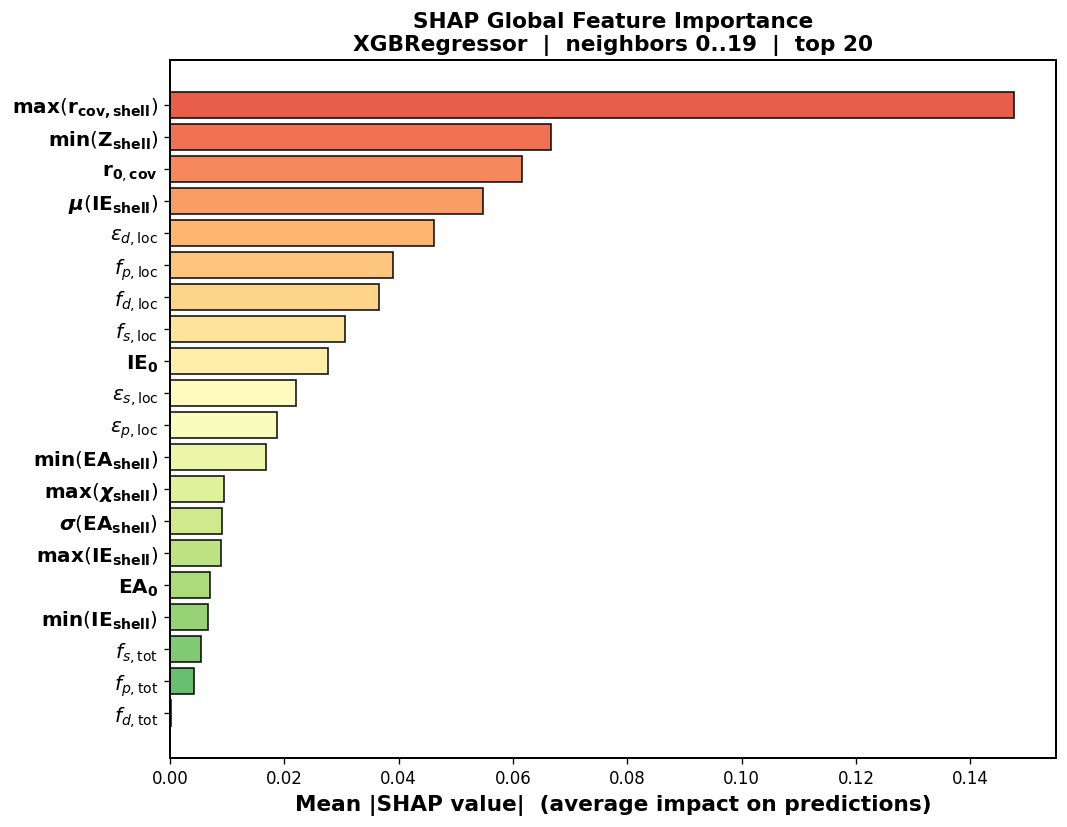

Saved: /home/parastoo/Desktop/ML_project/analysis/ML_project/paper_files/new_ML_5CV/NH3_fig5a_shap_bar.png


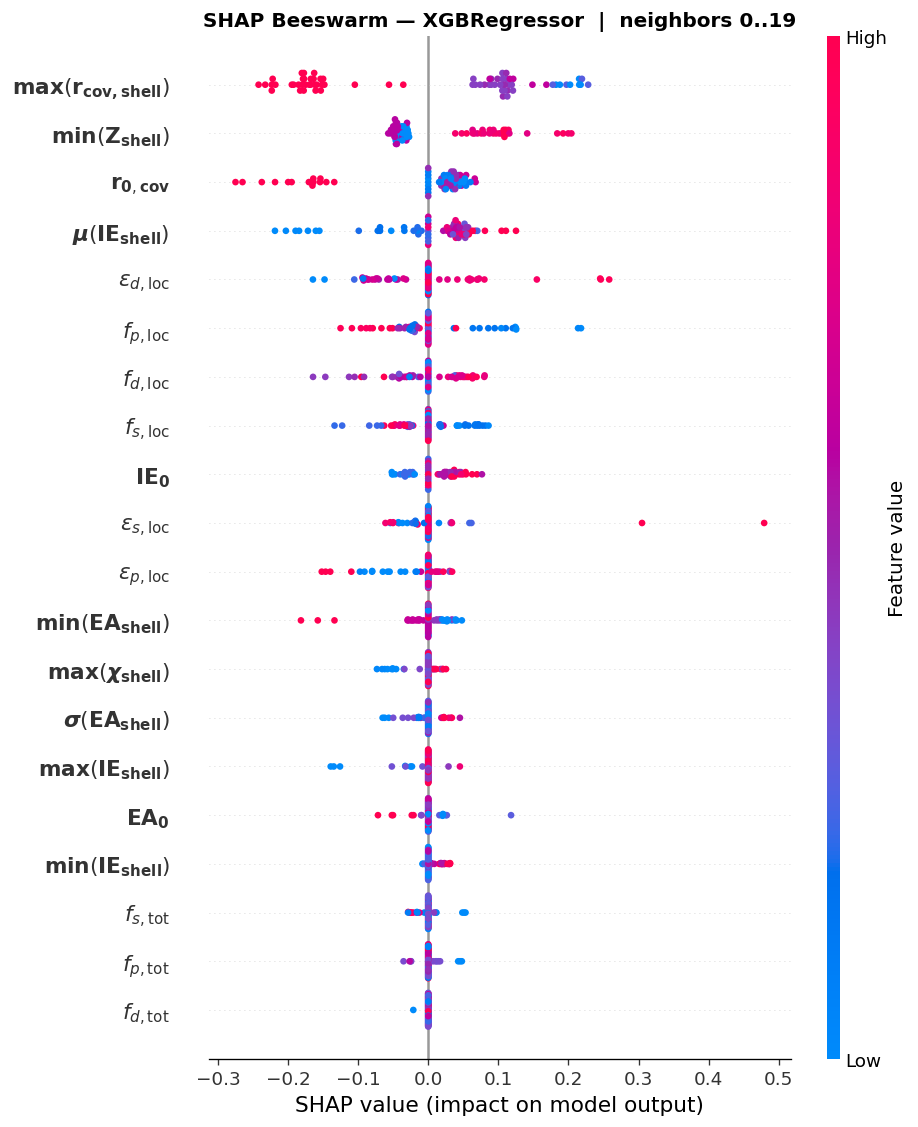

Saved: /home/parastoo/Desktop/ML_project/analysis/ML_project/paper_files/new_ML_5CV/NH3_fig5b_beeswarm.png


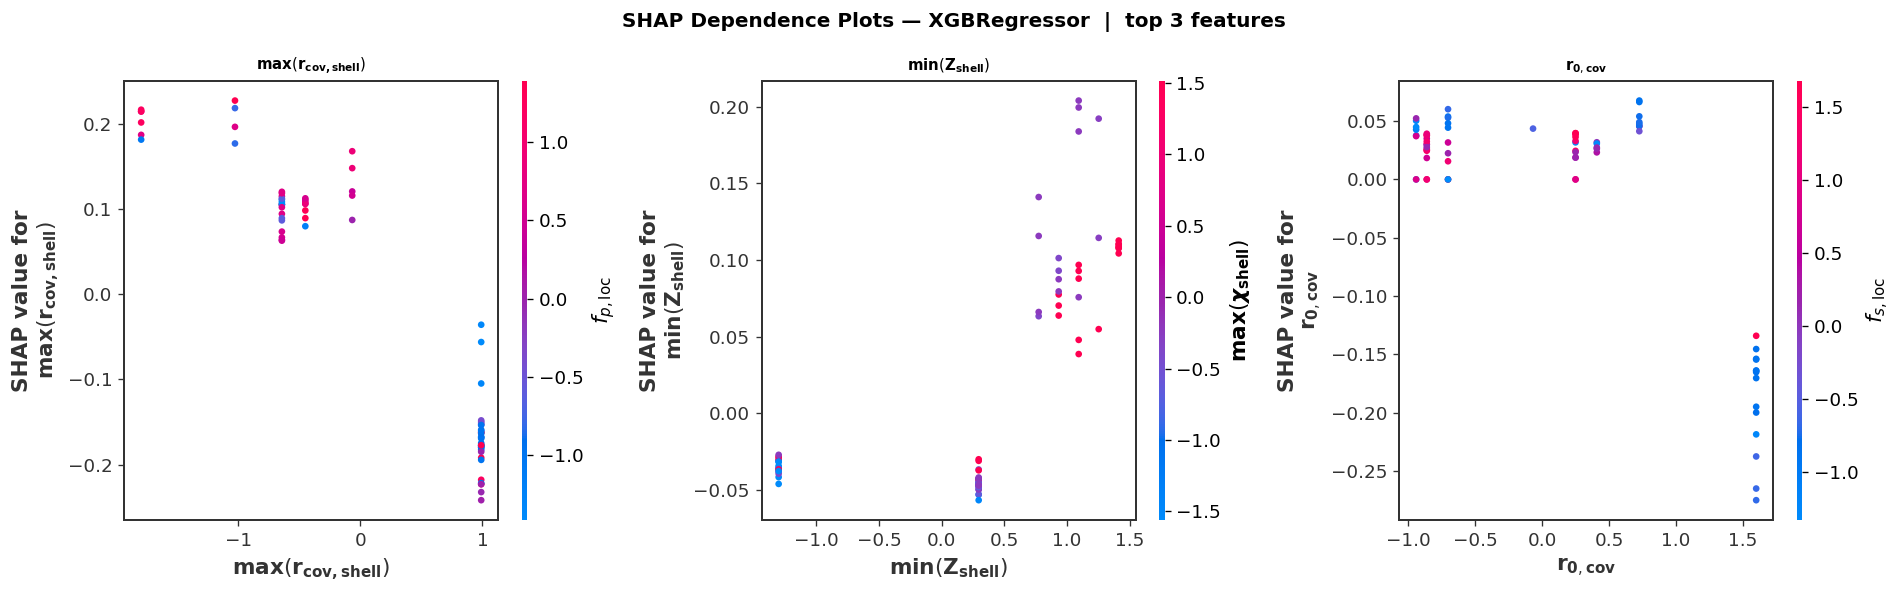

Saved: /home/parastoo/Desktop/ML_project/analysis/ML_project/paper_files/new_ML_5CV/NH3_fig5c_dependence.png


In [12]:
# ── Run the pipeline ──────────────────────────────────────────────────────────
results_NH3 = run_pipeline(
    df_raw            = df_raw_NH3,
    outlier_method    = 'z3',
    n_select_features = 20,
    tested_n_neighbors = 21,
)

# Save after running
with open(save_path + 'results_NH3_z3_f20_n21.pkl', 'wb') as f:
    pickle.dump(results_NH3, f)

# Reload later — model, SHAP, everything intact 
#with open(save_path + 'results_NH3_z3_f20_n21.pkl', 'rb') as f:
#    results = pickle.load(f)

# ── Plot with your own filenames ──────────────────────────────────────────────
plot_cv_sweep(results_NH3,    filename= save_path + 'NH3_fig1_cv_sweep.png')
plot_train_vs_cv(results_NH3, filename= save_path + 'NH3_fig2_train_vs_cv.png')
plot_heatmap(results_NH3,     filename= save_path + 'NH3_fig3_heatmap.png')
plot_parity(results_NH3,      filename= save_path + 'NH3_fig4_parity.png')
plot_shap(results_NH3,
          filename_bar        = save_path + 'NH3_fig5a_shap_bar.png',
          filename_beeswarm   = save_path + 'NH3_fig5b_beeswarm.png',
          filename_dependence = save_path + 'NH3_fig5c_dependence.png')

File size: 494366 bytes


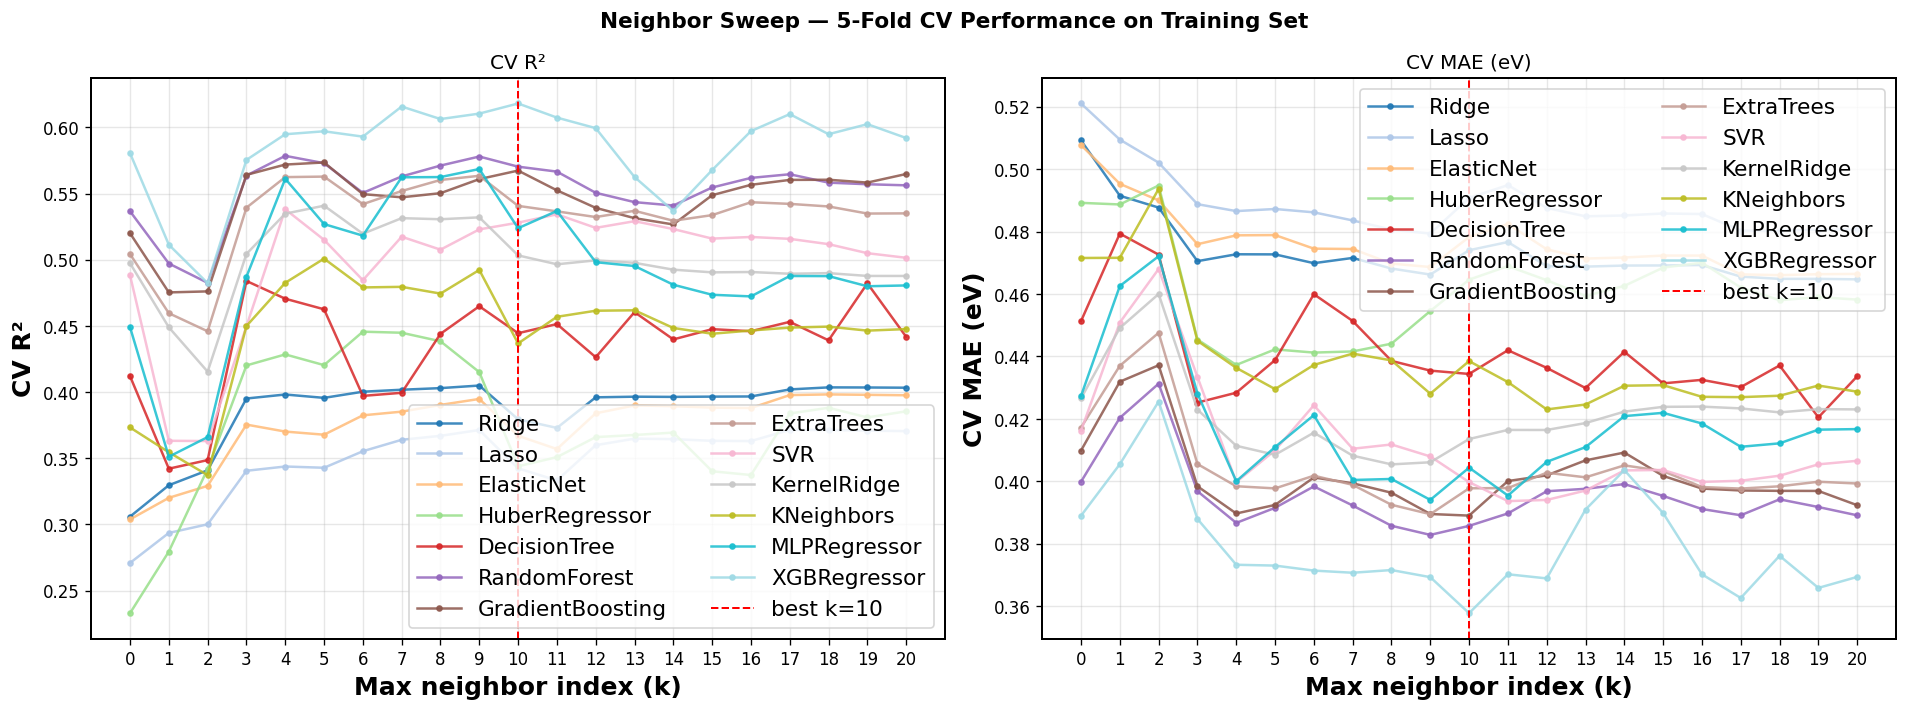

Saved: /home/parastoo/Desktop/ML_project/analysis/ML_project/paper_files/new_ML_5CV/N2_f20_outlierz3_n21_cv_sweep.pdf


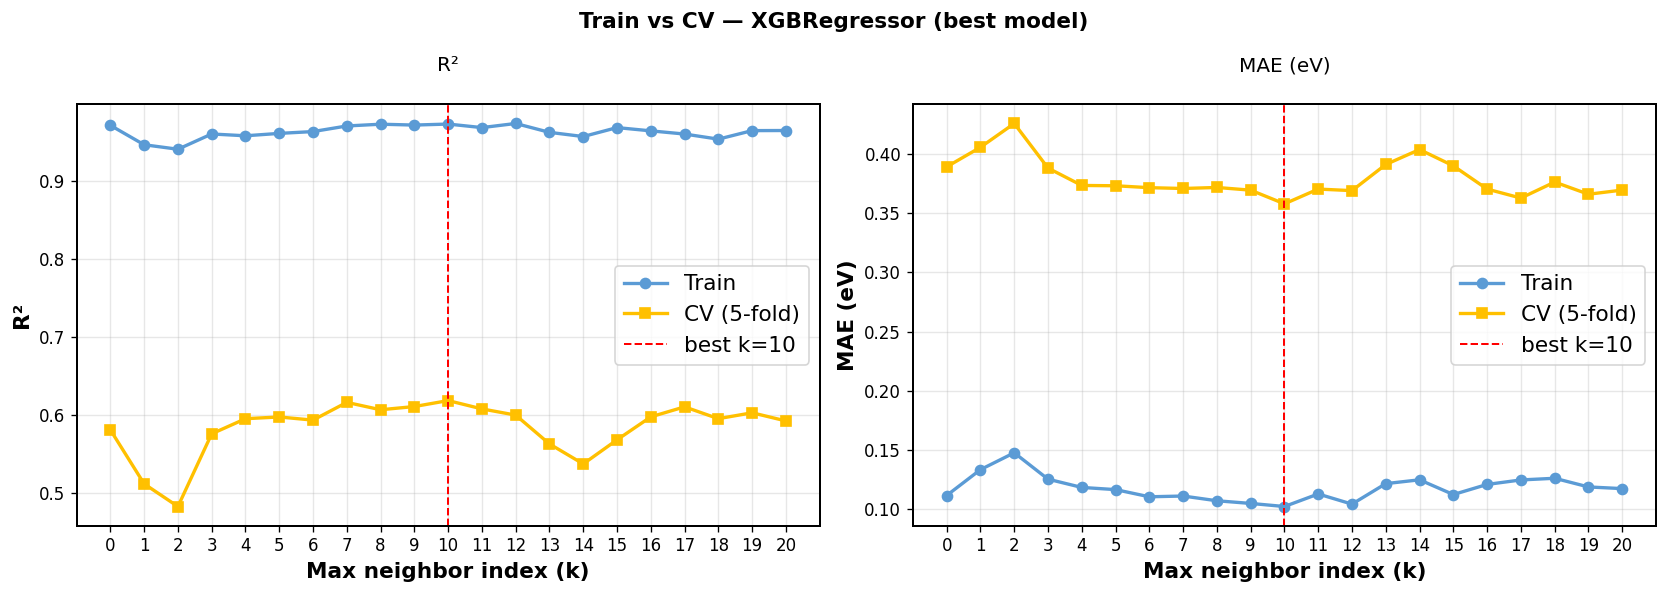

Saved: /home/parastoo/Desktop/ML_project/analysis/ML_project/paper_files/new_ML_5CV/N2_f20_outlierz3_n21_train_vs_cv.pdf


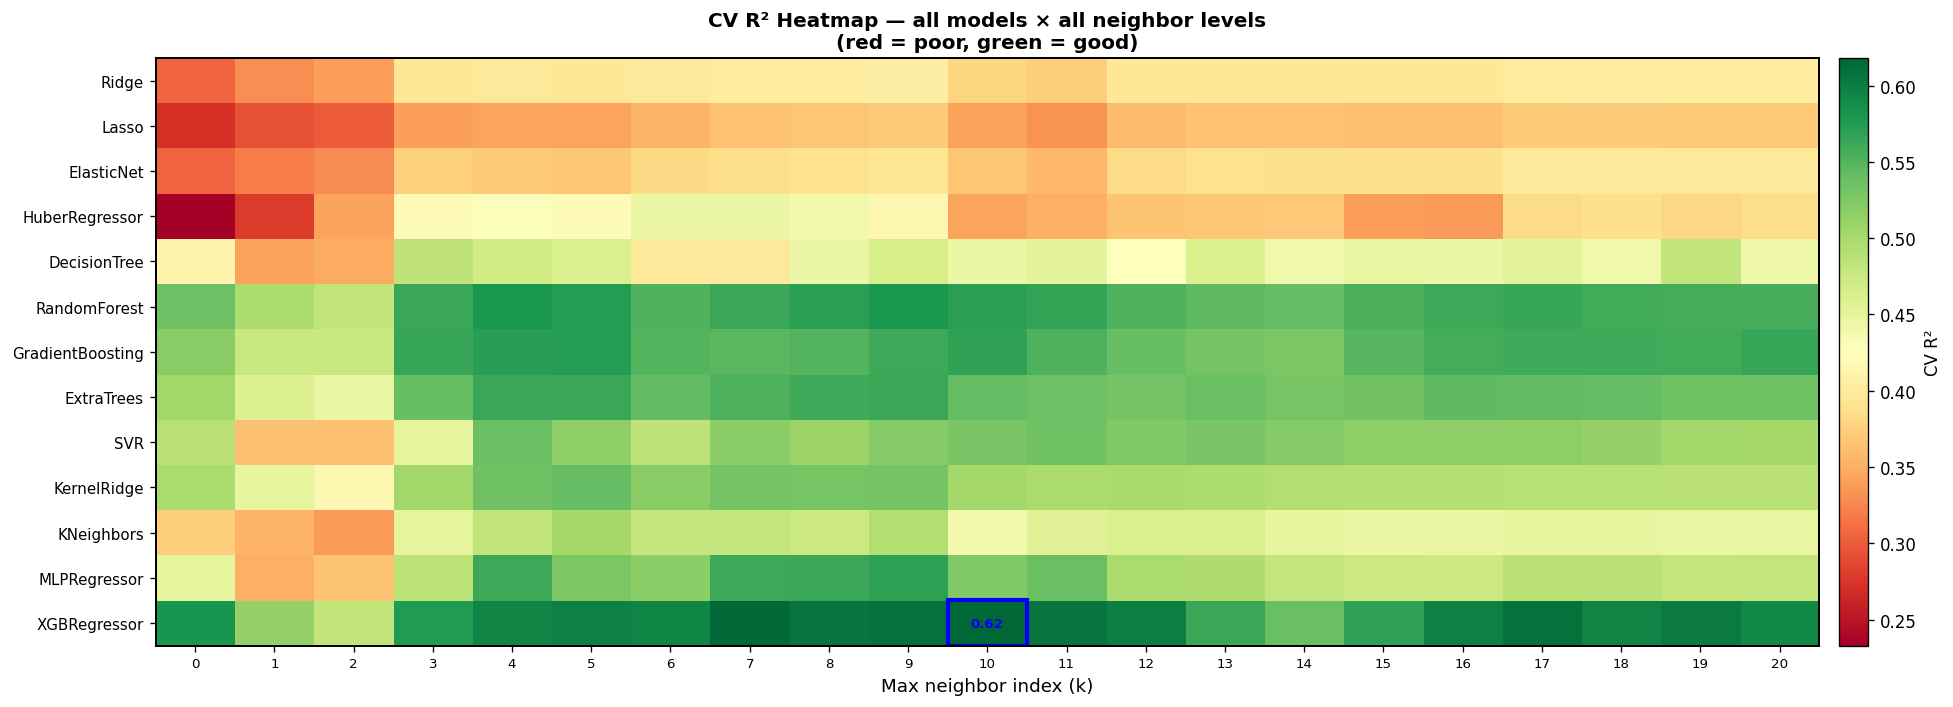

Saved: /home/parastoo/Desktop/ML_project/analysis/ML_project/paper_files/new_ML_5CV/N2_f20_outlierz3_n21_heatmap.pdf


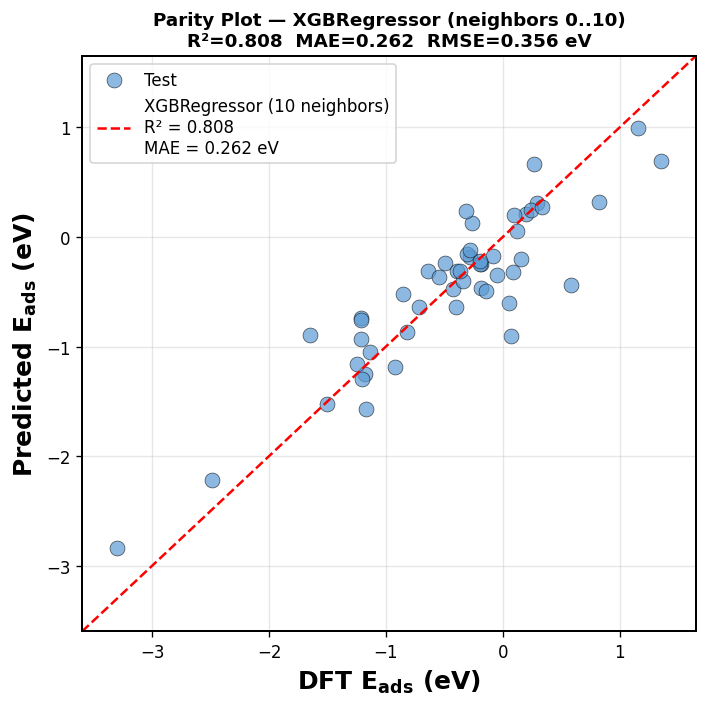

Saved: /home/parastoo/Desktop/ML_project/analysis/ML_project/paper_files/new_ML_5CV/N2_f20_outlierz3_n21_parity.pdf


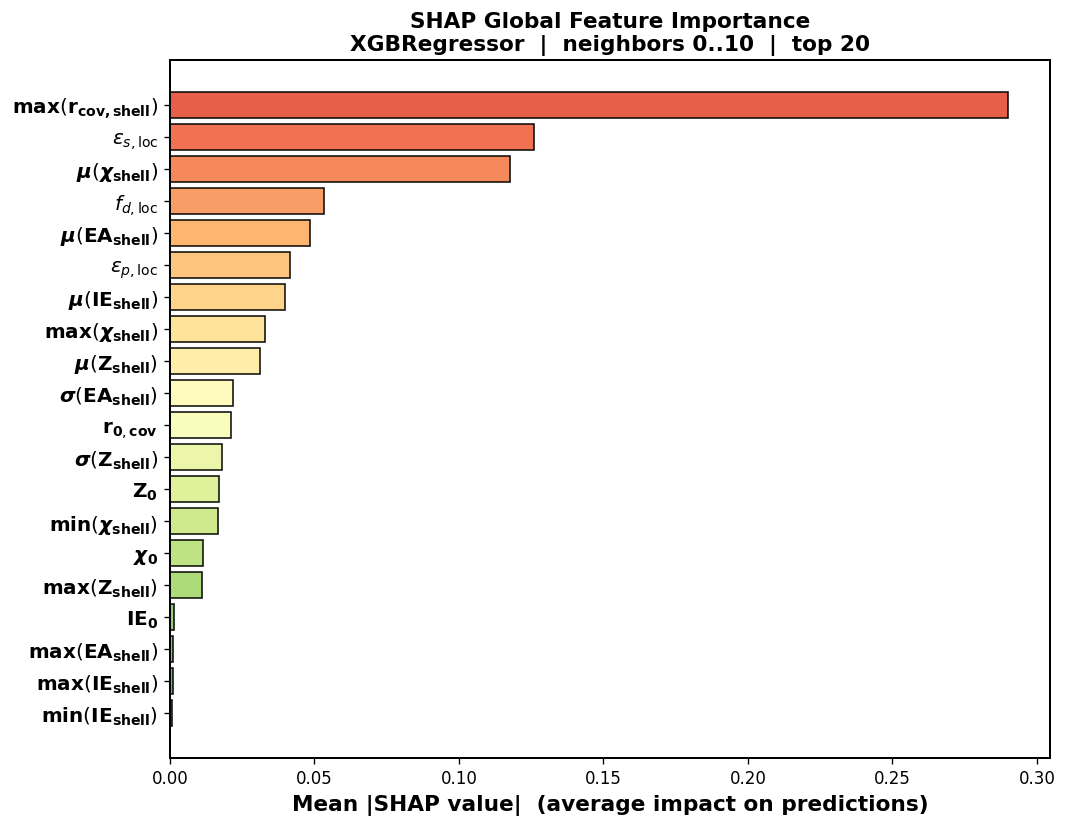

Saved: /home/parastoo/Desktop/ML_project/analysis/ML_project/paper_files/new_ML_5CV/N2_f20_outlierz3_n21_shaptest_bar.pdf


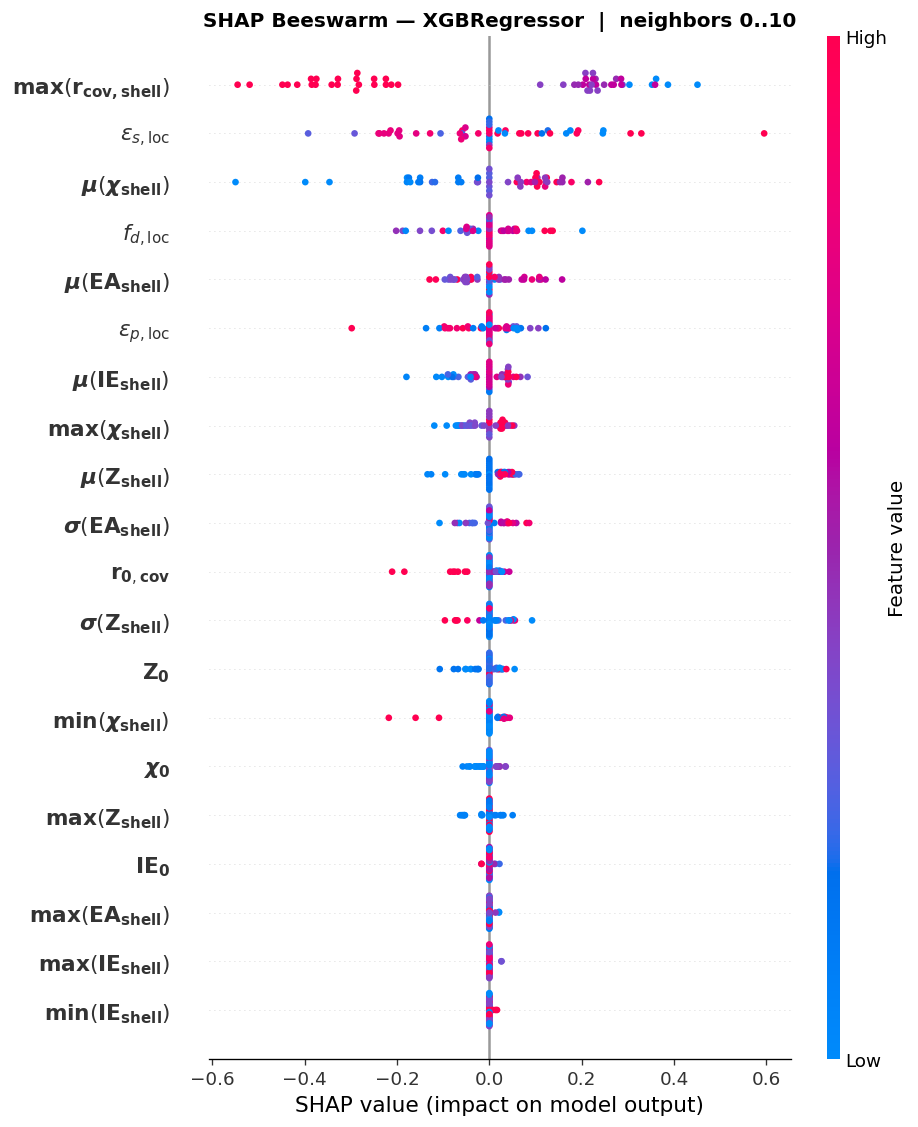

Saved: /home/parastoo/Desktop/ML_project/analysis/ML_project/paper_files/new_ML_5CV/N2_f20_outlierz3_n21_shaptest_beeswarm.pdf


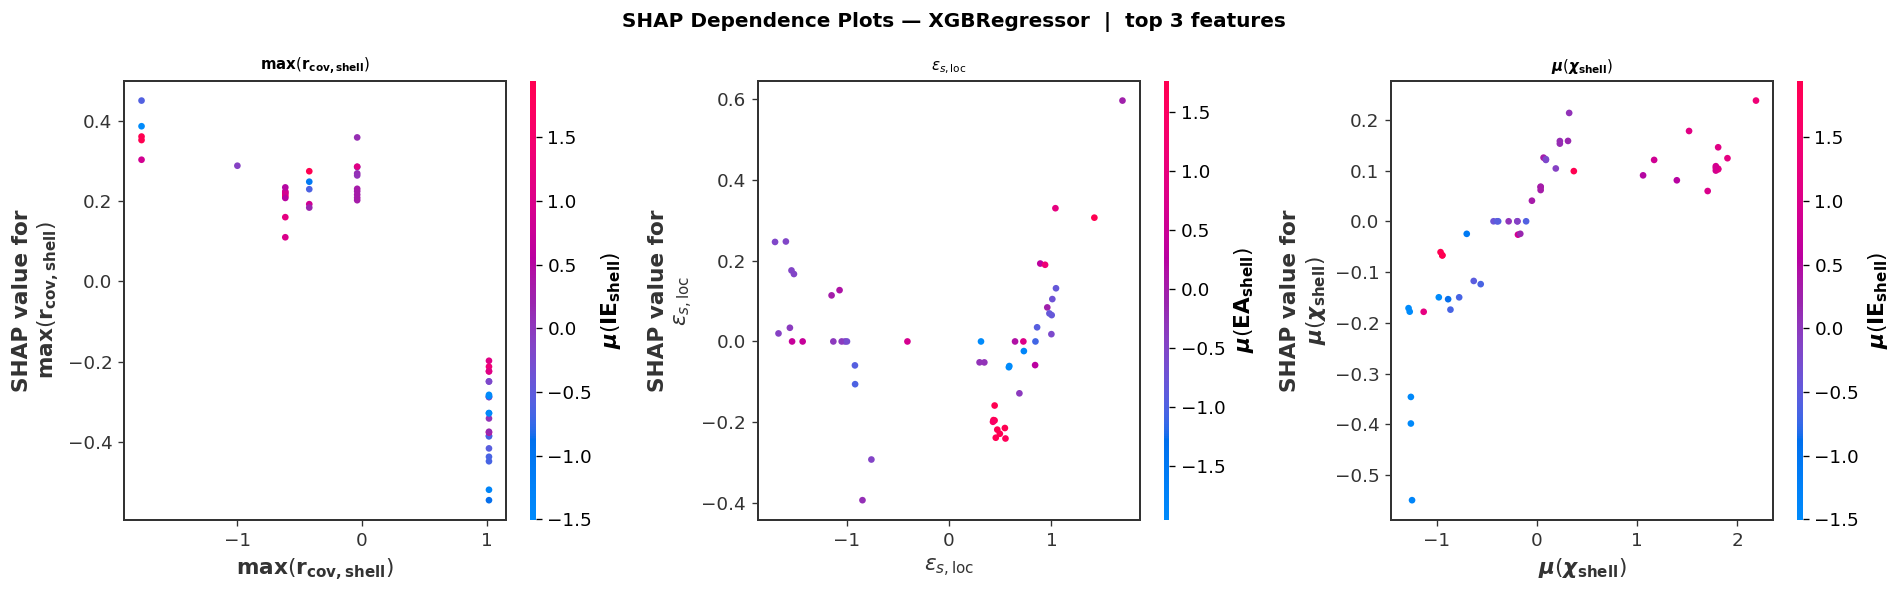

Saved: /home/parastoo/Desktop/ML_project/analysis/ML_project/paper_files/new_ML_5CV/N2_f20_outlierz3_n21_shaptest_dependence.pdf
SHAP Train
SHAP Train
SHAP Train
SHAP Train
SHAP Train
Computing SHAP on training set: 200 samples, 20 features ...


  0%|          | 0/200 [00:00<?, ?it/s]

SHAP values shape: (200, 20)


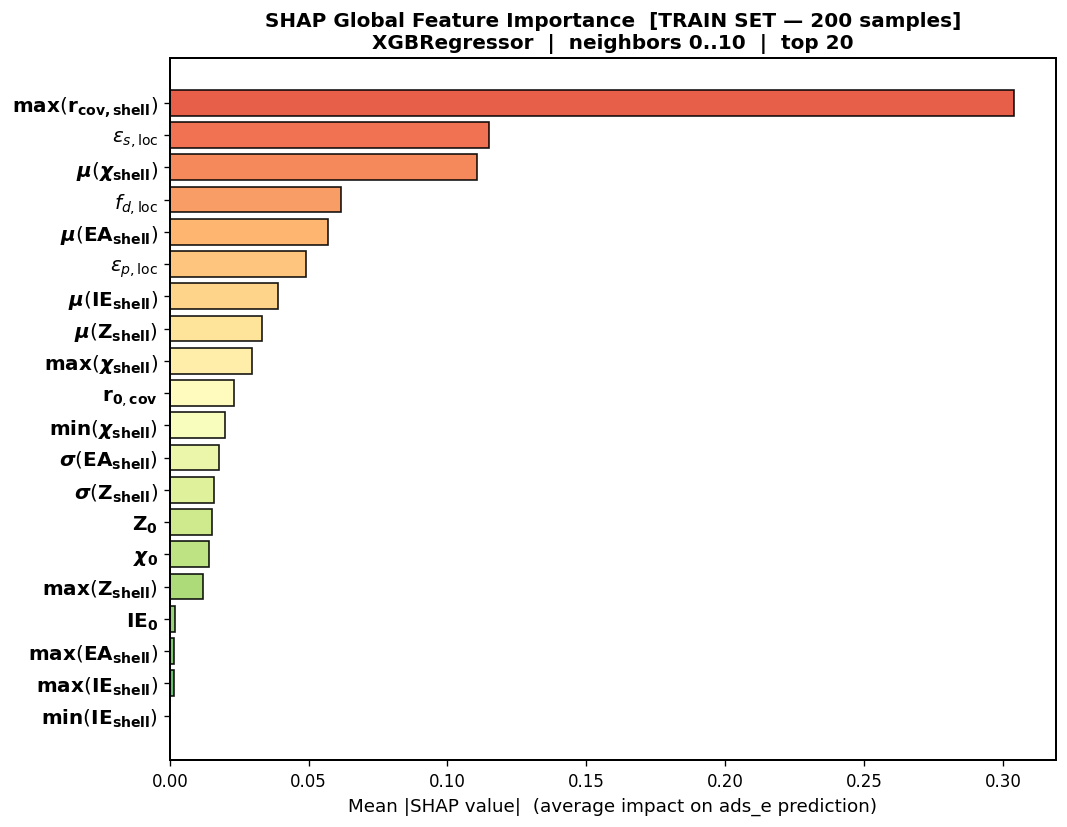

Saved: /home/parastoo/Desktop/ML_project/analysis/ML_project/paper_files/new_ML_5CV/N2_f20_outlierz3_n21_shaptrain_bar.pdf


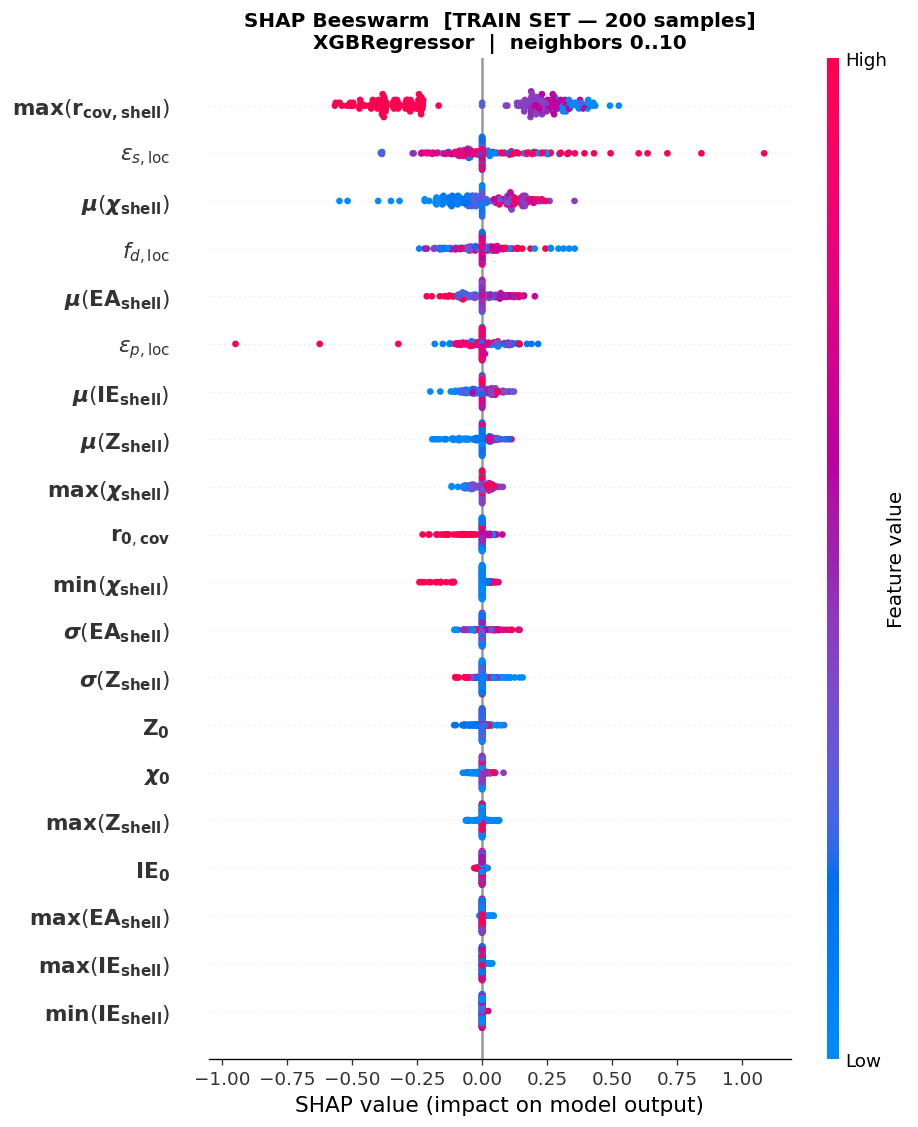

Saved: /home/parastoo/Desktop/ML_project/analysis/ML_project/paper_files/new_ML_5CV/N2_f20_outlierz3_n21_shaptrain_beeswarm.pdf


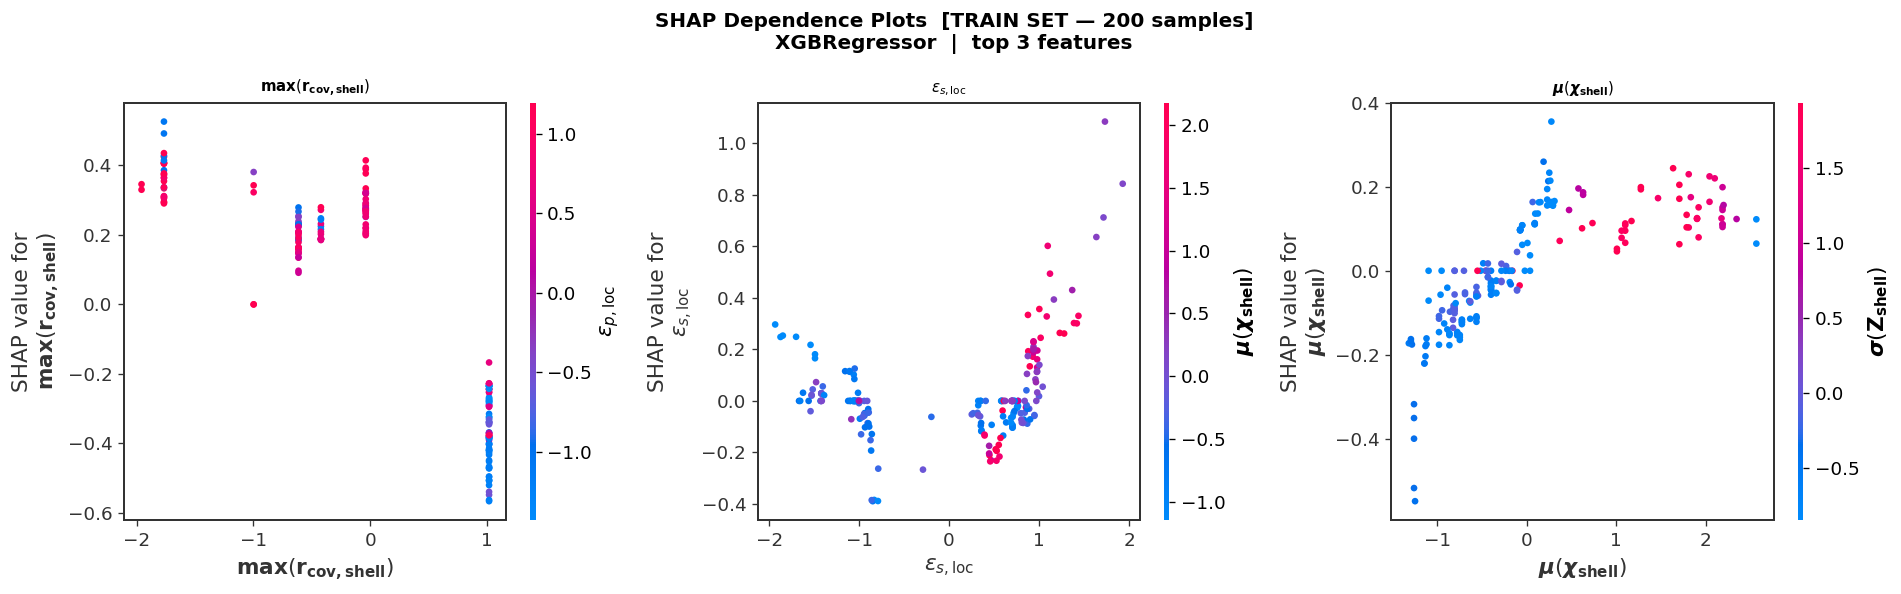

Saved: /home/parastoo/Desktop/ML_project/analysis/ML_project/paper_files/new_ML_5CV/N2_f20_outlierz3_n21_shaptrain_dependence.pdf

✅  Train-set SHAP plots done  (200 samples used).


shell_cov_rad_max                   0.303947
n0_n10_dos_selected_sband_center    0.114879
shell_electroneg_mean               0.110756
n0_n10_dos_selected_dband_sum       0.061580
shell_elect_affinity_mean           0.057107
n0_n10_dos_selected_pband_center    0.049030
shell_ion_e_mean                    0.039091
shell_atomic_number_mean            0.033309
shell_electroneg_max                0.029684
n0_cov_rad                          0.023146
shell_electroneg_min                0.019951
shell_elect_affinity_std            0.017543
shell_atomic_number_std             0.016023
n0_atomic_number                    0.015020
n0_electroneg                       0.014135
shell_atomic_number_max             0.011927
n0_ion_e                            0.001983
shell_elect_affinity_max            0.001688
shell_ion_e_max                     0.001601
shell_ion_e_min                     0.000246
dtype: float64

In [19]:
outlier_type = 'z3'
mol = 'N2'
n = 21 #number of neighbors
features = 20 #number of selected features 

import os
path = save_path + f'results_{mol}_{outlier_type}_f{features}_n{n}.pkl'
print(f"File size: {os.path.getsize(path)} bytes")
# Save after running
#with open(save_path + f'results_{mol}_{outlier_type}_f{features}_n{n}.pkl', 'wb') as f:
#    pickle.dump(results, f)

# Reload later — model, SHAP, everything intact 
with open(save_path + f'results_{mol}_{outlier_type}_f{features}_n{n}.pkl', 'rb') as f:
    results = pickle.load(f)

# ── Plot with your own filenames ──────────────────────────────────────────────
plot_cv_sweep(results,    filename= save_path + f'{mol}_f{features}_outlier{outlier_type}_n{n}_cv_sweep.pdf')
plot_train_vs_cv(results, filename= save_path + f'{mol}_f{features}_outlier{outlier_type}_n{n}_train_vs_cv.pdf')
plot_heatmap(results,     filename= save_path + f'{mol}_f{features}_outlier{outlier_type}_n{n}_heatmap.pdf')
plot_parity(results,      filename= save_path + f'{mol}_f{features}_outlier{outlier_type}_n{n}_parity.pdf')
plot_shap(results,
          filename_bar        = save_path + f'{mol}_f{features}_outlier{outlier_type}_n{n}_shaptest_bar.pdf',
          filename_beeswarm   = save_path + f'{mol}_f{features}_outlier{outlier_type}_n{n}_shaptest_beeswarm.pdf',
          filename_dependence = save_path + f'{mol}_f{features}_outlier{outlier_type}_n{n}_shaptest_dependence.pdf')


print('SHAP Train')
print('SHAP Train')
print('SHAP Train')
print('SHAP Train')
print('SHAP Train')


# After running run_pipeline()
plot_shap_train(
    results             = results,
    filename_bar        = save_path + f'{mol}_f{features}_outlier{outlier_type}_n{n}_shaptrain_bar.pdf',
    filename_beeswarm   = save_path + f'{mol}_f{features}_outlier{outlier_type}_n{n}_shaptrain_beeswarm.pdf',
    filename_dependence = save_path + f'{mol}_f{features}_outlier{outlier_type}_n{n}_shaptrain_dependence.pdf',
    n_top               = 20,
    n_background        = 50,   # background samples for KernelExplainer
    n_top_feat_plot = 3
)


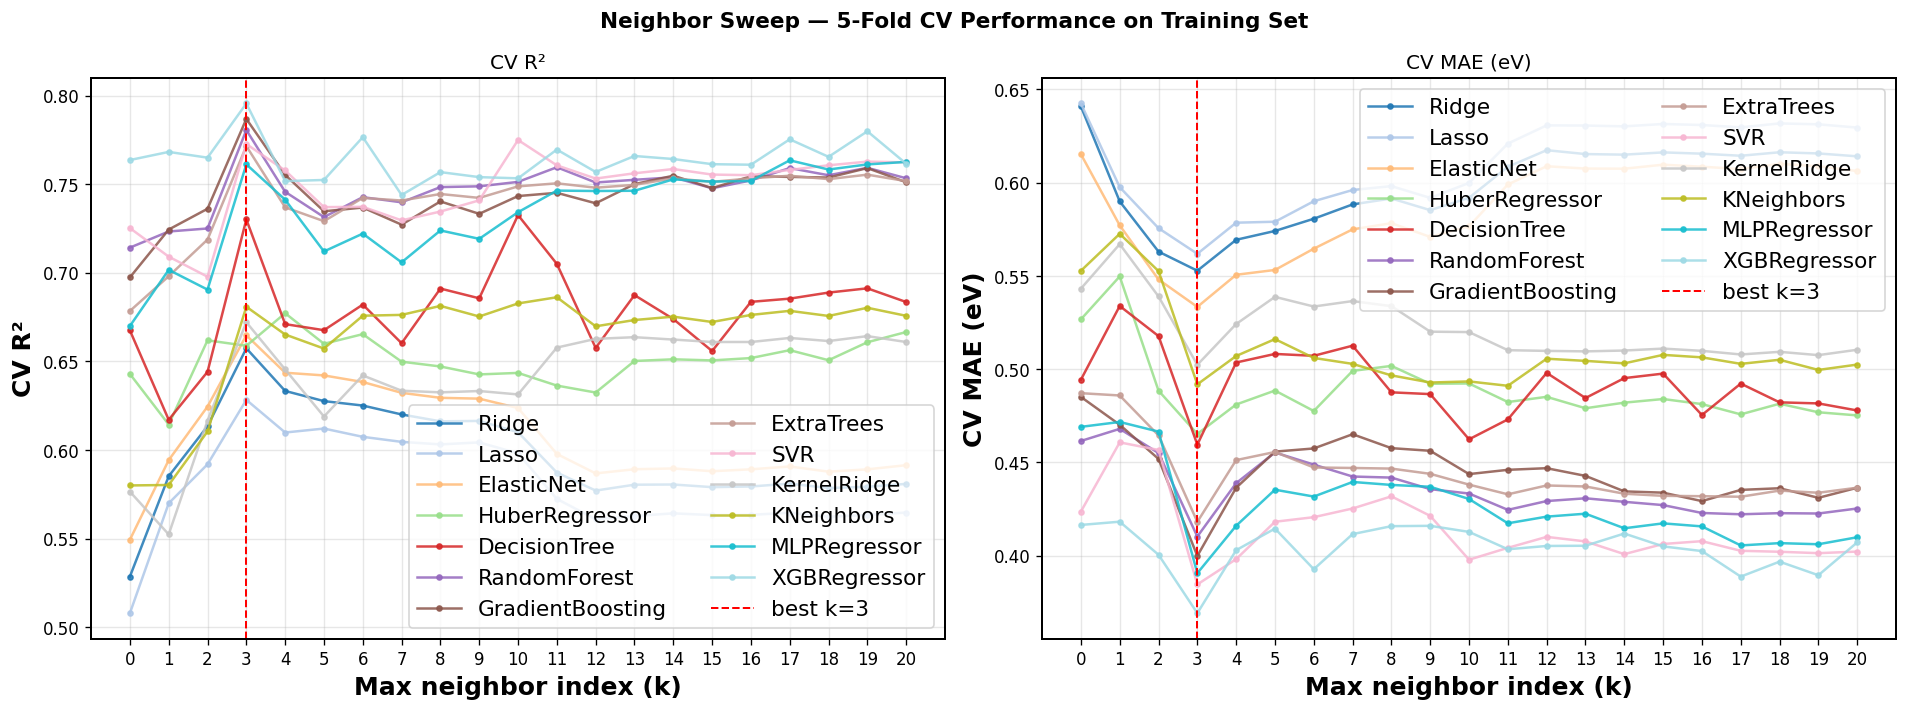

Saved: /home/parastoo/Desktop/ML_project/analysis/ML_project/paper_files/new_ML_5CV/N2H_f20_outlierz3_n21_cv_sweep.pdf


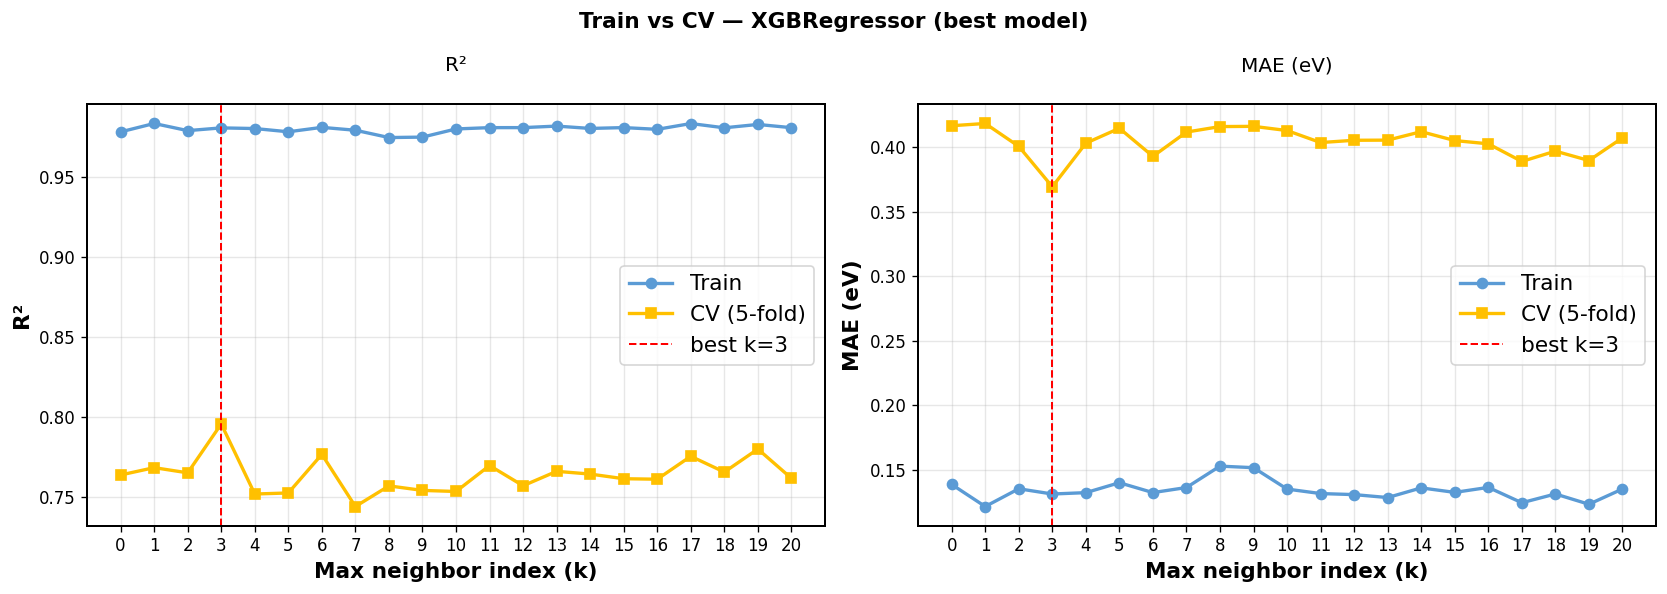

Saved: /home/parastoo/Desktop/ML_project/analysis/ML_project/paper_files/new_ML_5CV/N2H_f20_outlierz3_n21_train_vs_cv.pdf


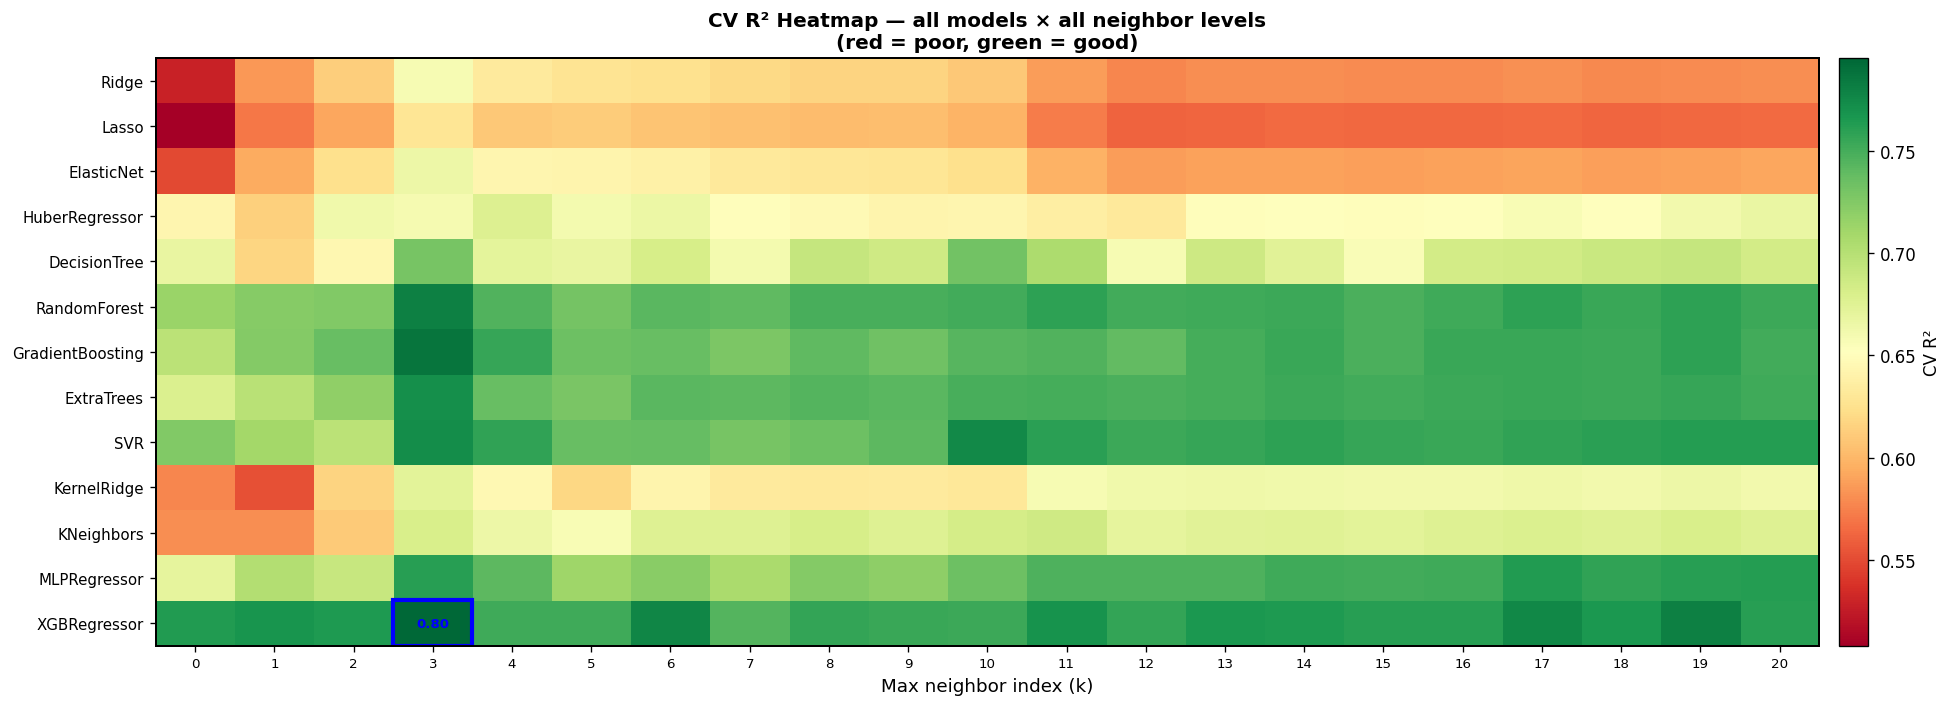

Saved: /home/parastoo/Desktop/ML_project/analysis/ML_project/paper_files/new_ML_5CV/N2H_f20_outlierz3_n21_heatmap.pdf


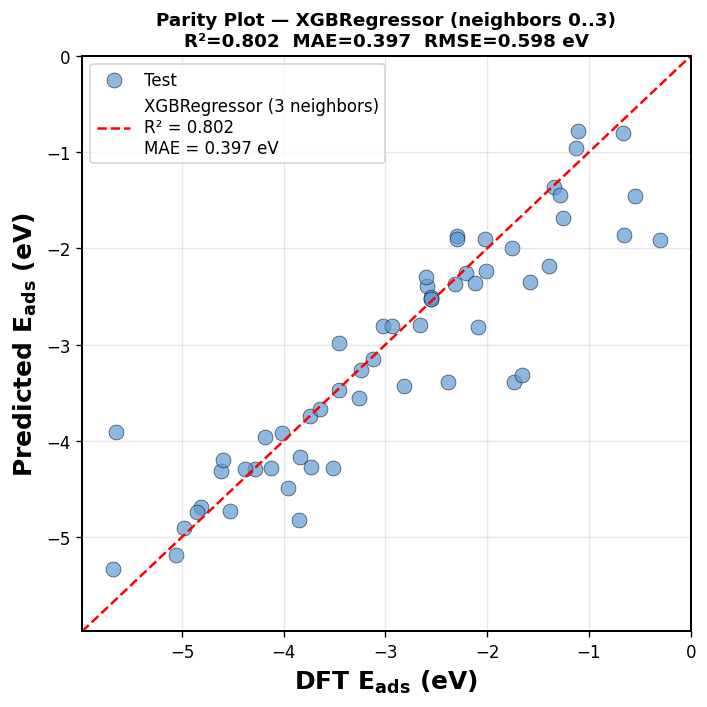

Saved: /home/parastoo/Desktop/ML_project/analysis/ML_project/paper_files/new_ML_5CV/N2H_f20_outlierz3_n21_parity.pdf


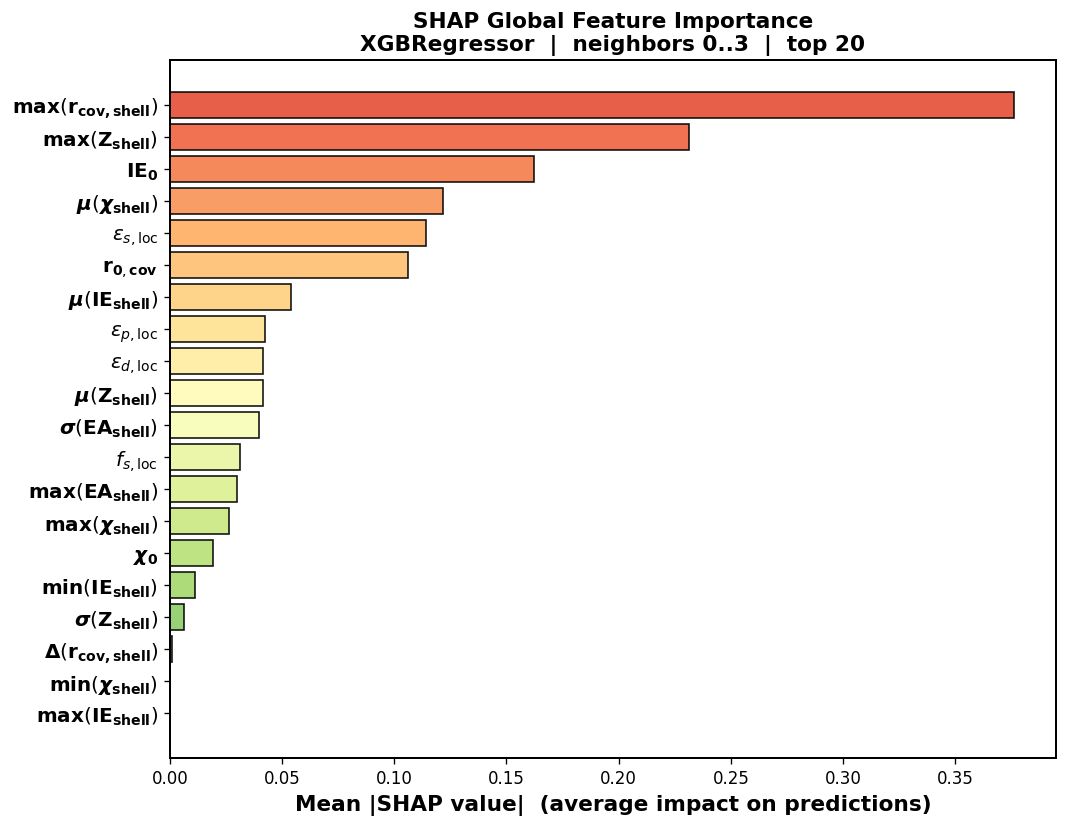

Saved: /home/parastoo/Desktop/ML_project/analysis/ML_project/paper_files/new_ML_5CV/N2H_f20_outlierz3_n21_shaptest_bar.pdf


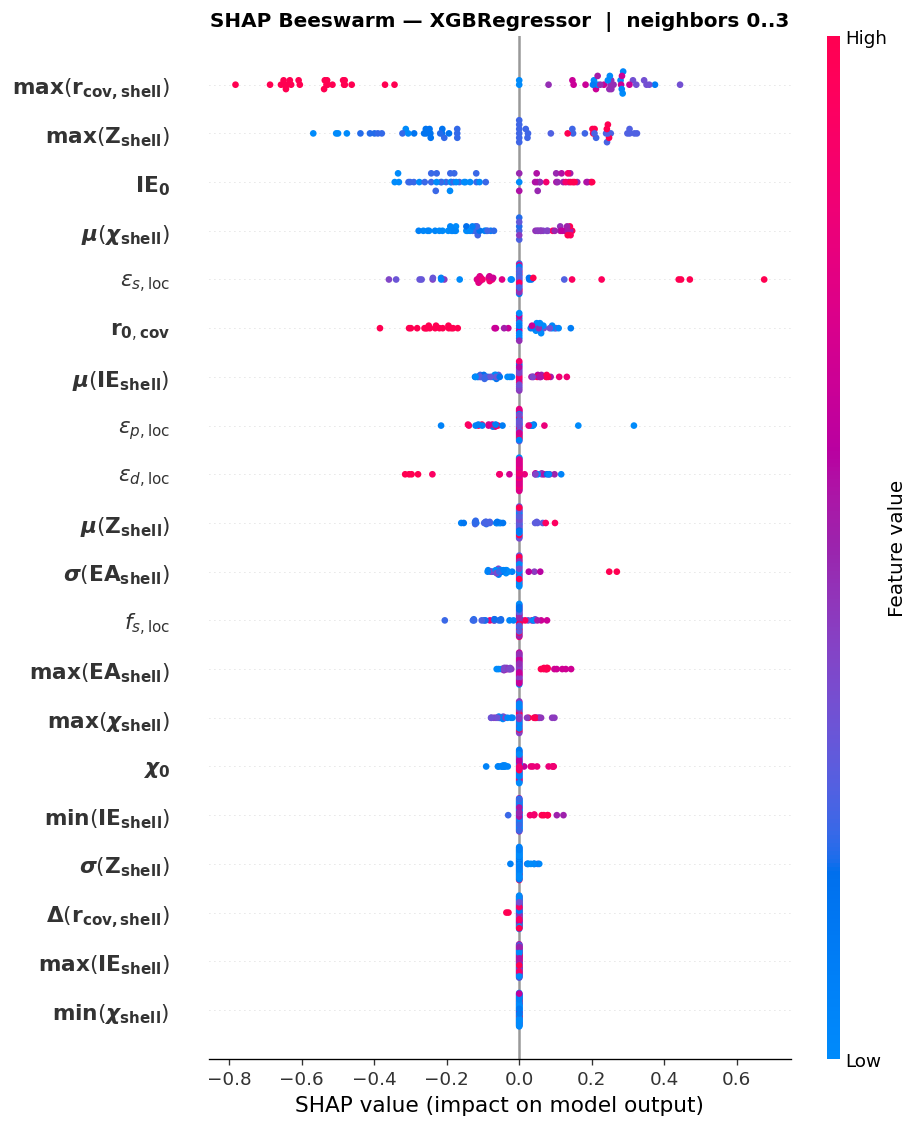

Saved: /home/parastoo/Desktop/ML_project/analysis/ML_project/paper_files/new_ML_5CV/N2H_f20_outlierz3_n21_shaptest_beeswarm.pdf


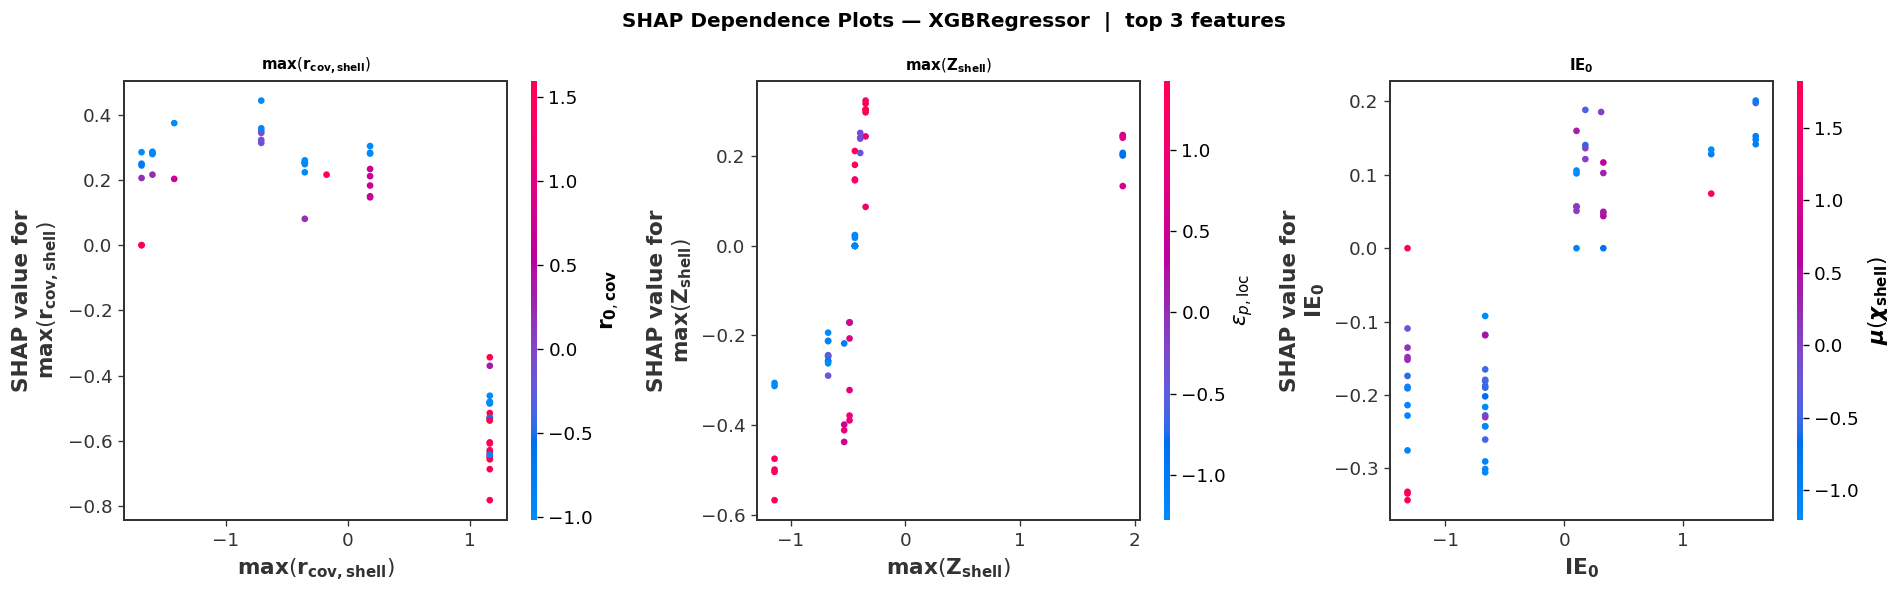

Saved: /home/parastoo/Desktop/ML_project/analysis/ML_project/paper_files/new_ML_5CV/N2H_f20_outlierz3_n21_shaptest_dependence.pdf
SHAP Train
SHAP Train
SHAP Train
SHAP Train
SHAP Train
Computing SHAP on training set: 230 samples, 20 features ...


  0%|          | 0/230 [00:00<?, ?it/s]

SHAP values shape: (230, 20)


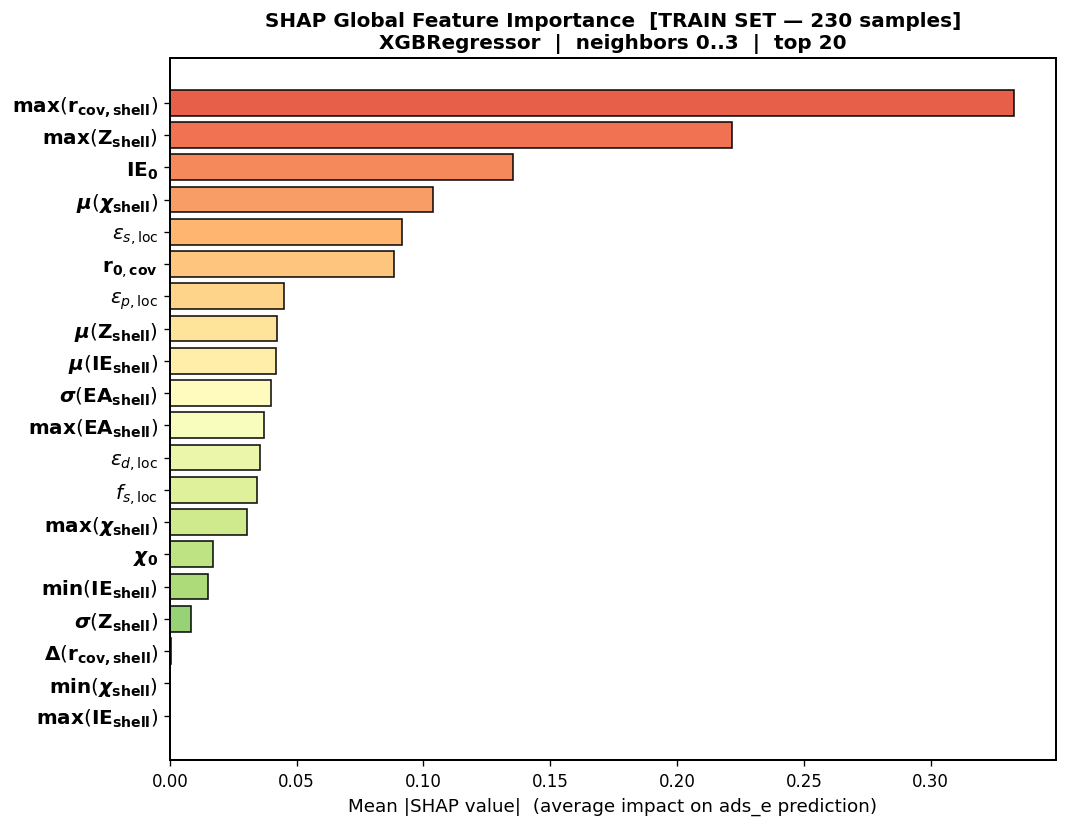

Saved: /home/parastoo/Desktop/ML_project/analysis/ML_project/paper_files/new_ML_5CV/N2H_f20_outlierz3_n21_shaptrain_bar.pdf


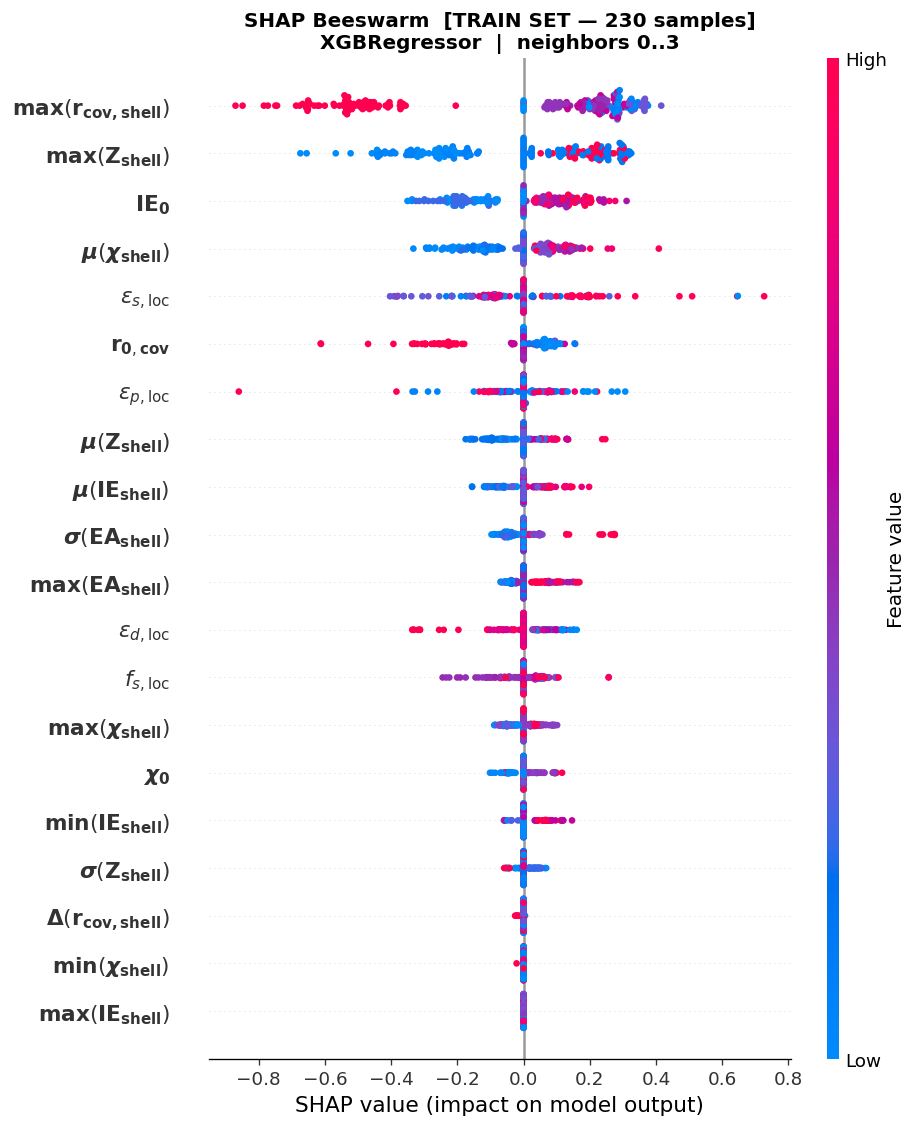

Saved: /home/parastoo/Desktop/ML_project/analysis/ML_project/paper_files/new_ML_5CV/N2H_f20_outlierz3_n21_shaptrain_beeswarm.pdf


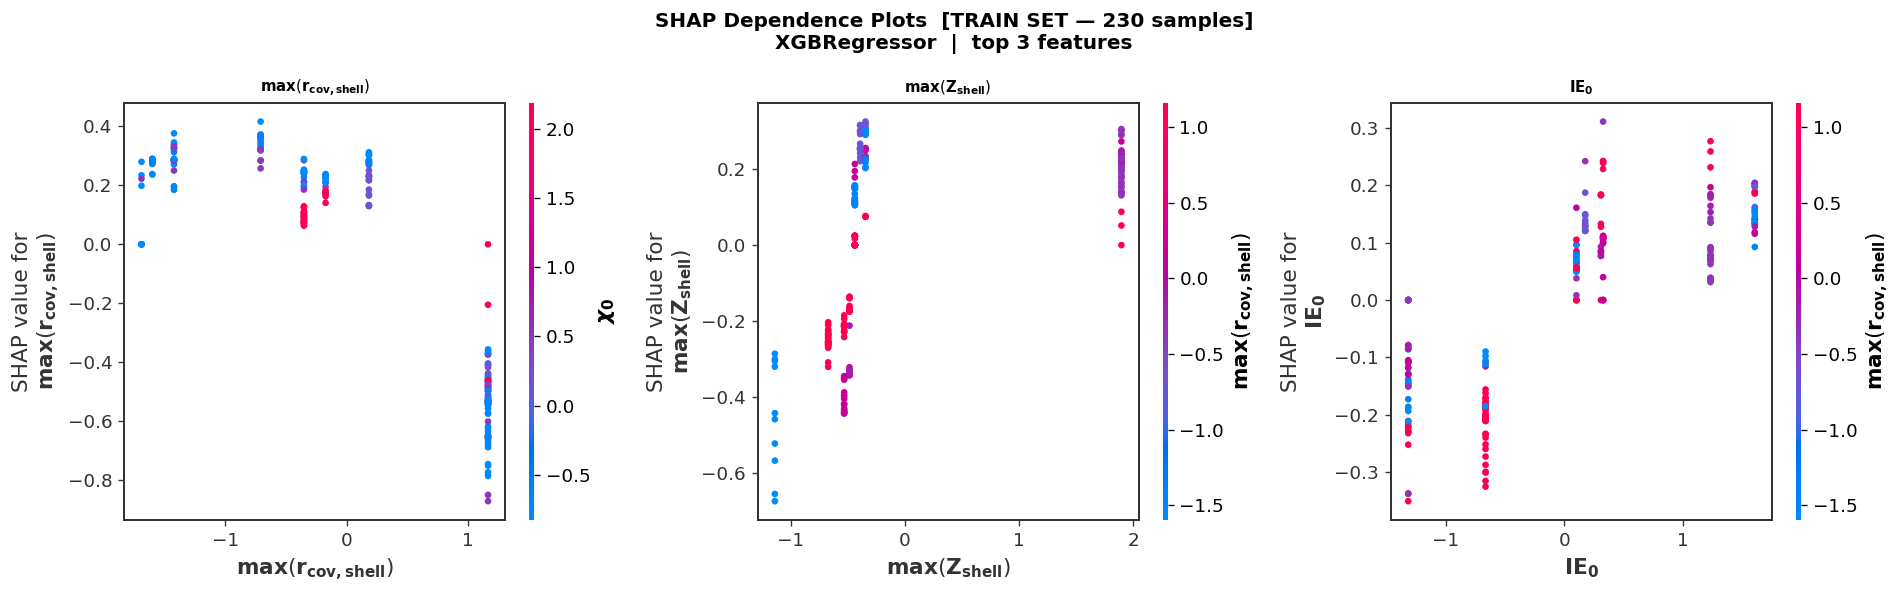

Saved: /home/parastoo/Desktop/ML_project/analysis/ML_project/paper_files/new_ML_5CV/N2H_f20_outlierz3_n21_shaptrain_dependence.pdf

✅  Train-set SHAP plots done  (230 samples used).


shell_cov_rad_max                  0.332777
shell_atomic_number_max            0.221497
n0_ion_e                           0.135369
shell_electroneg_mean              0.103870
n0_n3_dos_selected_sband_center    0.091568
n0_cov_rad                         0.088359
n0_n3_dos_selected_pband_center    0.045017
shell_atomic_number_mean           0.042082
shell_ion_e_mean                   0.041856
shell_elect_affinity_std           0.039910
shell_elect_affinity_max           0.037142
n0_n3_dos_selected_dband_center    0.035382
n0_n3_dos_selected_sband_sum       0.034290
shell_electroneg_max               0.030527
n0_electroneg                      0.016864
shell_ion_e_min                    0.015187
shell_atomic_number_std            0.008196
shell_cov_rad_range                0.000540
shell_electroneg_min               0.000092
shell_ion_e_max                    0.000000
dtype: float64

In [21]:
outlier_type = 'z3'
mol = 'N2H'
n = 21 #number of neighbors
features = 20 #number of selected features 


# Save after running
#with open(save_path + f'results_{mol}_{outlier_type}_f{features}_n{n}.pkl', 'wb') as f:
    #pickle.dump(results, f)

# Reload later — model, SHAP, everything intact 
with open(save_path + f'results_{mol}_{outlier_type}_f{features}_n{n}.pkl', 'rb') as f:
    results = pickle.load(f)

# ── Plot with your own filenames ──────────────────────────────────────────────
plot_cv_sweep(results,    filename= save_path + f'{mol}_f{features}_outlier{outlier_type}_n{n}_cv_sweep.pdf')
plot_train_vs_cv(results, filename= save_path + f'{mol}_f{features}_outlier{outlier_type}_n{n}_train_vs_cv.pdf')
plot_heatmap(results,     filename= save_path + f'{mol}_f{features}_outlier{outlier_type}_n{n}_heatmap.pdf')
plot_parity(results,      filename= save_path + f'{mol}_f{features}_outlier{outlier_type}_n{n}_parity.pdf')
plot_shap(results,
          filename_bar        = save_path + f'{mol}_f{features}_outlier{outlier_type}_n{n}_shaptest_bar.pdf',
          filename_beeswarm   = save_path + f'{mol}_f{features}_outlier{outlier_type}_n{n}_shaptest_beeswarm.pdf',
          filename_dependence = save_path + f'{mol}_f{features}_outlier{outlier_type}_n{n}_shaptest_dependence.pdf')


print('SHAP Train')
print('SHAP Train')
print('SHAP Train')
print('SHAP Train')
print('SHAP Train')


# After running run_pipeline()
plot_shap_train(
    results             = results,
    filename_bar        = save_path + f'{mol}_f{features}_outlier{outlier_type}_n{n}_shaptrain_bar.pdf',
    filename_beeswarm   = save_path + f'{mol}_f{features}_outlier{outlier_type}_n{n}_shaptrain_beeswarm.pdf',
    filename_dependence = save_path + f'{mol}_f{features}_outlier{outlier_type}_n{n}_shaptrain_dependence.pdf',
    n_top               = 20,
    n_background        = 50,   # background samples for KernelExplainer
    n_top_feat_plot = 3
)


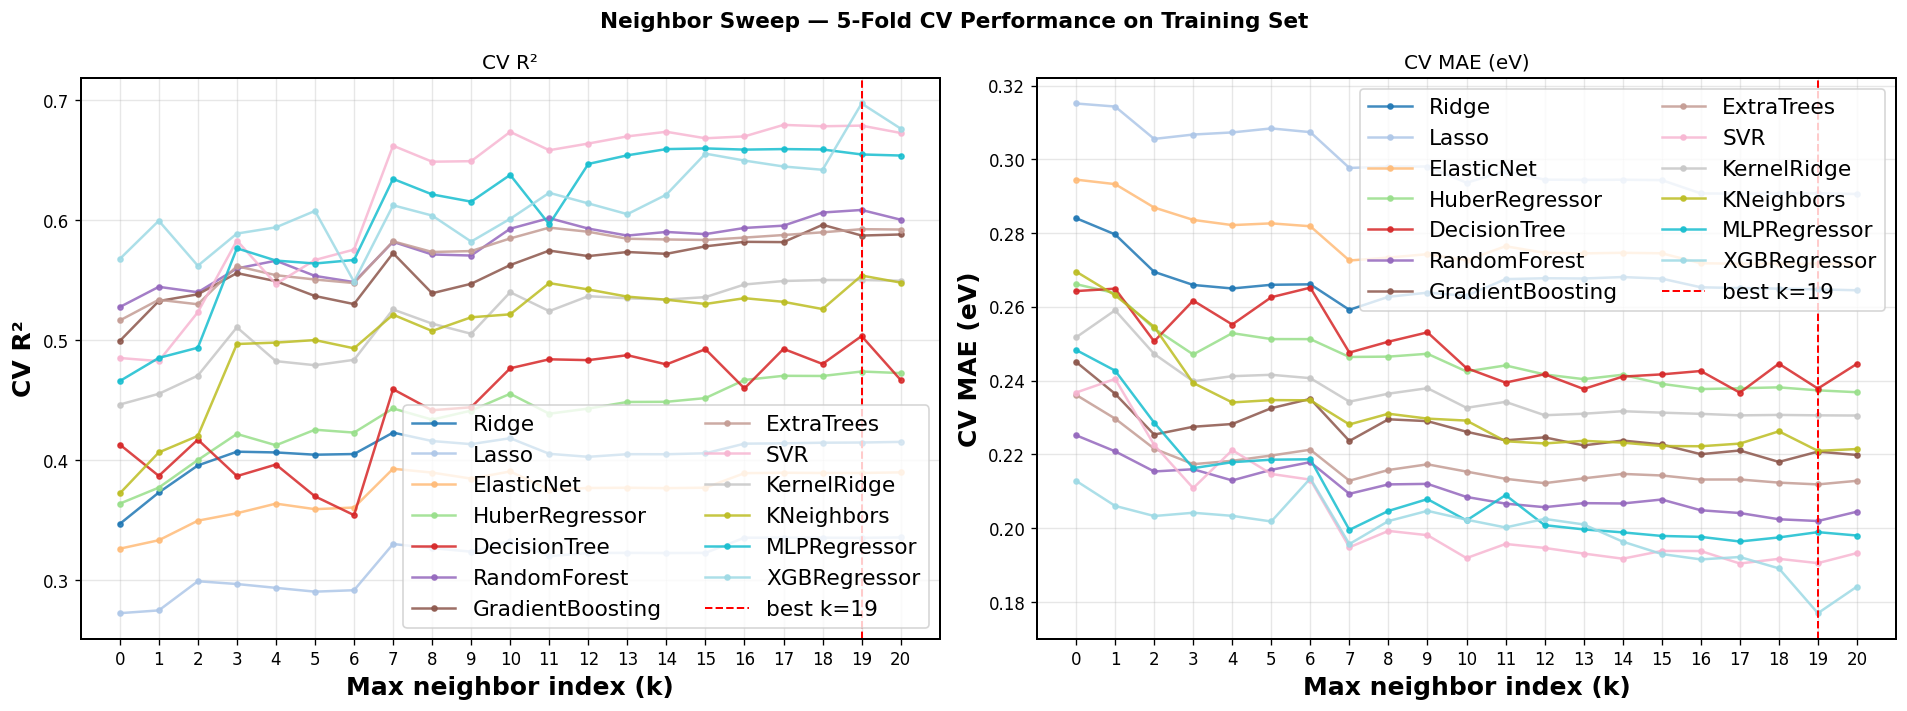

Saved: /home/parastoo/Desktop/ML_project/analysis/ML_project/paper_files/new_ML_5CV/NH3_f20_outlierz3_n21_cv_sweep.pdf


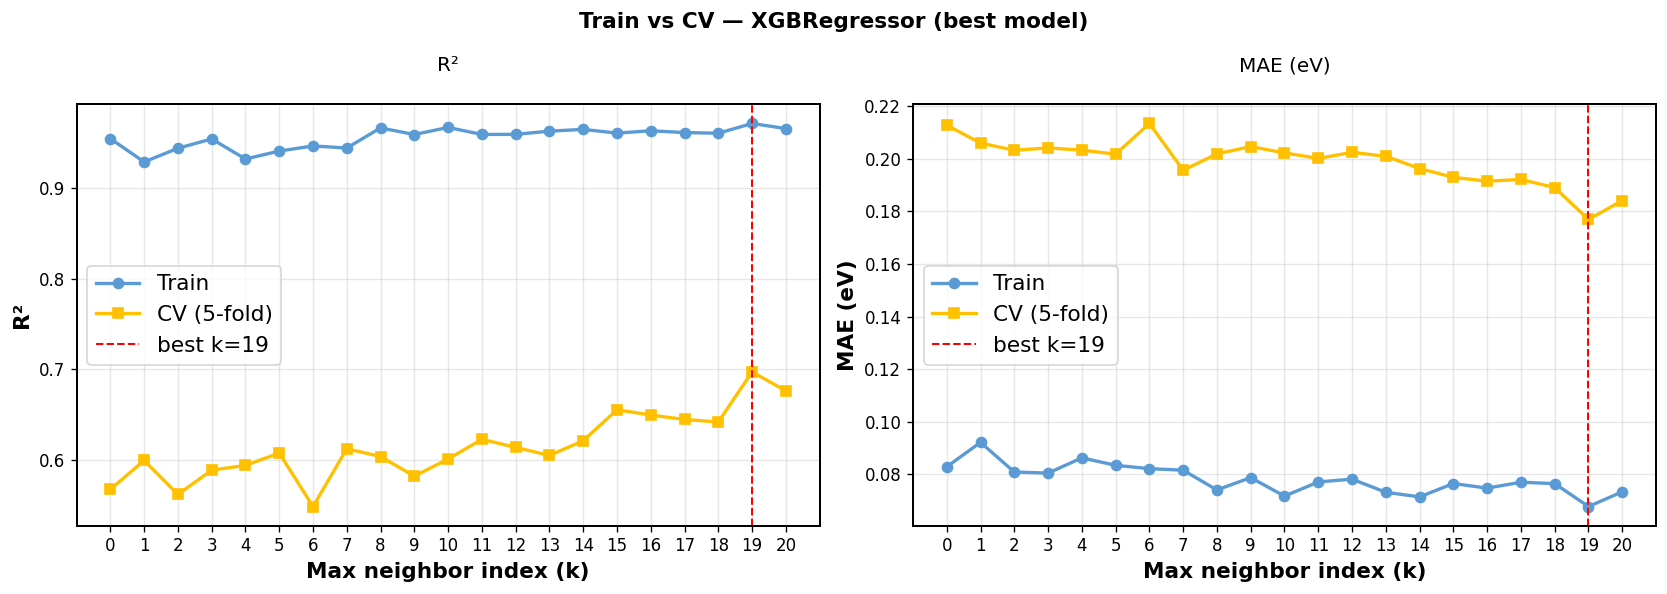

Saved: /home/parastoo/Desktop/ML_project/analysis/ML_project/paper_files/new_ML_5CV/NH3_f20_outlierz3_n21_train_vs_cv.pdf


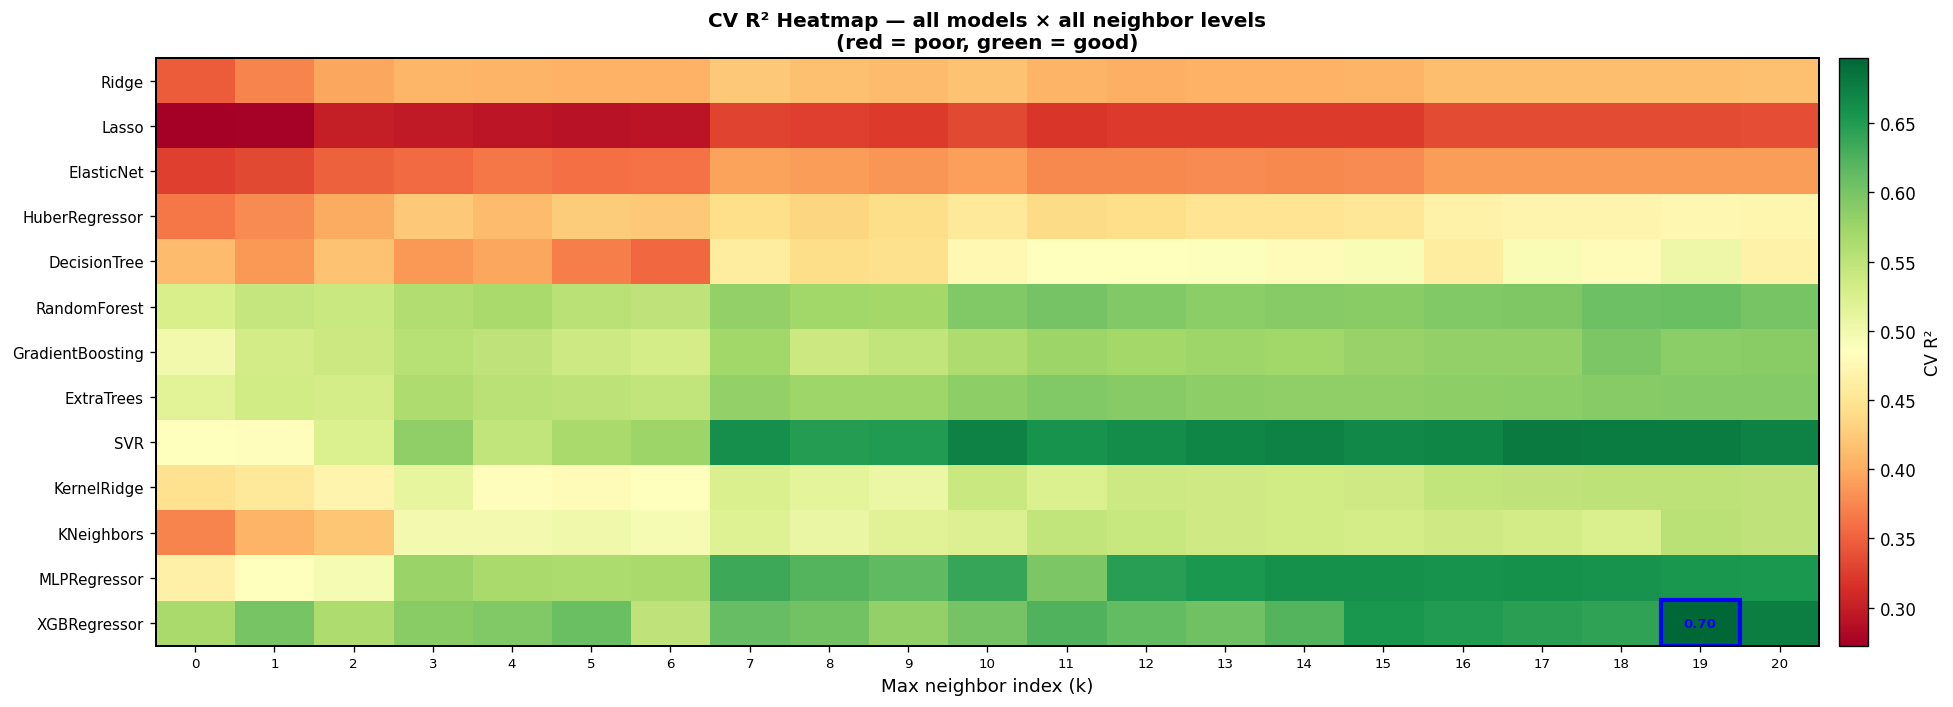

Saved: /home/parastoo/Desktop/ML_project/analysis/ML_project/paper_files/new_ML_5CV/NH3_f20_outlierz3_n21_heatmap.pdf


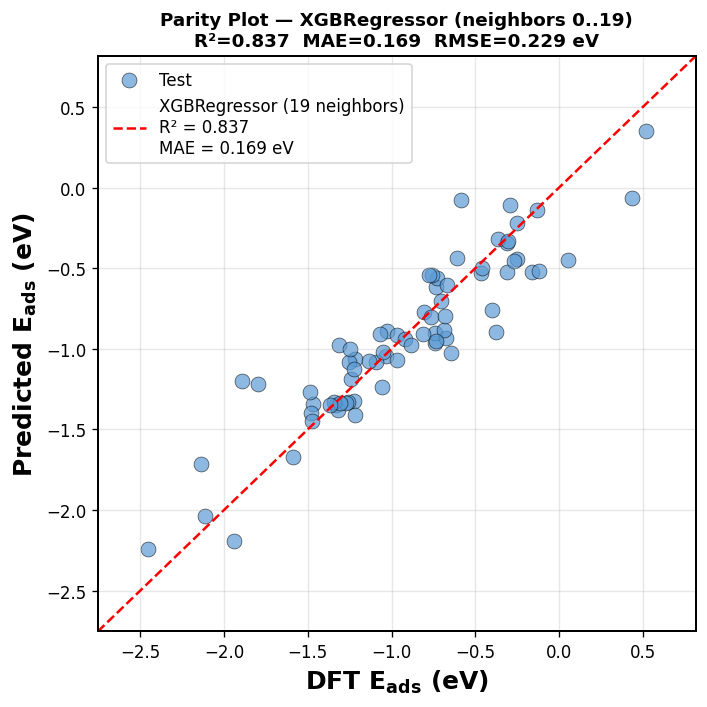

Saved: /home/parastoo/Desktop/ML_project/analysis/ML_project/paper_files/new_ML_5CV/NH3_f20_outlierz3_n21_parity.pdf


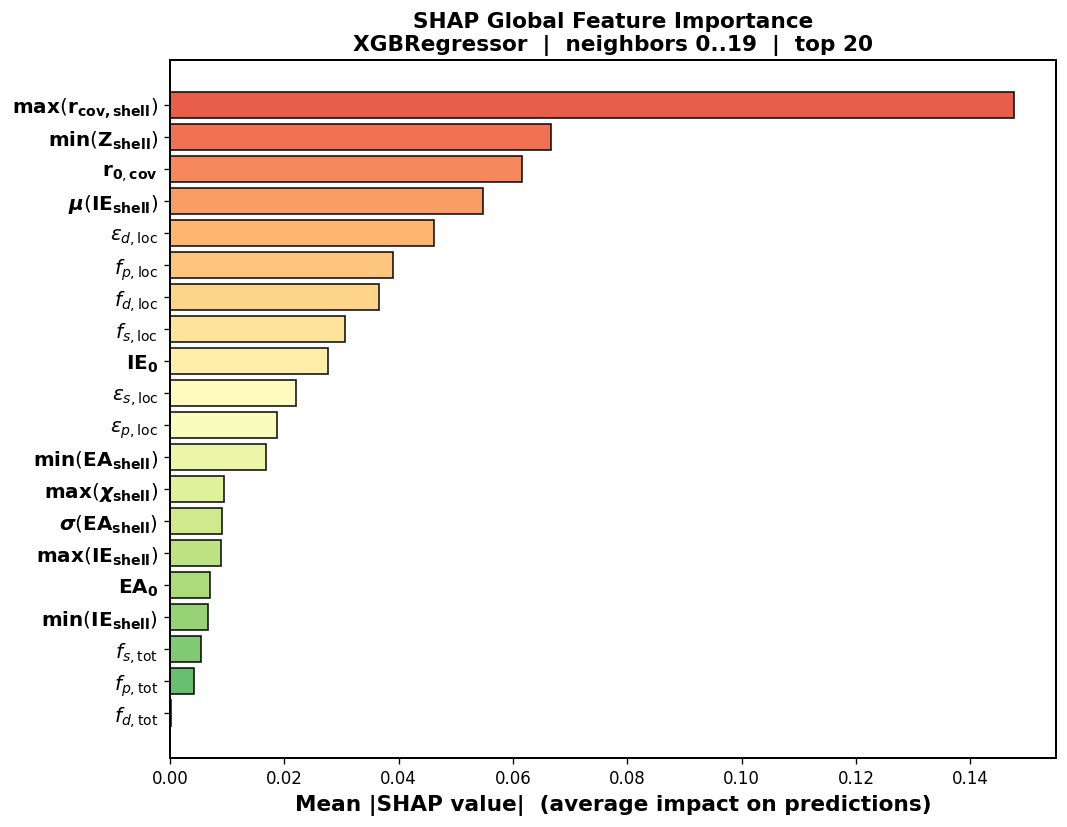

Saved: /home/parastoo/Desktop/ML_project/analysis/ML_project/paper_files/new_ML_5CV/NH3_f20_outlierz3_n21_shaptest_bar.pdf


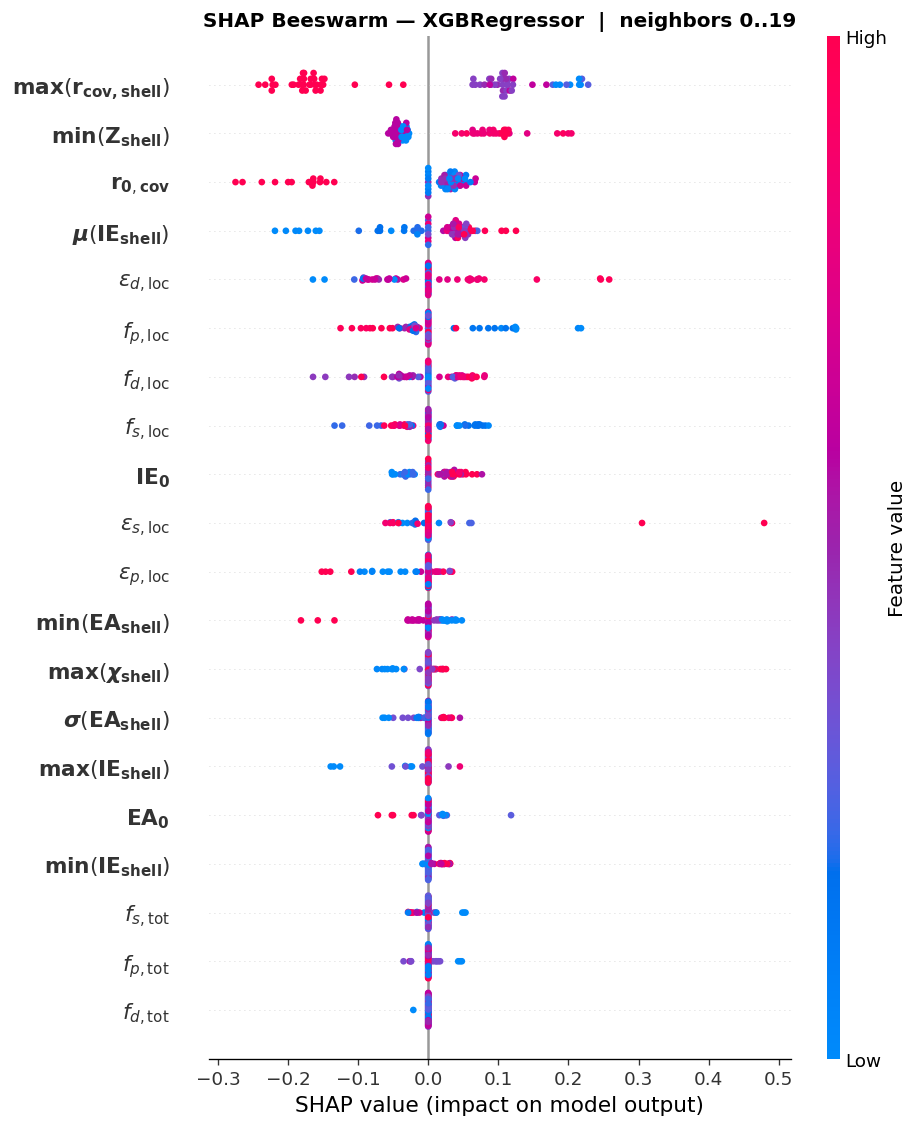

Saved: /home/parastoo/Desktop/ML_project/analysis/ML_project/paper_files/new_ML_5CV/NH3_f20_outlierz3_n21_shaptest_beeswarm.pdf


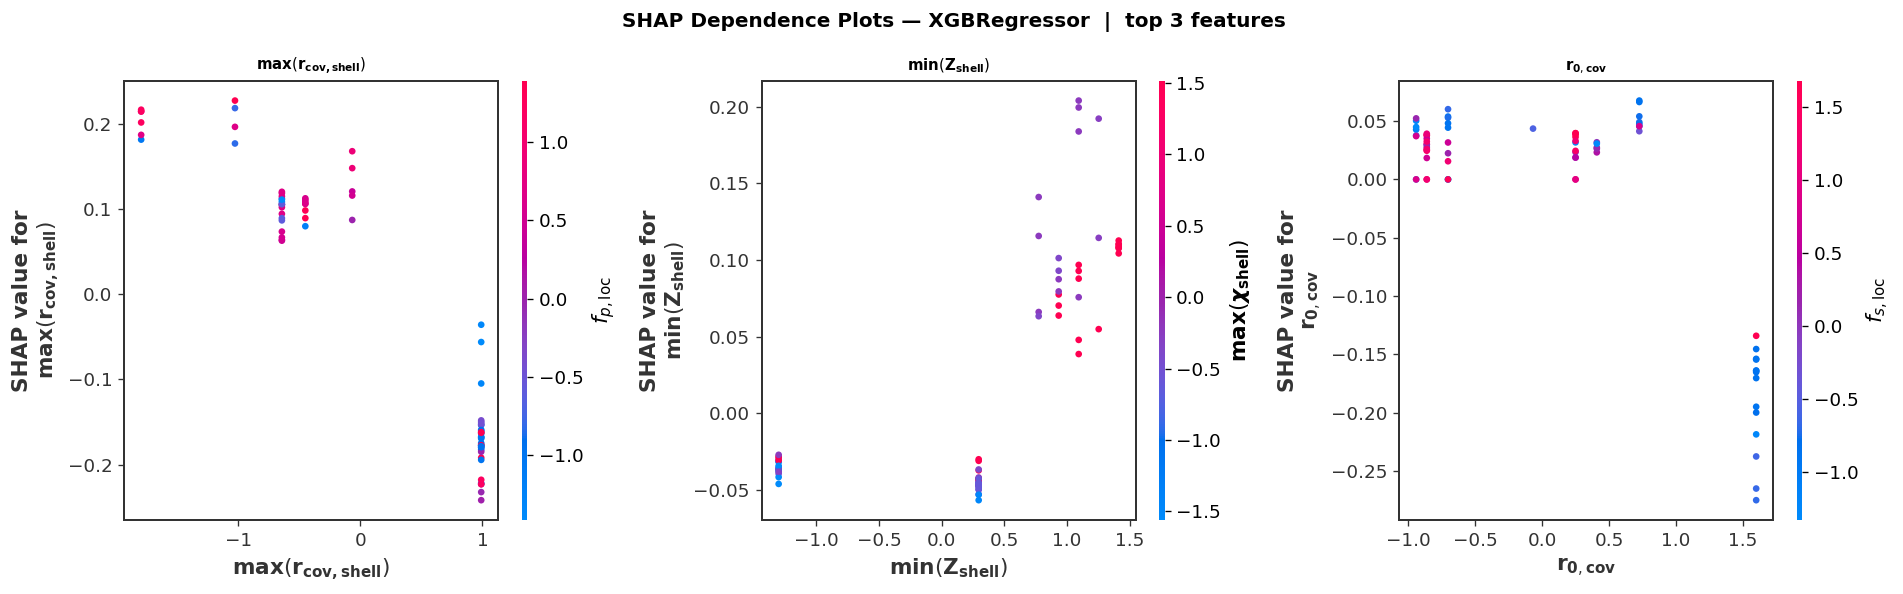

Saved: /home/parastoo/Desktop/ML_project/analysis/ML_project/paper_files/new_ML_5CV/NH3_f20_outlierz3_n21_shaptest_dependence.pdf
SHAP Train
SHAP Train
SHAP Train
SHAP Train
SHAP Train
Computing SHAP on training set: 292 samples, 20 features ...


  0%|          | 0/292 [00:00<?, ?it/s]

SHAP values shape: (292, 20)


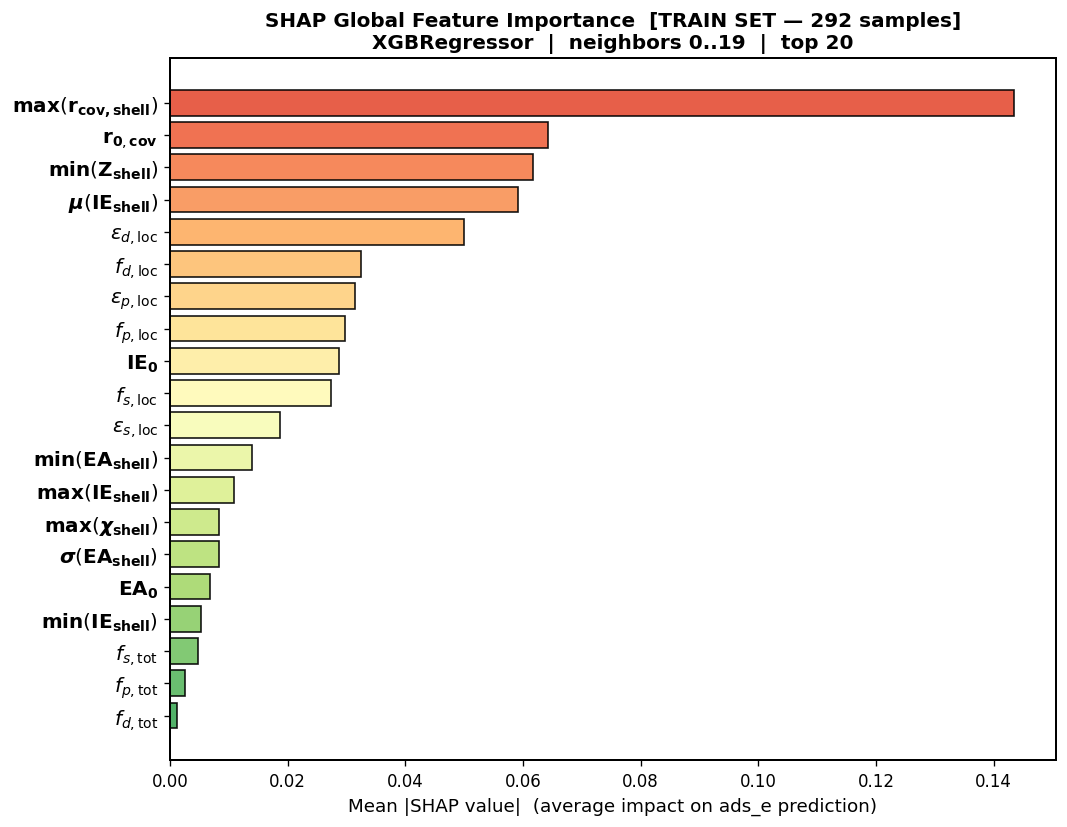

Saved: /home/parastoo/Desktop/ML_project/analysis/ML_project/paper_files/new_ML_5CV/NH3_f20_outlierz3_n21_shaptrain_bar.pdf


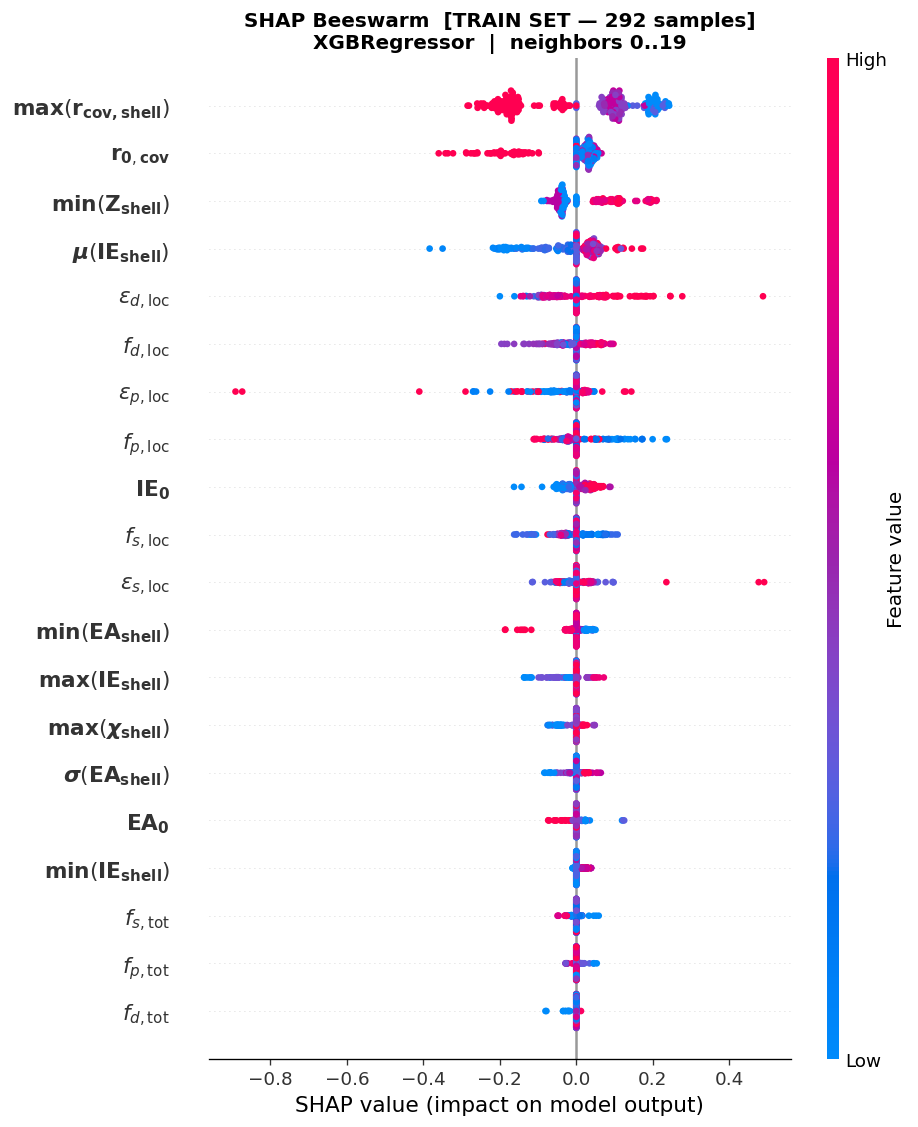

Saved: /home/parastoo/Desktop/ML_project/analysis/ML_project/paper_files/new_ML_5CV/NH3_f20_outlierz3_n21_shaptrain_beeswarm.pdf


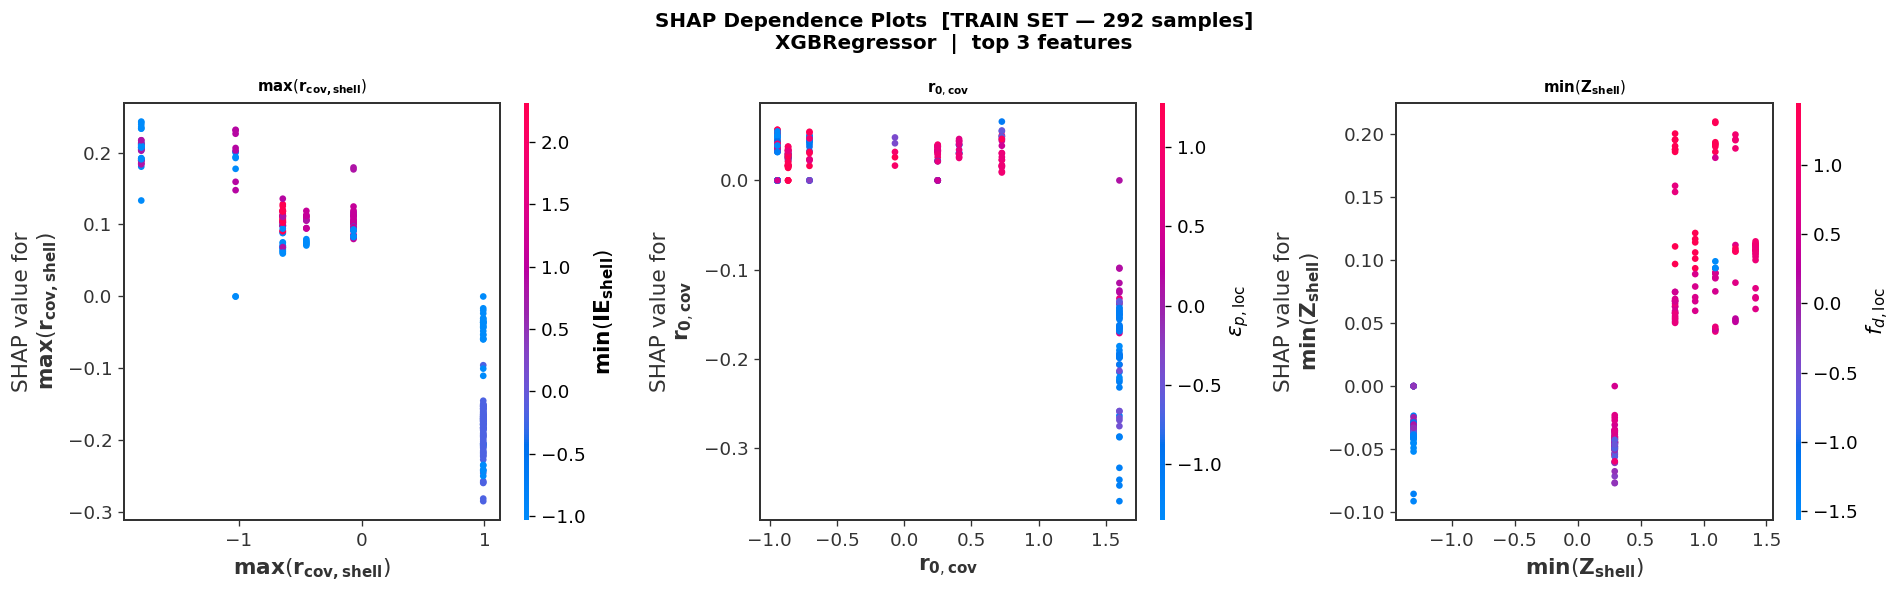

Saved: /home/parastoo/Desktop/ML_project/analysis/ML_project/paper_files/new_ML_5CV/NH3_f20_outlierz3_n21_shaptrain_dependence.pdf

✅  Train-set SHAP plots done  (292 samples used).


shell_cov_rad_max                   0.143422
n0_cov_rad                          0.064267
shell_atomic_number_min             0.061663
shell_ion_e_mean                    0.059115
n0_n19_dos_selected_dband_center    0.050002
n0_n19_dos_selected_dband_sum       0.032424
n0_n19_dos_selected_pband_center    0.031483
n0_n19_dos_selected_pband_sum       0.029796
n0_ion_e                            0.028719
n0_n19_dos_selected_sband_sum       0.027319
n0_n19_dos_selected_sband_center    0.018702
shell_elect_affinity_min            0.013953
shell_ion_e_max                     0.010864
shell_electroneg_max                0.008409
shell_elect_affinity_std            0.008294
n0_elect_affinity                   0.006879
shell_ion_e_min                     0.005331
n0_n19_dos_total_sband_sum          0.004771
n0_n19_dos_total_pband_sum          0.002638
n0_n19_dos_total_dband_sum          0.001299
dtype: float64

In [23]:
outlier_type = 'z3'
mol = 'NH3'
n = 21 #number of neighbors
features = 20 #number of selected features 


# Save after running
#with open(save_path + f'results_{mol}_{outlier_type}_f{features}_n{n}.pkl', 'wb') as f:
#    pickle.dump(results, f)

# Reload later — model, SHAP, everything intact 
with open(save_path + f'results_{mol}_{outlier_type}_f{features}_n{n}.pkl', 'rb') as f:
    results = pickle.load(f)

# ── Plot with your own filenames ──────────────────────────────────────────────
plot_cv_sweep(results,    filename= save_path + f'{mol}_f{features}_outlier{outlier_type}_n{n}_cv_sweep.pdf')
plot_train_vs_cv(results, filename= save_path + f'{mol}_f{features}_outlier{outlier_type}_n{n}_train_vs_cv.pdf')
plot_heatmap(results,     filename= save_path + f'{mol}_f{features}_outlier{outlier_type}_n{n}_heatmap.pdf')
plot_parity(results,      filename= save_path + f'{mol}_f{features}_outlier{outlier_type}_n{n}_parity.pdf')
plot_shap(results,
          filename_bar        = save_path + f'{mol}_f{features}_outlier{outlier_type}_n{n}_shaptest_bar.pdf',
          filename_beeswarm   = save_path + f'{mol}_f{features}_outlier{outlier_type}_n{n}_shaptest_beeswarm.pdf',
          filename_dependence = save_path + f'{mol}_f{features}_outlier{outlier_type}_n{n}_shaptest_dependence.pdf')


print('SHAP Train')
print('SHAP Train')
print('SHAP Train')
print('SHAP Train')
print('SHAP Train')


# After running run_pipeline()
plot_shap_train(
    results             = results,
    filename_bar        = save_path + f'{mol}_f{features}_outlier{outlier_type}_n{n}_shaptrain_bar.pdf',
    filename_beeswarm   = save_path + f'{mol}_f{features}_outlier{outlier_type}_n{n}_shaptrain_beeswarm.pdf',
    filename_dependence = save_path + f'{mol}_f{features}_outlier{outlier_type}_n{n}_shaptrain_dependence.pdf',
    n_top               = 20,
    n_background        = 50,   # background samples for KernelExplainer
    n_top_feat_plot = 3
)


In [ ]:
outlier_type = 'z3'
mol = 'N2'
n = 21 #number of neighbors
features = 10 #number of selected features 
results = run_pipeline(
    df_raw            = df_raw_N2,
    outlier_method    = outlier_type,
    n_select_features = features,
    tested_n_neighbors = n,
)

# Save after running
with open(save_path + f'results_{mol}_{outlier_type}_f{features}_n{n}.pkl', 'wb') as f:
    pickle.dump(results, f)

# Reload later — model, SHAP, everything intact 
#with open(save_path + f'results_{mol}_{outlier_type}_k{k}.pkl', 'rb') as f:
    #results = pickle.load(f)

# ── Plot with your own filenames ──────────────────────────────────────────────
plot_cv_sweep(results,    filename= save_path + f'{mol}_f{features}_outlier{outlier_type}_n{n}_cv_sweep.pdf')
plot_train_vs_cv(results, filename= save_path + f'{mol}_f{features}_outlier{outlier_type}_n{n}_train_vs_cv.pdf')
plot_heatmap(results,     filename= save_path + f'{mol}_f{features}_outlier{outlier_type}_n{n}_heatmap.pdf')
plot_parity(results,      filename= save_path + f'{mol}_f{features}_outlier{outlier_type}_n{n}_parity.pdf')
plot_shap(results,
          filename_bar        = save_path + f'{mol}_f{features}_outlier{outlier_type}_n{n}_shaptest_bar.pdf',
          filename_beeswarm   = save_path + f'{mol}_f{features}_outlier{outlier_type}_n{n}_shaptest_beeswarm.pdf',
          filename_dependence = save_path + f'{mol}_f{features}_outlier{outlier_type}_n{n}_shaptest_dependence.pdf')


print('SHAP Train')
print('SHAP Train')
print('SHAP Train')
print('SHAP Train')
print('SHAP Train')


# After running run_pipeline()
plot_shap_train(
    results             = results,
    filename_bar        = save_path + f'{mol}_f{features}_outlier{outlier_type}_n{n}_shaptrain_bar.pdf',
    filename_beeswarm   = save_path + f'{mol}_f{features}_outlier{outlier_type}_n{n}_shaptrain_beeswarm.pdf',
    filename_dependence = save_path + f'{mol}_f{features}_outlier{outlier_type}_n{n}_shaptrain_dependence.pdf',
    n_top               = 10,
    n_background        = 50,   # background samples for KernelExplainer
    n_top_feat_plot = 3
)



Outlier filter 'z3' [-4.10, 3.24] eV: 4 removed → 251 samples remain
Filtered dataset : 251 samples
SelectKBest k    : 10
Train: 200 samples | Test: 51 samples

NEIGHBOR SWEEP  (Train & 5-Fold CV on training set only)

  Neighbors 0..0  |  24 features total  |  SelectKBest k=10
  [Global features]    ['crystal_struct', 'sym_group']
  [n0 individual]      ['n0_atomic_number', 'n0_atomic_mass', 'n0_elect_affinity', 'n0_ion_e', 'n0_atomic_radius', 'n0_cov_rad', 'n0_atom_density', 'n0_distance', 'n0_charge', 'n0_electroneg']
  [Final DOS n0_n0]   ['n0_n0_dos_selected_sband_center', 'n0_n0_dos_selected_sband_sum', 'n0_n0_dos_total_sband_center', 'n0_n0_dos_total_sband_sum', 'n0_n0_dos_selected_pband_center', 'n0_n0_dos_selected_pband_sum', 'n0_n0_dos_total_pband_center', 'n0_n0_dos_total_pband_sum', 'n0_n0_dos_selected_dband_center', 'n0_n0_dos_selected_dband_sum', 'n0_n0_dos_total_dband_center', 'n0_n0_dos_total_dband_sum']

  Model                TrainR²   TrainMAE   TrainRMSE    CV_R²  

In [ ]:
outlier_type = 'z3'
mol = 'N2H'
n = 21 #number of neighbors
features = 10 #number of selected features 
results = run_pipeline(
    df_raw            = df_raw_N2H,
    outlier_method    = outlier_type,
    n_select_features = features,
    tested_n_neighbors = n,
)

# Save after running
with open(save_path + f'results_{mol}_{outlier_type}_f{features}_n{n}.pkl', 'wb') as f:
    pickle.dump(results, f)

# Reload later — model, SHAP, everything intact 
#with open(save_path + f'results_{mol}_{outlier_type}_k{k}.pkl', 'rb') as f:
    #results = pickle.load(f)

# ── Plot with your own filenames ──────────────────────────────────────────────
plot_cv_sweep(results,    filename= save_path + f'{mol}_f{features}_outlier{outlier_type}_n{n}_cv_sweep.pdf')
plot_train_vs_cv(results, filename= save_path + f'{mol}_f{features}_outlier{outlier_type}_n{n}_train_vs_cv.pdf')
plot_heatmap(results,     filename= save_path + f'{mol}_f{features}_outlier{outlier_type}_n{n}_heatmap.pdf')
plot_parity(results,      filename= save_path + f'{mol}_f{features}_outlier{outlier_type}_n{n}_parity.pdf')
plot_shap(results,
          filename_bar        = save_path + f'{mol}_f{features}_outlier{outlier_type}_n{n}_shaptest_bar.pdf',
          filename_beeswarm   = save_path + f'{mol}_f{features}_outlier{outlier_type}_n{n}_shaptest_beeswarm.pdf',
          filename_dependence = save_path + f'{mol}_f{features}_outlier{outlier_type}_n{n}_shaptest_dependence.pdf')


print('SHAP Train')
print('SHAP Train')
print('SHAP Train')
print('SHAP Train')
print('SHAP Train')


# After running run_pipeline()
plot_shap_train(
    results             = results,
    filename_bar        = save_path + f'{mol}_f{features}_outlier{outlier_type}_n{n}_shaptrain_bar.pdf',
    filename_beeswarm   = save_path + f'{mol}_f{features}_outlier{outlier_type}_n{n}_shaptrain_beeswarm.pdf',
    filename_dependence = save_path + f'{mol}_f{features}_outlier{outlier_type}_n{n}_shaptrain_dependence.pdf',
    n_top               = 10,
    n_background        = 50,   # background samples for KernelExplainer
    n_top_feat_plot = 3
)


In [ ]:
outlier_type = 'z3'
mol = 'NH3'
n = 21 #number of neighbors
features = 10 #number of selected features 
results = run_pipeline(
    df_raw            = df_raw_NH3,
    outlier_method    = outlier_type,
    n_select_features = features,
    tested_n_neighbors = n,
)

# Save after running
with open(save_path + f'results_{mol}_{outlier_type}_f{features}_n{n}.pkl', 'wb') as f:
    pickle.dump(results, f)

# Reload later — model, SHAP, everything intact 
#with open(save_path + f'results_{mol}_{outlier_type}_k{k}.pkl', 'rb') as f:
    #results = pickle.load(f)

# ── Plot with your own filenames ──────────────────────────────────────────────
plot_cv_sweep(results,    filename= save_path + f'{mol}_f{features}_outlier{outlier_type}_n{n}_cv_sweep.pdf')
plot_train_vs_cv(results, filename= save_path + f'{mol}_f{features}_outlier{outlier_type}_n{n}_train_vs_cv.pdf')
plot_heatmap(results,     filename= save_path + f'{mol}_f{features}_outlier{outlier_type}_n{n}_heatmap.pdf')
plot_parity(results,      filename= save_path + f'{mol}_f{features}_outlier{outlier_type}_n{n}_parity.pdf')
plot_shap(results,
          filename_bar        = save_path + f'{mol}_f{features}_outlier{outlier_type}_n{n}_shaptest_bar.pdf',
          filename_beeswarm   = save_path + f'{mol}_f{features}_outlier{outlier_type}_n{n}_shaptest_beeswarm.pdf',
          filename_dependence = save_path + f'{mol}_f{features}_outlier{outlier_type}_n{n}_shaptest_dependence.pdf')


print('SHAP Train')
print('SHAP Train')
print('SHAP Train')
print('SHAP Train')
print('SHAP Train')


# After running run_pipeline()
plot_shap_train(
    results             = results,
    filename_bar        = save_path + f'{mol}_f{features}_outlier{outlier_type}_n{n}_shaptrain_bar.pdf',
    filename_beeswarm   = save_path + f'{mol}_f{features}_outlier{outlier_type}_n{n}_shaptrain_beeswarm.pdf',
    filename_dependence = save_path + f'{mol}_f{features}_outlier{outlier_type}_n{n}_shaptrain_dependence.pdf',
    n_top               = 10,
    n_background        = 50,   # background samples for KernelExplainer
    n_top_feat_plot = 3
)


In [ ]:
outlier_type = 'z3'
mol = 'N2'
n = 21 #number of neighbors

# Reload later — model, SHAP, everything intact 
with open(save_path + f'results_{mol}_{outlier_type}_f10_n{n}.pkl', 'rb') as f:
    results_N2_f10 = pickle.load(f)
    
with open(save_path + f'results_{mol}_{outlier_type}_f20_n{n}.pkl', 'rb') as f:
    results_N2_f20 = pickle.load(f)
    
outlier_type = 'z3'
mol = 'N2H'
n = 21 #number of neighbors

# Reload later — model, SHAP, everything intact 
with open(save_path + f'results_{mol}_{outlier_type}_f10_n{n}.pkl', 'rb') as f:
    results_N2H_f10 = pickle.load(f)
    
with open(save_path + f'results_{mol}_{outlier_type}_f20_n{n}.pkl', 'rb') as f:
    results_N2H_f20 = pickle.load(f)
    
outlier_type = 'z3'
mol = 'NH3'
n = 21 #number of neighbors

# Reload later — model, SHAP, everything intact 
with open(save_path + f'results_{mol}_{outlier_type}_f10_n{n}.pkl', 'rb') as f:
    results_NH3_f10 = pickle.load(f)
    
with open(save_path + f'results_{mol}_{outlier_type}_f20_n{n}.pkl', 'rb') as f:
    results_NH3_f20 = pickle.load(f)

In [ ]:
"""
plot_feature_fscores.py
=======================
Plot F-scores of all features after VT and DropHighCorr,
with vertical lines marking SelectKBest cutoffs.

USAGE:
    from plot_feature_fscores import plot_feature_fscores

    score_df = plot_feature_fscores(
        results  = results_N2,
        filename = 'N2_fscores.pdf',
        figsize  = (12, 10),
    )
"""

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.feature_selection import VarianceThreshold, f_regression


# ── Feature label mapping ──────────────────────────────────────────────────────
FEAT_LABELS = {
    'crystal_struct'              : 'crystal type',
    'sym_group'                   : 'space group',
    'n0_atomic_number'            : r'$Z_0$',
    'n0_atomic_mass'              : r'$M_0$',
    'n0_elect_affinity'           : r'$EA_0$',
    'n0_ion_e'                    : r'$IE_0$',
    'n0_atomic_radius'            : r'$r_0$',
    'n0_cov_rad'                  : r'$r_{0,\mathrm{cov}}$',
    'n0_atom_density'             : r'$\rho_0$',
    'n0_distance'                 : r'$d_0$',
    'n0_charge'                   : r'$q_0$',
    'n0_electroneg'               : r'$\chi_0$',
    'shell_electroneg_mean'       : r'$\mu(\chi_\mathrm{shell})$',
    'shell_electroneg_std'        : r'$\sigma(\chi_\mathrm{shell})$',
    'shell_electroneg_min'        : r'$\min(\chi_\mathrm{shell})$',
    'shell_electroneg_max'        : r'$\max(\chi_\mathrm{shell})$',
    'shell_electroneg_range'      : r'$\Delta(\chi_\mathrm{shell})$',
    'shell_electroneg_wt_mean'    : r'$\mu_w(\chi_\mathrm{shell})$',
    'shell_atomic_number_mean'    : r'$\mu(Z_\mathrm{shell})$',
    'shell_atomic_number_std'     : r'$\sigma(Z_\mathrm{shell})$',
    'shell_atomic_number_min'     : r'$\min(Z_\mathrm{shell})$',
    'shell_atomic_number_max'     : r'$\max(Z_\mathrm{shell})$',
    'shell_atomic_number_range'   : r'$\Delta(Z_\mathrm{shell})$',
    'shell_atomic_number_wt_mean' : r'$\mu_w(Z_\mathrm{shell})$',
    'shell_cov_rad_mean'          : r'$\mu(r_{\mathrm{cov,shell}})$',
    'shell_cov_rad_std'           : r'$\sigma(r_{\mathrm{cov,shell}})$',
    'shell_cov_rad_min'           : r'$\min(r_{\mathrm{cov,shell}})$',
    'shell_cov_rad_max'           : r'$\max(r_{\mathrm{cov,shell}})$',
    'shell_cov_rad_range'         : r'$\Delta(r_{\mathrm{cov,shell}})$',
    'shell_cov_rad_wt_mean'       : r'$\mu_w(r_{\mathrm{cov,shell}})$',
    'shell_elect_affinity_mean'   : r'$\mu(EA_\mathrm{shell})$',
    'shell_elect_affinity_std'    : r'$\sigma(EA_\mathrm{shell})$',
    'shell_elect_affinity_min'    : r'$\min(EA_\mathrm{shell})$',
    'shell_elect_affinity_max'    : r'$\max(EA_\mathrm{shell})$',
    'shell_elect_affinity_range'  : r'$\Delta(EA_\mathrm{shell})$',
    'shell_elect_affinity_wt_mean': r'$\mu_w(EA_\mathrm{shell})$',
    'shell_charge_mean'           : r'$\mu(q_\mathrm{shell})$',
    'shell_charge_std'            : r'$\sigma(q_\mathrm{shell})$',
    'shell_charge_min'            : r'$\min(q_\mathrm{shell})$',
    'shell_charge_max'            : r'$\max(q_\mathrm{shell})$',
    'shell_charge_range'          : r'$\Delta(q_\mathrm{shell})$',
    'shell_charge_wt_mean'        : r'$\mu_w(q_\mathrm{shell})$',
    'shell_atom_density_mean'     : r'$\mu(\rho_\mathrm{shell})$',
    'shell_atom_density_std'      : r'$\sigma(\rho_\mathrm{shell})$',
    'shell_atom_density_min'      : r'$\min(\rho_\mathrm{shell})$',
    'shell_atom_density_max'      : r'$\max(\rho_\mathrm{shell})$',
    'shell_atom_density_range'    : r'$\Delta(\rho_\mathrm{shell})$',
    'shell_atom_density_wt_mean'  : r'$\mu_w(\rho_\mathrm{shell})$',
    'shell_atomic_mass_mean'      : r'$\mu(M_\mathrm{shell})$',
    'shell_atomic_mass_std'       : r'$\sigma(M_\mathrm{shell})$',
    'shell_atomic_mass_min'       : r'$\min(M_\mathrm{shell})$',
    'shell_atomic_mass_max'       : r'$\max(M_\mathrm{shell})$',
    'shell_atomic_mass_range'     : r'$\Delta(M_\mathrm{shell})$',
    'shell_atomic_mass_wt_mean'   : r'$\mu_w(M_\mathrm{shell})$',
    'shell_ion_e_mean'            : r'$\mu(IE_\mathrm{shell})$',
    'shell_ion_e_std'             : r'$\sigma(IE_\mathrm{shell})$',
    'shell_ion_e_min'             : r'$\min(IE_\mathrm{shell})$',
    'shell_ion_e_max'             : r'$\max(IE_\mathrm{shell})$',
    'shell_ion_e_range'           : r'$\Delta(IE_\mathrm{shell})$',
    'shell_ion_e_wt_mean'         : r'$\mu_w(IE_\mathrm{shell})$',
}


def _label(feat):
    """Return clean LaTeX label for a feature name."""
    if feat in FEAT_LABELS:
        return FEAT_LABELS[feat]
    m = re.match(r'n0_n\d+_dos_(selected|total)_(s|p|d)band_(center|sum)', feat)
    if m:
        sel, band, stat = m.group(1), m.group(2), m.group(3)
        loc = r'\mathrm{loc}' if sel == 'selected' else r'\mathrm{tot}'
        sym = r'\varepsilon' if stat == 'center' else 'f'
        return f'${sym}_{{{band},{loc}}}$'
    return feat


def _color(feat):
    """Color by feature block."""
    if feat.startswith('shell_'):            return '#5b9bd5'   # blue  — shell stats
    if 'dos' in feat and 'selected' in feat: return '#c00000'   # red   — local DOS
    if 'dos' in feat and 'total'    in feat: return '#e97132'   # orange — total DOS
    return '#70ad47'                                            # green — n0 individual


def plot_feature_fscores(results,
                         filename = 'feature_fscores.pdf',
                         figsize  = (12, 10)):
    """
    Plot F-scores of all features after VT and DropHighCorr,
    with vertical lines marking the SelectKBest cutoff used in the pipeline.

    Parameters
    ----------
    results  : dict returned by run_pipeline()
    filename : output path for the figure
    figsize  : (width, height) in inches

    Returns
    -------
    score_df : pd.DataFrame with columns [rank, feature, label, F_score, p_value, selected]
    """
    from sklearn.feature_selection import VarianceThreshold, f_regression

    # ── Extract everything needed from results ────────────────────────────────
    best_feat_cols  = results['best_feat_cols']     # feature names before pipeline
    X_best_tr       = results['X_best_tr']          # raw training matrix at best k
    y_tr            = results['y_tr']               # training labels
    best_model_fit  = results['best_model_fit']     # fitted pipeline
    n_select        = results['n_select_features']  # k used in SelectKBest
    best_model_nm   = results['best_model_nm']
    best_k          = results['best_k']

    # ── Step 1: VarianceThreshold ─────────────────────────────────────────────
    vt            = best_model_fit.named_steps['vt']
    vt_mask       = vt.get_support()
    feat_after_vt = [f for f, keep in zip(best_feat_cols, vt_mask) if keep]

    X_vt = vt.transform(X_best_tr)

    # ── Step 2: DropHighCorr ──────────────────────────────────────────────────
    dhc           = best_model_fit.named_steps['dhc']
    feat_after_dhc = [feat_after_vt[i]
                      for i in range(len(feat_after_vt))
                      if i not in dhc.drop_idx_]

    X_dhc = dhc.transform(X_vt)

    n_after_dhc = len(feat_after_dhc)
    print(f"Features entering SelectKBest: {n_after_dhc}  "
          f"(after VT dropped {len(best_feat_cols) - len(feat_after_vt)}, "
          f"DHC dropped {len(feat_after_vt) - n_after_dhc})")

    # ── Step 3: F-scores for ALL remaining features ───────────────────────────
    f_scores, p_values = f_regression(X_dhc, y_tr)

    score_df = pd.DataFrame({
        'feature' : feat_after_dhc,
        'label'   : [_label(f) for f in feat_after_dhc],
        'F_score' : f_scores,
        'p_value' : p_values,
    }).sort_values('F_score', ascending=False).reset_index(drop=True)

    score_df['rank']     = score_df.index + 1
    score_df['selected'] = score_df['rank'] <= n_select if n_select is not None else True

    # ── Plot ──────────────────────────────────────────────────────────────────
    colors = [_color(f) for f in score_df['feature']]

    fig, ax = plt.subplots(figsize=figsize)

    ax.barh(score_df['label'][::-1],
            score_df['F_score'][::-1],
            color=colors[::-1],
            edgecolor='white', alpha=0.88, linewidth=0.5)

    # ── SelectKBest cutoff line ───────────────────────────────────────────────
    if n_select is not None and n_select <= n_after_dhc:
        cutoff_score = score_df.loc[n_select - 1, 'F_score']
        ax.axvline(cutoff_score, color='red', linestyle='--', lw=2.0,
                   label=f'SelectKBest cutoff  (f = {n_select},  F = {cutoff_score:.1f})')
        ax.legend(fontsize=11, loc='lower right')

    # ── Feature block legend ──────────────────────────────────────────────────
    block_legend = [
        mpatches.Patch(color='#70ad47', label='$n_0$ individual'),
        mpatches.Patch(color='#5b9bd5', label='Shell statistics'),
        mpatches.Patch(color='#c00000', label='Local DOS'),
        mpatches.Patch(color='#e97132', label='Total DOS'),
    ]
    l2 = ax.legend(handles=block_legend, fontsize=10,
                   loc='upper right', title='Feature block', title_fontsize=10)
    ax.add_artist(l2)
    if n_select is not None and n_select <= n_after_dhc:
        ax.legend(fontsize=11, loc='lower right')

    ax.set_xlabel(r'F-score  (univariate correlation with $E_\mathrm{ads}$)',
                  fontsize=12, fontweight='bold')
    ax.set_title(f'SelectKBest F-scores  |  {best_model_nm}  |  neighbors 0..{best_k}\n'
                 f'All {n_after_dhc} features after VarianceThreshold + DropHighCorr',
                 fontsize=12, fontweight='bold')
    ax.tick_params(axis='y', labelsize=9)
    ax.grid(axis='x', alpha=0.3)

    for spine in ax.spines.values():
        spine.set_visible(True)

    fig.tight_layout()
    fig.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Saved: {filename}")

    return score_df

In [ ]:
score_df = plot_feature_fscores(
    results  = results_N2,
    filename = save_path + 'N2_fscores.pdf',
    figsize  = (12, 10),
)